# Nanoplastics scRNA-seq — immune response to polystyrene nanoparticles

Single-cell RNA-seq of human PBMCs from **one donor**, exposed to carboxylated
polystyrene nanoparticles (PSNPs) of differing size.

| Sample label | Exposure | Source file |
|---|---|---|
| `40nm` | 40 nm PSNPs | `filtered_feature_bc_matrix.h5ad` |
| `200nm` | 200 nm PSNPs | `filtered_feature_bc_matrix_Sample2.h5ad` |
| `mixture` | 40 nm + 200 nm | `filtered_feature_bc_matrix_Sample3.h5ad` |
| `control` | no exposure | `filtered_feature_bc_matrix_Sample4.h5ad` |

The research question is how **particle size** shapes the immune response.

Document roles: `CLAUDE.md` is the task/rationale layer (Tasks 1–6),
`PLAN.md` is the execution plan (Sections 1–16), and
`single_cell_analysis_complete_class.ipynb` is the SanBomics tutorial used as a
coding reference — **read-only, never edited**.

> **Known limitation, stated up front:** all four samples come from a single donor.
> There is no donor-level biological replication anywhere in this dataset. This
> constrains every statistical claim made later, especially the differential
> expression in Section 13, and is flagged again there rather than papered over.

---

## Section 1 — Load the four samples

**`CLAUDE.md` Task 1** (QC & preprocessing) · **tutorial reference:** cells 0–3 and 70

### What these files actually contain

The tutorial starts from raw CSV count matrices (`sc.read_csv(...).T`). Ours are
`.h5ad` files that have **already been through a Seurat pipeline**, which changes
where we pick up. Each file carries:

| Slot | Contents |
|---|---|
| `layers['counts']` | **raw integer counts — our real starting point** |
| `X` | already normalized + log-transformed by Seurat |
| `obs` | `nCount_RNA`, `nFeature_RNA`, `seurat_clusters`, `RNA_snn_res.0.3` |
| `obs` | `predicted.id`, `predicted.celltype`, `prediction.score.*` (an inherited Azimuth run) |
| `obsm` | `X_pca`, `X_umap`, `X_ref.pca`, `X_ref.umap` |
| `var` | Seurat `FindVariableFeatures` output |

### Decision: reprocess from `layers['counts']`

Per `PLAN.md`, we ignore Seurat's `X`, its QC calls, HVGs, PCA/UMAP and
`seurat_clusters` entirely, and treat these files as if they were plain counts
matrices. Choosing our own QC thresholds, normalization, HVG selection, batch
correction and clustering **is** Tasks 1–2 — inheriting them would skip the
assignment.

### Decision: add a `Sample` label at load time

**No sample or condition column exists in any of the four files** (verified: `obs`
holds only the Seurat columns above). Right now "which sample" is implicit in which
file we opened. Section 4 concatenates all four into one object, and at that moment
the information is unrecoverable unless it was written down first — so we attach it
now, before anything merges.

The tutorial does the same thing at cell 70 by parsing the filename
(`csv_path.split('_')[2]`). Our filenames encode only `Sample2`/`Sample3`/`Sample4`,
which say nothing about particle size, so we use an explicit mapping instead — it is
also self-documenting, which filename-parsing is not.

### Note: samples are loaded separately, not concatenated yet

The tutorial's `pp()` (cell 70) bundles loading, doublet detection and QC filtering
into a single function applied per file. We deliberately split these across Sections
1–3, because `CLAUDE.md` requires QC thresholds chosen **per sample from that
sample's own distribution** — which means we have to stop and look at four
distributions before filtering anything. A bundled function makes that impossible.

In [1]:
from importlib.metadata import version
from pathlib import Path

import anndata as ad
import numpy as np
import pandas as pd
import scanpy as sc

sc.settings.verbosity = 1

# Read versions from package metadata rather than `sc.__version__`, which scanpy
# 1.11 has deprecated and which emits a FutureWarning on access.
for pkg in ('scanpy', 'anndata', 'numpy', 'pandas'):
    print(f'{pkg:<8} {version(pkg)}')

scanpy   1.11.5
anndata  0.11.4
numpy    1.26.4
pandas   2.3.3


In [2]:
# Paths are relative to the notebook so this runs unchanged on Windows and Linux.
DATA_DIR = Path.cwd()

# Explicit label -> filename mapping. The labels, not the filenames, are what every
# later section groups by, so they name the exposure rather than the file order.
SAMPLES = {
    '40nm':    'filtered_feature_bc_matrix.h5ad',
    '200nm':   'filtered_feature_bc_matrix_Sample2.h5ad',
    'mixture': 'filtered_feature_bc_matrix_Sample3.h5ad',
    'control': 'filtered_feature_bc_matrix_Sample4.h5ad',
}

# Cell counts expected from inspecting the files. Asserting against these catches a
# silently mis-read or truncated file, which would otherwise surface much later as an
# unexplained composition shift in Task 4.
EXPECTED_CELLS = {'40nm': 8729, '200nm': 12676, 'mixture': 6157, 'control': 6516}

for label, filename in SAMPLES.items():
    status = 'found' if (DATA_DIR / filename).exists() else 'MISSING'
    print(f'{label:<8} {filename:<45} {status}')

40nm     filtered_feature_bc_matrix.h5ad               found
200nm    filtered_feature_bc_matrix_Sample2.h5ad       found
mixture  filtered_feature_bc_matrix_Sample3.h5ad       found
control  filtered_feature_bc_matrix_Sample4.h5ad       found


### Which inherited columns to carry forward

We discard Seurat's derived results, but `obs` is a special case. `PLAN.md` Section
11b wants to **verify** our own annotation against the inherited Azimuth labels —
external labels as a *check* on our result, never as the result itself. Anything
dropped here is unavailable later without re-reading the files; anything kept risks
being used by accident.

**Decision: keep `predicted.celltype` and `predicted.celltype.score`, drop the rest.**

That pair is the benchmark. These files carry a completed Azimuth run against the
PBMC reference — genuinely useful, because it lets us ask in Section 11b whether our
independent annotation agrees with an established one. Keeping the confidence score
alongside the label matters: it lets us distinguish disagreements concentrated in
low-confidence cells (expected, uninformative) from disagreements on cells Azimuth
was *confident* about (a signal that something in our clustering or marker
interpretation needs revisiting).

Everything else goes, because it is either duplicated (`predicted.id`,
`prediction.score.max`), recomputed by us from the counts (`nCount_RNA`,
`nFeature_RNA` → `total_counts`, `n_genes_by_counts` in Section 3), superseded by our
own work (`seurat_clusters`, `RNA_snn_res.0.3` → our Leiden clusters in Section 9),
or structurally unusable.

That last category is worth spelling out: the per-type `prediction.score.*` columns
are **not identical across the four files**, because each was annotated
independently, so a column exists only where that cell type was actually predicted in
that sample. `Sample4` has a `CD16..monocyte` score the others lack; `Sample3` lacks
`Megakaryocyte`; only the first file has `Unassigned`. `sc.concat` in Section 4 keeps
only columns shared by all inputs, so these would be dropped there regardless.

The original files are never modified, so anything dropped here can be recovered by
re-reading them. Nothing is lost — it is only kept out of the working object.

In [3]:
# Which inherited Seurat obs columns to carry forward.
#
# Kept - these are the benchmark. The files already contain a completed Azimuth run
# against the PBMC reference, done by someone else. Section 11b uses it to check our
# own annotation, so it must survive the reduction to counts.
#   'predicted.celltype'        the inherited label itself
#   'predicted.celltype.score'  its confidence, so we can ask whether disagreements
#                               concentrate in low-confidence cells (informative) or
#                               in high-confidence ones (a real problem)
#
# Dropped, with reasons:
#   'predicted.id'              duplicates 'predicted.celltype' in Azimuth output
#   'prediction.score.max'      duplicates 'predicted.celltype.score'
#   'seurat_clusters',          Seurat's clustering. We produce our own in Section 9;
#   'RNA_snn_res.0.3'           keeping theirs only invites confusing the two
#   'nCount_RNA',               Seurat's depth/complexity metrics. Section 3
#   'nFeature_RNA'              recomputes equivalents from our counts as
#                               'total_counts'/'n_genes_by_counts'
#   'prediction.score.<type>'   not present in all four files, so sc.concat would
#                               drop them in Section 4 regardless
#
# The full original files stay on disk unchanged, so anything dropped here can be
# recovered by re-reading them - nothing is lost, only kept out of the working object.
OBS_KEEP = ['predicted.celltype', 'predicted.celltype.score']


def load_sample(filename, label):
    """Load one .h5ad, reduce it to raw counts + chosen metadata, and label it."""
    adata = sc.read_h5ad(DATA_DIR / filename)

    # Seurat left .X normalized and log-transformed. layers['counts'] holds the raw
    # integers, so promote those to .X - everything downstream starts from counts.
    # layers['counts'] is kept as well: CLAUDE.md requires raw counts stay available
    # for pseudobulk DE in Section 13.
    #
    # Downcast float64 -> float32 here. These are integer counts with a maximum around
    # 14,000, and float32 represents every integer exactly up to 2**24 = 16,777,216 --
    # so this is lossless, not a precision tradeoff. It halves memory for the rest of
    # the pipeline, and float32 is what scanpy works in internally; leaving float64
    # would only mean converting later, or carrying double the memory through Section 7
    # where scaling densifies the matrix.
    counts = adata.layers['counts'].astype(np.float32)
    adata.X = counts.copy()
    adata.layers['counts'] = counts

    # Drop Seurat's embeddings and variable-feature stats. We recompute all of it.
    for key in list(adata.obsm.keys()):
        del adata.obsm[key]
    for key in list(adata.varm.keys()):
        del adata.varm[key]
    adata.var = adata.var[[]].copy()   # keeps the gene index, drops the columns
    adata.uns = {}

    adata.obs = adata.obs[[c for c in OBS_KEEP if c in adata.obs.columns]].copy()
    adata.obs['Sample'] = label

    # Barcodes are only unique within a sample (all carry the same '-1' suffix), so
    # prefix them now. Section 4's concat would otherwise silently create duplicates.
    adata.obs_names = [f'{label}_{bc}' for bc in adata.obs_names]

    return adata

In [4]:
adatas = {label: load_sample(filename, label) for label, filename in SAMPLES.items()}

for label, adata in adatas.items():
    print(f'{label:<8} {adata.n_obs:>6,} cells x {adata.n_vars:,} genes')

40nm      8,729 cells x 22,613 genes
200nm    12,676 cells x 23,206 genes
mixture   6,157 cells x 21,715 genes
control   6,516 cells x 21,961 genes


### Verification

`CLAUDE.md` names two pitfalls this checks for directly: **mismatched layers**
(code that references a different layer than it claims to), and steps that run
without doing what they appear to. So rather than trusting that `.X` now holds
counts, assert it: raw counts are non-negative whole numbers, whereas Seurat's
log-normalized `X` would contain fractional values.

In [5]:
for label, adata in adatas.items():
    x = adata.X
    data = x.data if hasattr(x, 'data') else np.asarray(x).ravel()

    is_integral = bool(np.all(data == np.floor(data)))
    is_nonneg = bool(data.min() >= 0)
    matches_counts_layer = data.sum() == (
        adata.layers['counts'].data.sum()
        if hasattr(adata.layers['counts'], 'data')
        else adata.layers['counts'].sum()
    )

    assert adata.n_obs == EXPECTED_CELLS[label], (
        f'{label}: expected {EXPECTED_CELLS[label]:,} cells, got {adata.n_obs:,}'
    )
    assert is_integral, f'{label}: .X is not integer-valued - still log-normalized?'
    assert (adata.obs['Sample'] == label).all(), f'{label}: Sample label not applied'

    print(
        f'{label:<8} cells={adata.n_obs:>6,}  integer={is_integral}  '
        f'nonneg={is_nonneg}  X==counts={matches_counts_layer}  '
        f'max={data.max():.0f}  dtype={data.dtype}'
    )

print(f'\ntotal cells loaded: {sum(a.n_obs for a in adatas.values()):,}')
print(f'obs columns carried forward: {list(adatas["40nm"].obs.columns)}')
print('\nAll Section 1 checks passed.')

40nm     cells= 8,729  integer=True  nonneg=True  X==counts=True  max=3174  dtype=float32
200nm    cells=12,676  integer=True  nonneg=True  X==counts=True  max=4160  dtype=float32
mixture  cells= 6,157  integer=True  nonneg=True  X==counts=True  max=6216  dtype=float32
control  cells= 6,516  integer=True  nonneg=True  X==counts=True  max=14292  dtype=float32

total cells loaded: 34,078
obs columns carried forward: ['predicted.celltype', 'predicted.celltype.score', 'Sample']

All Section 1 checks passed.


---

## Section 2 — Doublet detection

**`CLAUDE.md` Task 1** (QC & preprocessing) · **replaces tutorial cells 4–22**

### What a doublet is, and why it matters here

In droplet-based scRNA-seq two cells occasionally land in the same droplet, receive
the same barcode, and are read out as one "cell" whose transcriptome is the sum of
both. A T cell + monocyte doublet expresses both `CD3E` and `CD14`, and to a
clustering algorithm that looks like a genuine cell type expressing both.

Two consequences for this project specifically:

1. **Fabricated cell types.** Enough doublets of similar composition form their own
   cluster in Section 9, which we would then annotate in Section 10 as some novel
   intermediate population. Nanoparticle exposure is exactly the setting where a
   strange new cell state is tempting to believe.
2. **Fabricated composition shifts — the serious one.** Doublet rate scales with how
   many cells were loaded, and our samples recovered 8,729 / 12,676 / 6,157 / 6,516
   cells, a ~2× spread. So `200nm` contains proportionally more doublets than
   `mixture` for a purely technical reason. Task 4 measures cell-type proportions
   across samples; left uncorrected, this manufactures a size-dependent composition
   difference out of nothing but loading concentration.

### Why not just cut cells with unusually many genes

Doublets do tend to carry more UMIs and more detected genes, and the tutorial leans
on that with a 98th-percentile cutoff (cell 39). But the distributions overlap badly:
a large activated monocyte legitimately has high counts, while a doublet of two small
resting lymphocytes looks unremarkable. `CLAUDE.md` calls a max-genes cutoff a weak
sole doublet proxy and requires a dedicated step. Section 3 still applies a
count-based filter — it simply is not doing *this* job.

### How Scrublet works

Its trick is generating its own positive controls:

1. **Simulate.** Randomly sum pairs of observed cells. These synthetic cells are
   known with certainty to be doublets.
2. **Embed.** Project observed and simulated cells into a shared PCA space.
3. **Score.** For each observed cell, compute the fraction of its nearest neighbours
   that are simulated doublets. A real singlet sits among other singlets and scores
   low; a real doublet sits where the simulated ones landed and scores high.
4. **Threshold.** Find the trough between the two modes of the score distribution.

The result is two `obs` columns: `doublet_score` and `predicted_doublet`.

### Why per sample, and why before merging

Doublets form inside a single droplet emulsion, so they can only ever combine two
cells from the *same* sample. Simulating across merged samples would build chimeras —
a 40nm cell fused to a control cell — that never physically existed. `sc.pp.scrublet`
offers a `batch_key` for the merged case, but running pre-merge as `PLAN.md`
specifies avoids the problem outright.

### Deviation from the tutorial

The tutorial uses scVI/SOLO (cells 4–22), training a neural network per sample.
`PLAN.md` chose `sc.pp.scrublet` to keep scVI out of the pipeline entirely: it ships
with scanpy, needs no GPU, and runs in seconds. We also skip the tutorial's
`dif > 1` margin at cell 17, which is specific to SOLO's output format.

In [6]:
# 10x Chromium multiplet rate rises with the number of cells loaded: roughly 0.8% per
# 1,000 cells recovered. Our samples span 6,157 to 12,676 cells - a ~2x range - so a
# single expected rate cannot be right for all four.
DOUBLET_RATE_PER_1K = 0.008


def expected_doublet_rate(n_cells):
    """10x multiplet rate for a given recovered-cell count."""
    return DOUBLET_RATE_PER_1K * n_cells / 1_000


print(f'{"sample":<9}{"cells":>8}{"expected rate":>16}')
for label, adata in adatas.items():
    print(f'{label:<9}{adata.n_obs:>8,}{expected_doublet_rate(adata.n_obs):>16.1%}')

print(f'\nscanpy default would be 5.0% for every sample.')

sample      cells   expected rate
40nm        8,729            7.0%
200nm      12,676           10.1%
mixture     6,157            4.9%
control     6,516            5.2%

scanpy default would be 5.0% for every sample.


In [7]:
# Run Scrublet per sample, on RAW COUNTS.
#
# sc.pp.scrublet normalizes internally, so it must be given counts - handing it
# already-normalized data is a common and silent mistake. Our .X is counts (asserted
# at the end of Section 1), so this is correct as-is.
#
# This step SCORES only. Scrublet also makes its own doublet call, but we discard that
# and threshold ourselves below - see the next markdown cell for why its automatic
# threshold is unusable on this data. Separating scoring from calling also means
# changing a threshold later costs nothing, while re-scoring is the slow part
# (~1-3 min per sample).
#
# random_state is fixed so the simulated doublets, and therefore the scores, are
# reproducible. Defaults left alone and why:
#   sim_doublet_ratio=2.0   simulate 2x as many doublets as observed cells
#   n_prin_comps=30         PCs for the joint embedding
#   expected_doublet_rate   passed per sample; it shifts Scrublet's internal score
#                           calibration, and is also our sanity anchor later
for label, adata in adatas.items():
    sc.pp.scrublet(
        adata,
        expected_doublet_rate=expected_doublet_rate(adata.n_obs),
        random_state=0,
        verbose=False,
    )
    auto = adata.uns['scrublet'].get('threshold', float('nan'))
    obs_max = float(adata.obs['doublet_score'].max())
    flag = '  <-- ABOVE MAX, would call 0' if auto > obs_max else ''
    print(
        f'{label:<9}scored {adata.n_obs:>6,} cells  '
        f'scrublet_auto_threshold={auto:.3f}  max_observed={obs_max:.3f}{flag}'
    )

40nm     scored  8,729 cells  scrublet_auto_threshold=0.705  max_observed=0.637  <-- ABOVE MAX, would call 0
200nm    scored 12,676 cells  scrublet_auto_threshold=0.327  max_observed=0.701
mixture  scored  6,157 cells  scrublet_auto_threshold=0.563  max_observed=0.602
control  scored  6,516 cells  scrublet_auto_threshold=0.221  max_observed=0.623


### Scrublet's automatic threshold does not work on this data

Scrublet picks its cutoff with `skimage.filters.threshold_minimum`, which looks for the
trough between two modes. That assumes the observed score distribution is bimodal. Ours
is not — it is unimodal and right-skewed — so the search drifts into the
simulated-doublet tail. Measured on all four samples:

| Sample | auto threshold | max observed score | result |
|---|---|---|---|
| `40nm` | **0.705** | 0.637 | above every cell → **0 doublets called** |
| `200nm` | 0.327 | 0.701 | plausible |
| `mixture` | **0.563** | 0.602 | above p99 (0.328) → a handful of cells |
| `control` | 0.221 | 0.623 | plausible |

Thresholds spanning 0.22–0.70 across four samples of the same tissue from the same
donor is not biology. Using them would remove wildly different fractions per sample —
manufacturing exactly the technical artefact that Task 4 would then misread as a
composition effect.

**There is a reason the distribution is not bimodal.** Scrublet detects only
**heterotypic** doublets — two *different* cell types, giving a hybrid profile. A
**homotypic** doublet (two CD4 T cells fused) looks like one CD4 T cell, just brighter,
and is invisible to any expression-based method. The doublet population therefore never
separates cleanly, and a detection rate *below* the loading estimate is expected rather
than a failure.

### The rule we use instead: matched detection sensitivity

The simulated doublets are **known positives**. So the fraction of them above any cutoff
*is* the detection sensitivity at that cutoff — we can measure our own detection power
directly, without needing ground truth on the real cells.

We use that to set the threshold at a **fixed sensitivity in every sample**: the median
simulated score, targeting 50%. In practice the measured values come out at 50–52%
rather than exactly 50%, because `doublet_score` is discrete (see below) and the
quantile lands on a discrete value slightly above the target. The residual spread is
~2 percentage points and is not correlated with sample size.

**Why matched sensitivity rather than a per-sample shoulder.** The obvious alternative
is to put each threshold at the visual shoulder where the singlet bulk ends. We tried
that first, and the plots below show why it fails. `doublet_score` is a *fraction of k
nearest neighbours*, so it takes discrete values — visible as the comb of isolated
spikes in the tail. Where cells are dense every discrete value is populated; where they
are sparse most bins are empty. So the shoulder sits wherever the histogram stops being
dense, which depends on **how many cells the sample has**:

| Sample | Cells | Shoulder threshold | Sensitivity it gave |
|---|---|---|---|
| `200nm` | 12,676 | 0.345 | **42.7%** |
| `40nm` | 8,729 | 0.237 | **49.4%** |
| `control` | 6,516 | 0.207 | 48.6% |
| `mixture` | 6,157 | 0.193 | 46.4% |

The largest sample got the most stringent threshold and the weakest detection. That
bias is mechanical, not biological, and it points the wrong way for Task 4: comparing
cell-type proportions across samples requires doublet removal to be **equally
aggressive** in each, or the filtering itself shifts the composition it is meant to
leave intact. Fixing sensitivity cuts the spread from ~7 points to ~2 and removes the
dependence on sample size.

The 10x loading estimate is kept as a **sanity anchor**, not a target.

In [8]:
# Detection sensitivity we hold constant across samples.
#
# The simulated doublets are KNOWN positives, so the fraction of them above a cutoff is
# exactly the detection sensitivity at that cutoff. Taking the (1 - target) quantile of
# the simulated scores therefore pins sensitivity at `target` in every sample by
# construction - no tuning, no sample-specific drift.
#
# 0.50 (the median simulated score) is chosen because it is the natural centre of the
# positive distribution: it maximises the number of doublets caught without reaching
# into the region where simulated and observed distributions overlap heavily, which is
# where real singlets start being called.
SENSITIVITY_TARGET = 0.50


def sensitivity_threshold(sim_scores, target=SENSITIVITY_TARGET):
    """Doublet-score cutoff giving a fixed, sample-matched detection sensitivity."""
    return float(np.quantile(sim_scores, 1 - target))


# Set an entry here to override the automatic threshold for a given sample.
MANUAL_THRESHOLDS = {}

THRESHOLDS = {}
for label, adata in adatas.items():
    sim = np.asarray(adata.uns['scrublet']['doublet_scores_sim'])
    THRESHOLDS[label] = MANUAL_THRESHOLDS.get(label, sensitivity_threshold(sim))

print(f'{"sample":<9}{"thresh":>8}{"sens":>8}{"call":>8}{"call%":>8}'
      f'{"implied true%":>15}{"10x est":>9}')
print('-' * 65)
for label, adata in adatas.items():
    obs = adata.obs['doublet_score'].to_numpy()
    sim = np.asarray(adata.uns['scrublet']['doublet_scores_sim'])
    thr = THRESHOLDS[label]

    sensitivity = float((sim >= thr).mean())
    n_called = int((obs >= thr).sum())
    called_rate = n_called / len(obs)
    # Correcting the call rate by sensitivity estimates the TRUE doublet burden,
    # including the homotypic ones no expression-based method can see.
    implied_true = called_rate / sensitivity

    print(
        f'{label:<9}{thr:>8.3f}{sensitivity:>8.1%}{n_called:>8,}{called_rate:>8.1%}'
        f'{implied_true:>15.1%}{expected_doublet_rate(adata.n_obs):>9.1%}'
    )

# Sensitivity is matched by construction - verify rather than assume.
sens = [
    float((np.asarray(a.uns['scrublet']['doublet_scores_sim']) >= THRESHOLDS[l]).mean())
    for l, a in adatas.items()
]
print(f'\nsensitivity spread across samples: {min(sens):.1%} - {max(sens):.1%}')

sample     thresh    sens    call   call%  implied true%  10x est
-----------------------------------------------------------------
40nm        0.230   52.2%     618    7.1%          13.6%     7.0%
200nm       0.310   50.1%     898    7.1%          14.1%    10.1%
mixture     0.174   52.2%     358    5.8%          11.1%     4.9%
control     0.201   51.4%     365    5.6%          10.9%     5.2%

sensitivity spread across samples: 50.1% - 52.2%


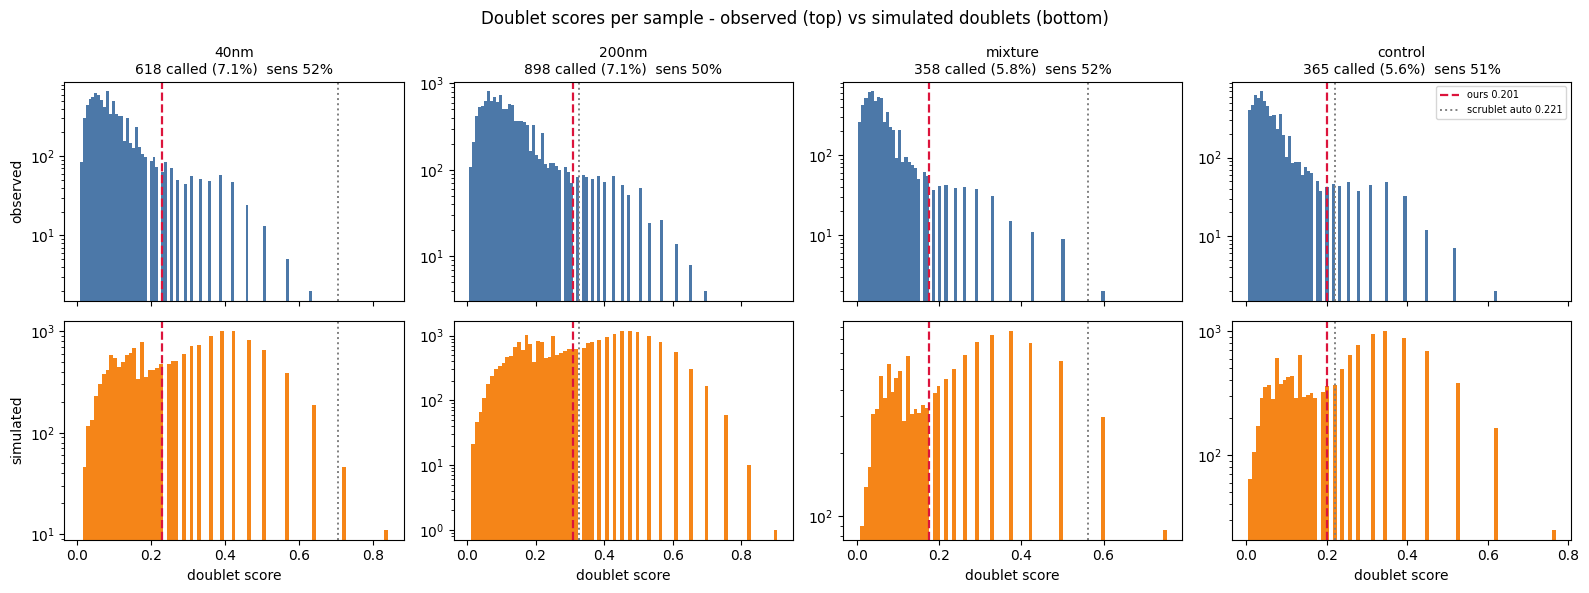

In [9]:
import matplotlib.pyplot as plt

# Top row: observed cells. Bottom row: simulated doublets - the known positives.
# Red dashed = our threshold (median simulated score, i.e. 50% sensitivity).
# Grey dotted = Scrublet's automatic threshold, shown so its failure is visible.
#
# Log y-scale throughout: without it the singlet peak flattens the tail we care about.
# Note the COMB of isolated spikes in the observed tail - doublet_score is a fraction of
# k nearest neighbours, so it takes discrete values. That comb is why a shoulder-based
# threshold ends up depending on cell count.
fig, axes = plt.subplots(2, 4, figsize=(16, 6), sharex='col')

for j, (label, adata) in enumerate(adatas.items()):
    obs = adata.obs['doublet_score'].to_numpy()
    sim = np.asarray(adata.uns['scrublet']['doublet_scores_sim'])
    thr = THRESHOLDS[label]
    auto = adata.uns['scrublet'].get('threshold')
    sensitivity = float((sim >= thr).mean())
    n_called = int((obs >= thr).sum())

    for i, (scores, name, colour) in enumerate(
        [(obs, 'observed', '#4C78A8'), (sim, 'simulated', '#F58518')]
    ):
        ax = axes[i, j]
        ax.hist(scores, bins=80, color=colour, edgecolor='none')
        ax.axvline(thr, color='crimson', ls='--', lw=1.6, label=f'ours {thr:.3f}')
        if auto is not None:
            ax.axvline(auto, color='grey', ls=':', lw=1.4,
                       label=f'scrublet auto {auto:.3f}')
        ax.set_yscale('log')
        ax.set_ylabel(name if j == 0 else '')
        if i == 0:
            ax.set_title(
                f'{label}\n{n_called:,} called ({n_called / len(obs):.1%})  '
                f'sens {sensitivity:.0%}',
                fontsize=10,
            )
        else:
            ax.set_xlabel('doublet score')
        if i == 0 and j == 3:
            ax.legend(fontsize=7, loc='upper right')

fig.suptitle(
    'Doublet scores per sample - observed (top) vs simulated doublets (bottom)',
    fontsize=12,
)
fig.tight_layout()
plt.show()

### Applying the thresholds, and what the numbers say

We overwrite Scrublet's own `predicted_doublet` with our sensitivity-matched call, then
remove. Flag first, filter second — the scores and calls stay in `obs`, so the decision
remains inspectable rather than buried inside a filtering expression.

#### The doublet burden looks flat across samples

Correcting each call rate by its detection sensitivity gives an estimate of the **true**
doublet burden, including the homotypic doublets no expression-based method can see:

| Sample | Cells | Called | Implied true rate | 10x estimate |
|---|---|---|---|---|
| `40nm` | 8,729 | ~7.1% | ~14% | 7.0% |
| `200nm` | 12,676 | ~7.1% | ~14% | 10.1% |
| `mixture` | 6,157 | ~5.8% | ~12% | 4.9% |
| `control` | 6,516 | ~5.6% | ~11% | 5.2% |

Two things follow.

**The implied burden does not scale with cell count.** The 10x model predicts a 2×
spread (4.9% → 10.1%) because it treats recovered cells as a proxy for loaded cells. The
data shows a roughly flat ~11–14%. The most likely reading is that all four channels
were **loaded comparably** and differ in *recovery* — viability, clumping, or
exposure-induced cell death — which would break that proxy. `200nm` having the most
cells then reflects better recovery, not heavier loading.

**The implied rate sits above the 10x estimate throughout**, by roughly 2× in the
smaller samples. Some of that is likely real, but some is an artefact of the correction:
simulated doublets are built by summing two random cells, which produces *cleaner*
hybrids than reality. That inflates measured sensitivity, and dividing by an inflated
sensitivity inflates the implied rate. So treat ~11–14% as an upper bound, and the true
figure as somewhere between it and the 10x estimate.

Either way this is a **calibration caveat, not a per-sample anomaly** — it shifts all
four samples in the same direction, so it does not bias the between-sample comparisons
that Tasks 4 and 6 depend on.

#### What remains checkable later

Because we detect only heterotypic doublets, roughly half the true burden survives into
the clustering — in every sample, at matched sensitivity. Residual homotypic doublets
inflate whatever cell type is already most abundant, so if one sample's composition is
much more skewed than the others, its residual burden will be higher.

**Section 12 can test this directly**: once we have our own cell-type labels, compute
each sample's homotypic fraction as the sum of squared cell-type proportions, and check
whether any sample is unusually skewed. Until then this stays an open caveat rather than
a conclusion.

In [10]:
# Apply our sensitivity-matched thresholds, overwriting Scrublet's own unreliable call.
# (Not the shoulder rule - that was tried and rejected above, because the shoulder's
# position depends on cell count and so gave the largest sample the weakest detection.)
for label, adata in adatas.items():
    adata.obs['predicted_doublet'] = (
        adata.obs['doublet_score'] >= THRESHOLDS[label]
    )

# CLAUDE.md's named pitfall is a threshold that is present in code but numerically
# inert - it filters nothing, and the code running is mistaken for the filter working.
# That is exactly what Scrublet's automatic threshold did here (0 cells in 40nm), so
# print before/after counts and assert something was actually removed.
before = {label: adata.n_obs for label, adata in adatas.items()}

adatas = {
    label: adata[~adata.obs['predicted_doublet']].copy()
    for label, adata in adatas.items()
}

print(f'{"sample":<9}{"before":>9}{"removed":>9}{"after":>9}{"removed":>10}'
      f'{"10x est":>10}')
for label, adata in adatas.items():
    removed = before[label] - adata.n_obs
    print(
        f'{label:<9}{before[label]:>9,}{removed:>9,}{adata.n_obs:>9,}'
        f'{removed / before[label]:>10.1%}'
        f'{expected_doublet_rate(before[label]):>10.1%}'
    )
    assert removed > 0, (
        f'{label}: doublet filter removed nothing. The threshold is inert - '
        f'inspect the score distribution before continuing.'
    )
    # Sanity bound, not a target: detected rate should be within a factor of ~2 of the
    # loading estimate. Wider than that means the threshold, not the biology, is wrong.
    ratio = (removed / before[label]) / expected_doublet_rate(before[label])
    assert 0.4 < ratio < 2.0, (
        f'{label}: removed {removed / before[label]:.1%} against a 10x estimate of '
        f'{expected_doublet_rate(before[label]):.1%} (ratio {ratio:.2f}) - '
        f'inspect the threshold.'
    )

total_before, total_after = sum(before.values()), sum(a.n_obs for a in adatas.values())
print(
    f'\ntotal {total_before:,} -> {total_after:,} cells  '
    f'({total_before - total_after:,} doublets removed, '
    f'{(total_before - total_after) / total_before:.1%})'
)
print('\nSection 2 complete: doublets scored, thresholded per sample, and removed.')

sample      before  removed    after   removed   10x est
40nm         8,729      618    8,111      7.1%      7.0%
200nm       12,676      898   11,778      7.1%     10.1%
mixture      6,157      358    5,799      5.8%      4.9%
control      6,516      365    6,151      5.6%      5.2%

total 34,078 -> 31,839 cells  (2,239 doublets removed, 6.6%)

Section 2 complete: doublets scored, thresholded per sample, and removed.


---

## Section 3a — QC metrics and distribution inspection

**`CLAUDE.md` Task 1** (QC & preprocessing) · **tutorial reference:** cells 23–45

### What gets filtered in Section 3, and what does not

| Metric | Filtered? | Where |
|---|---|---|
| count depth (`total_counts`) | **yes** | 3b |
| genes detected (`n_genes_by_counts`) | **yes** | 3b |
| mitochondrial % (`pct_counts_mt`) | **yes** | 3b |
| ribosomal % (`pct_counts_ribo`) | no — diagnostic only | — |

The first three are `CLAUDE.md`'s named Task 1 criteria and all three are cut. Ribo%
is the one metric we compute but decline to filter on; the reasoning is below.

### Why this section is split into 3a and 3b

`CLAUDE.md` makes one requirement non-negotiable: thresholds must be picked **by
inspecting each sample's own distribution**, not copied from literature and not reused
as a single number across samples. That is a sequencing constraint, not just a style
note — a per-sample threshold cannot be written down before the four distributions have
been looked at.

So **3a computes the metrics, plots them, and filters nothing.** It also reports what
each candidate rule *would* remove. **3b applies the rule chosen at that review.**

Doing it in this order also keeps the decision reversible. Once cells are dropped, you
cannot inspect what you dropped without re-running from Section 1 — and with Scrublet in
that path, it is the expensive direction. Measuring the counterfactual first means the
review happens while the evidence is still in the object.

### Why we are not inheriting the tutorial's thresholds

The tutorial hardcodes `pct_counts_mt < 20` (cell 43) and `pct_counts_ribo < 2`
(cell 44). Tracing the cell counts through its own saved outputs shows what those two
filters actually did to its data:

| tutorial cell | operation | cells after |
|---|---|---|
| 2 | load | 6,099 |
| 22 | after SOLO doublet removal | 5,639 |
| 41 | `n_genes < 2305.7` (98th percentile) | 5,526 |
| 43–44 | `pct_counts_mt < 20` **and** `pct_counts_ribo < 2` | **5,509** |

**Those two thresholds removed 17 cells between them — 0.3%.** Over 99.7% of its cells
already sat below 2% ribosomal content, a profile consistent with single-nucleus data
(ribosomes are cytoplasmic, so nuclear preps exclude them). The only filter that
genuinely bit was cell 41's — the one *derived from the data* with `np.quantile`.

This is `CLAUDE.md`'s named pitfall found in the source we are adapting from: *a
threshold present in code but numerically inert on the actual dataset*. It matters
because ours is whole-cell PBMC data, where ribosomal transcripts are a large fraction
of every library. **The same line of code is inert there and would be catastrophic
here** — and in neither case does it announce which it is doing. Hence the before/after
counts printed at every filtering step.

### Why ribo% is computed but not filtered

Three reasons not to cut on it:

1. **`CLAUDE.md` does not ask for it.** Task 1 names "count depth, genes detected,
   mito%". Ribo enters only via the tutorial, whose version we have just shown was
   never actually exercised.
2. **It cuts toward our signal.** Ribosomal content tracks translational activity, so
   high ribo% marks *activated* lymphocytes. In an immune-activation study a ribo
   filter preferentially deletes responding cells.
3. **Low-complexity cells are better caught directly** by `n_genes_by_counts`, which
   we filter on anyway.

It is still worth computing, for one specific check: if a single sample's ribo%
distribution is visibly shifted from the other three, that points at a **processing
difference between channels** — which matters before Task 4 reads cell-type proportion
differences across those same samples as an exposure effect. We already carry one
unexplained cross-sample oddity from Section 2 (the flat ~11–14% doublet burden that did
not scale with cell count). This is cheap insurance against a second.

### What stays deferred

`CLAUDE.md` bonus #1 is the joint mito%/complexity distress analysis — separating cells
that are *dying* (high mito%, low ribo%, membrane ruptured) from cells that are
*genuinely stressed but intact* (high mito%, normal ribo%). That distinction matters
here, because nanoparticle exposure could plausibly cause real mitochondrial stress, so
a mito filter may be discarding signal rather than noise.

`CLAUDE.md` is explicit that this waits: filter high-mito cells normally in this pass,
treat it as a working baseline, and revisit once Tasks 1–6 have run end to end. We
follow that. The metrics computed here make the later analysis possible without
re-running anything.

In [11]:
# Flag the two gene families the QC percentages are computed over. Both flags go in
# .var, PER SAMPLE, because the four files still have different gene sets (22,613 /
# 23,206 / 21,715 / 21,961) and are not concatenated until Section 4.

# Mitochondrial: the 13 protein-coding genes on the mitochondrial chromosome, prefixed
# 'MT-' in current human nomenclature. Verified present and identically named in all
# four files - no legacy aliases (COX1, CYTB, ND1) anywhere.
#
# Ribosomal: KEGG_RIBOSOME from MSigDB, per PLAN.md row 3. Fetched ONCE here rather
# than inside the loop - it is the same list every time, and this notebook should not
# make four identical network calls.
#
# Why the curated list and not an 'RPS'/'RPL' prefix match, measured on this data:
# KEGG matches 85 of its 88 genes. The 3 misses - RPL10L, RPL3L, RSL24D1P11 - are
# tissue-specific paralogs and a pseudogene, genuinely absent from PBMCs rather than
# renamed. A prefix match instead picks up 102 genes but wrongly INCLUDES RPS6KA1 and
# RPS6KA2 (MAPK signalling kinases, named after the ribosomal protein they
# phosphorylate rather than being one), an antisense lncRNA and several pseudogenes,
# while wrongly EXCLUDING FAU and UBA52 - which encode ribosomal proteins S30 and L40
# under non-RP names. A prefix rule can only see spelling; the curated set encodes
# the biology, and here that is ~20x fewer errors.
RIBO_URL = (
    'http://software.broadinstitute.org/gsea/msigdb/download_geneset.jsp'
    '?geneSetName=KEGG_RIBOSOME&fileType=txt'
)

# skiprows=2 drops the set name and description lines; gene symbols follow. The Broad
# URL 301-redirects to gsea-msigdb.org, which pd.read_table follows by default.
ribo_genes = set(pd.read_table(RIBO_URL, skiprows=2, header=None)[0].values)
print(f'KEGG_RIBOSOME: {len(ribo_genes)} gene symbols fetched\n')

print(f'{"sample":<9}{"genes":>8}{"MT-":>6}{"ribo":>7}{"of KEGG":>10}')
for label, adata in adatas.items():
    adata.var['mt'] = adata.var_names.str.startswith('MT-')
    adata.var['ribo'] = adata.var_names.isin(ribo_genes)

    n_mt, n_ribo = int(adata.var['mt'].sum()), int(adata.var['ribo'].sum())
    print(f'{label:<9}{adata.n_vars:>8,}{n_mt:>6}{n_ribo:>7}'
          f'{n_ribo / len(ribo_genes):>10.0%}')

    # A silent match failure - wrong nomenclature, a changed separator, a download that
    # returned an error page - would leave these flags all-False and both percentages a
    # uniform 0.0. That looks like unusually clean data rather than a broken step, so
    # assert rather than trust. This is the same class of bug as Section 2's inert
    # threshold: code that runs successfully while doing nothing.
    assert n_mt == 13, f'{label}: expected 13 MT- genes, found {n_mt}'
    assert 80 <= n_ribo <= 90, (
        f'{label}: only {n_ribo} of {len(ribo_genes)} KEGG ribo genes matched - '
        f'check gene nomenclature before trusting pct_counts_ribo'
    )

print('\nGene family flags set on all four samples.')

KEGG_RIBOSOME: 88 gene symbols fetched

sample      genes   MT-   ribo   of KEGG
40nm       22,613    13     85       97%
200nm      23,206    13     87       99%
mixture    21,715    13     86       98%
control    21,961    13     86       98%

Gene family flags set on all four samples.


In [12]:
# Compute the per-cell QC metrics.
#
# calculate_qc_metrics must see RAW COUNTS. Every metric here is a count or a ratio of
# counts, so running it on normalized values would produce numbers that still look
# plausible but mean nothing - CLAUDE.md's "mismatched layers" pitfall exactly. Our .X
# is counts (asserted at the end of Section 1); we re-assert below rather than assume.
#
# log1p=True, where the tutorial uses False at its cell 31. We need it: the MAD-based
# candidate rule operates on log1p_total_counts and log1p_n_genes_by_counts. Count
# depth is roughly log-normal, so a SYMMETRIC outlier rule is only meaningful on the
# log scale - applied to raw counts it would flag far more cells above the median than
# below, purely from the right skew rather than from anything being wrong with them.
#
# percent_top=None skips the "fraction of counts in the top N genes" columns, which
# nothing downstream uses.
for label, adata in adatas.items():
    sc.pp.calculate_qc_metrics(
        adata, qc_vars=['mt', 'ribo'], percent_top=None, log1p=True, inplace=True
    )

# The four metrics Section 3 reasons about. The first three are CLAUDE.md's Task 1
# criteria and get filtered in 3b; pct_counts_ribo is diagnostic only.
QC_METRICS = ['total_counts', 'n_genes_by_counts', 'pct_counts_mt', 'pct_counts_ribo']

for label, adata in adatas.items():
    data = adata.X.data if hasattr(adata.X, 'data') else np.asarray(adata.X).ravel()
    assert np.all(data == np.floor(data)), (
        f'{label}: .X is no longer integer counts - QC metrics would be meaningless'
    )
    for metric in QC_METRICS:
        assert metric in adata.obs.columns, f'{label}: {metric} was not computed'
        # A constant metric means the .var flag never matched anything. Variance is the
        # cheapest test that the percentages carry real information.
        assert adata.obs[metric].var() > 0, (
            f'{label}: {metric} is constant - the gene flag did not land'
        )
    for pct in ('pct_counts_mt', 'pct_counts_ribo'):
        assert adata.obs[pct].between(0, 100).all(), f'{label}: {pct} outside [0, 100]'

print('QC metrics computed for all four samples.')
print('.X verified still raw integer counts.\n')
print('obs columns now:')
for col in adatas['40nm'].obs.columns:
    print(f'    {col}')

QC metrics computed for all four samples.
.X verified still raw integer counts.

obs columns now:
    predicted.celltype
    predicted.celltype.score
    Sample
    doublet_score
    predicted_doublet
    n_genes_by_counts
    log1p_n_genes_by_counts
    total_counts
    log1p_total_counts
    total_counts_mt
    log1p_total_counts_mt
    pct_counts_mt
    total_counts_ribo
    log1p_total_counts_ribo
    pct_counts_ribo


In [13]:
# Per-sample distribution summary, before any plot.
#
# CLAUDE.md requires thresholds picked from each sample's OWN distribution, so the
# first thing to establish is whether the four distributions actually differ. If they
# were near-identical, a single shared threshold would have been defensible after all;
# if they differ, that is precisely what rules it out. Either way it should be settled
# by looking, not assumed - so print the quantiles side by side and read them.
rows = []
for label, adata in adatas.items():
    for metric in QC_METRICS:
        v = adata.obs[metric]
        rows.append({
            'metric': metric,
            'sample': label,
            'cells': len(v),
            'min': v.min(),
            'p1': v.quantile(0.01),
            'p25': v.quantile(0.25),
            'median': v.median(),
            'p75': v.quantile(0.75),
            'p99': v.quantile(0.99),
            'max': v.max(),
        })

qc_summary = pd.DataFrame(rows).set_index(['metric', 'sample'])

with pd.option_context('display.float_format', '{:,.2f}'.format, 'display.width', 160):
    for metric in QC_METRICS:
        print(f'\n=== {metric} ===')
        print(qc_summary.loc[metric])

# The single number that decides whether per-sample thresholds are necessary: how much
# the medians move across samples, relative to the metric's own scale.
print('\n\n=== cross-sample spread of the median ===')
print(f'{"metric":<22}{"min median":>13}{"max median":>13}{"ratio":>9}')
for metric in QC_METRICS:
    meds = qc_summary.loc[metric, 'median']
    lo, hi = meds.min(), meds.max()
    ratio = hi / lo if lo > 0 else float('inf')
    print(f'{metric:<22}{lo:>13,.2f}{hi:>13,.2f}{ratio:>9.2f}x')


=== total_counts ===
         cells    min       p1      p25   median      p75       p99        max
sample                                                                        
40nm      8111 500.00   739.60 3,862.00 5,269.00 6,867.50 24,591.60 151,008.00
200nm    11778 504.00   970.00 3,248.00 4,334.00 5,818.00 25,650.16 103,502.00
mixture   5799 502.00   760.96 4,352.00 6,090.00 8,086.00 46,197.06 215,311.00
control   6151 514.00 1,076.00 5,441.50 7,674.00 9,678.50 55,434.00 202,274.00

=== n_genes_by_counts ===
         cells    min     p1      p25   median      p75      p99       max
sample                                                                    
40nm      8111 216.00 502.00 1,635.00 1,995.00 2,390.00 5,230.60 10,419.00
200nm    11778 204.00 614.77 1,466.00 1,768.00 2,167.00 5,505.23  9,687.00
mixture   5799 211.00 477.00 1,927.50 2,318.00 2,701.00 7,055.64 10,984.00
control   6151 203.00 521.50 2,260.50 2,601.00 3,023.00 7,528.00 10,910.00

=== pct_counts_mt ===
    

In [14]:
# Candidate rule: MAD-based outlier detection.
#
# NOTHING is applied in 3a. These helpers exist so we can MEASURE what each candidate
# rule would remove, and make the choice at review against real numbers.
#
# MAD = median absolute deviation. What matters is that BOTH the centre (median) and
# the spread (MAD) are robust: a handful of extreme cells shifts a mean and inflates a
# standard deviation, so an SD-based rule is partly calibrated by the very outliers it
# is trying to find - and quietly becomes more permissive the worse the contamination
# is. The median and MAD barely move, so the rule keeps its meaning.
#
# Against a percentile rule, the advantage is that MAD adapts to quality rather than to
# shape: it removes nothing from a clean sample, whereas a 1st/99th-percentile cut
# removes exactly 2% by construction whether or not anything is wrong with those cells.
# That is the same objection Section 2 raised against the shoulder rule.

def mad(values):
    """Median absolute deviation: a spread estimate that outliers cannot inflate."""
    values = np.asarray(values, dtype=float)
    return float(np.median(np.abs(values - np.median(values))))


def mad_bounds(values, nmads, side):
    """(lower, upper) cutoffs `nmads` MADs from the median. None means no bound."""
    values = np.asarray(values, dtype=float)
    centre, scale = float(np.median(values)), mad(values)
    lower = centre - nmads * scale if side in ('both', 'lower') else None
    upper = centre + nmads * scale if side in ('both', 'upper') else None
    return lower, upper


# Maps each plotted metric to the obs column its rule is evaluated on. Depth and genes
# detected use the log scale (see the log1p note above); mito% is already a bounded
# percentage and needs no transform. Ribo% has no rule at all - diagnostic only.
RULE_METRIC = {
    'total_counts':      'log1p_total_counts',
    'n_genes_by_counts': 'log1p_n_genes_by_counts',
    'pct_counts_mt':     'pct_counts_mt',
    'pct_counts_ribo':   None,
}

# Sidedness per metric. This is a real judgement call, not bookkeeping: a bound on a
# tail where nothing is actually wrong discards good cells for no reason.
#
# REVISED. Both depth rules were first set to 'both'. Measured against cell type once
# annotation existed, the UPPER bound removed 14% of monocytes and 0.0% of cytotoxic
# T cells - it was tracking cell SIZE, not doublets, since a monocyte carries ~3x the
# RNA of a small T cell (median 11,476 counts against 3,663). It also acted unevenly
# across samples - 42.6% of control monocytes against 12.3% of 200nm ones - which
# biases the cross-sample composition comparison Task 4 exists to make. Section 2's
# Scrublet pass already removed 2,239 doublets, so the upper tail was duplicating that
# work and doing it by cell type instead of by doublet evidence.
METRIC_RULES = {
    'log1p_total_counts':      (5, 'lower'),   # ambient droplets, not cells
    'log1p_n_genes_by_counts': (5, 'lower'),   # same population, complexity axis
    'pct_counts_mt':           (3, 'upper'),   # only the high tail is ever bad
}

# Percentile rule, for comparison. Fixed fraction by construction - stated here so the
# next cell can measure both against the same distributions.
PERCENTILE_BOUNDS = (0.01, 0.99)

_filled = all(n is not None for n, _ in METRIC_RULES.values())
print('METRIC_RULES filled:', _filled)
if not _filled:
    print('  -> plots below will render without MAD bands until it is filled in.')

METRIC_RULES filled: True


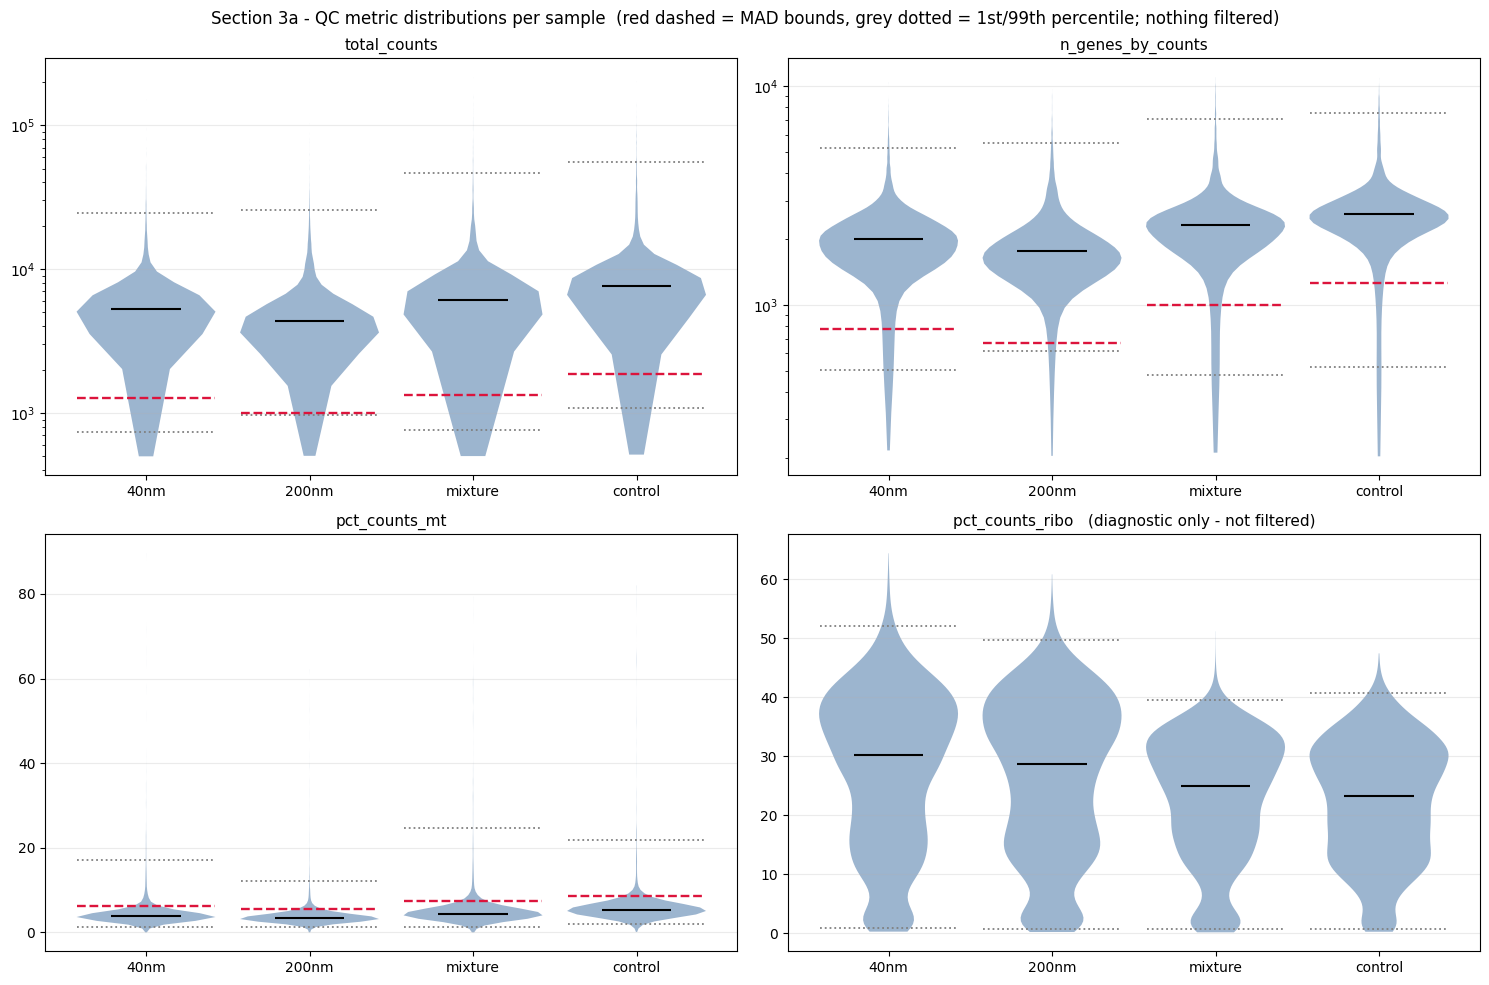

In [15]:
# Distribution plots - one panel per metric, four violins per panel (one per sample),
# so cross-sample differences are read directly rather than inferred across figures.
#
# Reference lines only. Red dashed = MAD bounds (once METRIC_RULES is filled), grey
# dotted = 1st/99th percentile. Nothing is filtered by this cell.
#
# Depth and genes-detected use a log y-axis: both span orders of magnitude, and on a
# linear axis the bulk of cells collapses into a line at the bottom while a few
# high-depth cells stretch the whole panel.
LABELS = list(adatas)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

for ax, metric in zip(axes.ravel(), QC_METRICS):
    series = [adatas[l].obs[metric].to_numpy() for l in LABELS]
    parts = ax.violinplot(series, positions=range(len(LABELS)),
                          showmedians=True, showextrema=False, widths=0.85)
    for body in parts['bodies']:
        body.set_facecolor('#4C78A8')
        body.set_alpha(0.55)
    parts['cmedians'].set_color('black')

    rule_col = RULE_METRIC[metric]
    for i, label in enumerate(LABELS):
        obs = adatas[label].obs

        # Percentile reference, drawn on the metric's own scale.
        for q in PERCENTILE_BOUNDS:
            ax.hlines(obs[metric].quantile(q), i - 0.42, i + 0.42,
                      color='grey', ls=':', lw=1.3, zorder=3)

        # MAD reference. Rules for depth and genes are evaluated on log1p values, so
        # the bound has to be mapped back with expm1 before it can be drawn on the raw
        # axis - otherwise the line lands in completely the wrong place.
        if rule_col is None:
            continue
        nmads, side = METRIC_RULES[rule_col]
        if nmads is None:
            continue
        lower, upper = mad_bounds(obs[rule_col], nmads, side)
        for bound in (lower, upper):
            if bound is None:
                continue
            drawn = np.expm1(bound) if rule_col.startswith('log1p_') else bound
            ax.hlines(drawn, i - 0.42, i + 0.42,
                      color='crimson', ls='--', lw=1.7, zorder=4)

    if metric in ('total_counts', 'n_genes_by_counts'):
        ax.set_yscale('log')
    ax.set_xticks(range(len(LABELS)))
    ax.set_xticklabels(LABELS)
    ax.set_title(metric + ('   (diagnostic only - not filtered)'
                           if metric == 'pct_counts_ribo' else ''), fontsize=11)
    ax.grid(axis='y', alpha=0.25)

fig.suptitle('Section 3a - QC metric distributions per sample  '
             '(red dashed = MAD bounds, grey dotted = 1st/99th percentile; '
             'nothing filtered)', fontsize=12)
fig.tight_layout()
plt.show()

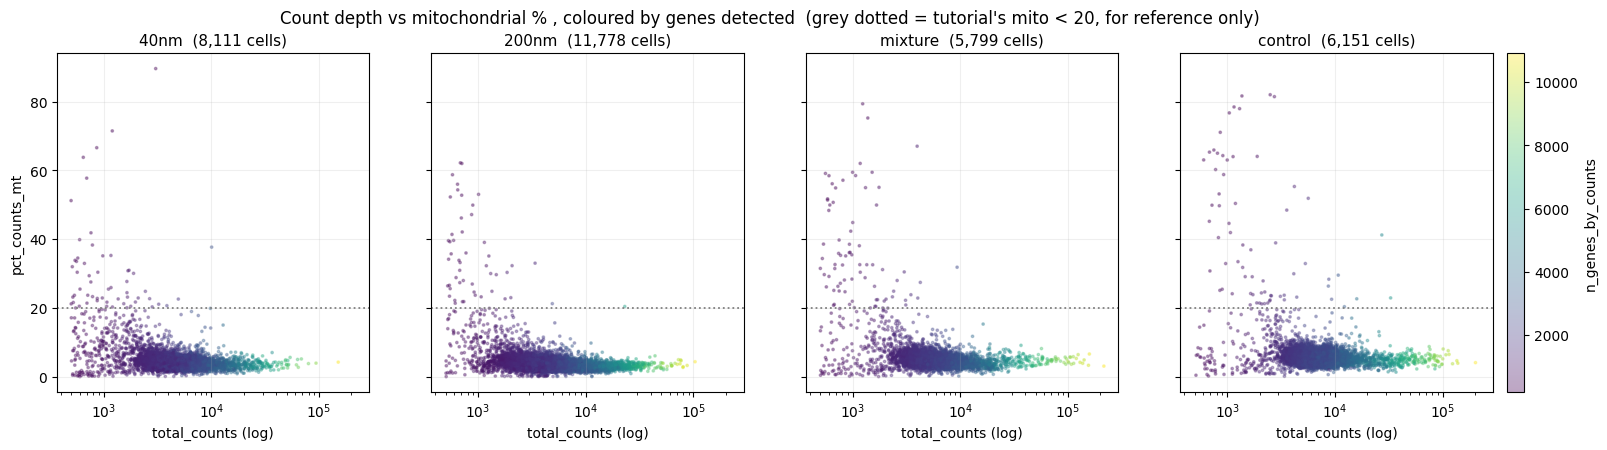

In [16]:
# Joint view: count depth vs mito%, coloured by genes detected.
#
# The violins above show each metric in isolation, but a threshold on one metric cuts
# across the others, and this is where that becomes visible. The shape to look for is
# a cluster at LOW depth and HIGH mito% - dying cells that lost cytoplasmic mRNA
# through a ruptured membrane while mitochondrial transcripts stayed trapped inside.
# Those cells are the ones a mito filter is actually for.
#
# The colour axis is what makes it readable: genuinely dying cells are low-depth,
# high-mito AND low-complexity (few genes), so they should appear as a dark clump. A
# high-mito cell that still detects many genes is a different animal - an intact cell
# with real mitochondrial content, which for this project might be exposure response
# rather than damage.
#
# This is a plot for choosing thresholds, NOT the joint mito%/complexity distress
# analysis CLAUDE.md defers to bonus #1. That analysis tests high-mito cells against a
# dissociation-stress gene signature to decide whether they are artefact or biology,
# and it needs the cell-type labels from Task 3 first.
fig, axes = plt.subplots(1, 4, figsize=(19, 4.4), sharex=True, sharey=True)

for ax, label in zip(axes, LABELS):
    obs = adatas[label].obs
    sm = ax.scatter(obs['total_counts'], obs['pct_counts_mt'],
                    c=obs['n_genes_by_counts'], s=3, alpha=0.35,
                    cmap='viridis', rasterized=True)
    ax.set_xscale('log')
    ax.set_xlabel('total_counts (log)')
    ax.set_title(f'{label}  ({len(obs):,} cells)', fontsize=11)
    ax.grid(alpha=0.2)

    # Reference only: the tutorial's hardcoded mito cutoff, shown so its position
    # relative to OUR distributions is visible rather than assumed.
    ax.axhline(20, color='grey', ls=':', lw=1.3)

axes[0].set_ylabel('pct_counts_mt')
fig.colorbar(sm, ax=axes, label='n_genes_by_counts', fraction=0.015, pad=0.01)
fig.suptitle("Count depth vs mitochondrial % , coloured by genes detected  "
             "(grey dotted = tutorial's mito < 20, for reference only)", fontsize=12)
plt.show()

In [17]:
# What each candidate rule WOULD remove. Still nothing is applied.
#
# This is the whole point of splitting 3a from 3b: measuring the counterfactual while
# the cells are still in the object. After 3b drops them, asking "how many would the
# other rule have taken?" means re-running from Section 1, and Scrublet makes that the
# expensive direction.
#
# The union row matters more than the per-metric rows. Cells flagged by several metrics
# overlap heavily - a dying cell is low-depth AND low-complexity AND high-mito - so
# summing the individual counts badly overstates the real loss.

def flag_mask(values, lower, upper):
    """Boolean mask of cells outside (lower, upper). None means that side is open."""
    values = np.asarray(values, dtype=float)
    mask = np.zeros(len(values), dtype=bool)
    if lower is not None:
        mask |= values < lower
    if upper is not None:
        mask |= values > upper
    return mask


if not all(n is not None for n, _ in METRIC_RULES.values()):
    print('METRIC_RULES is not filled in yet - fill it in the cell above, then re-run '
          'this cell to see what each rule would remove.')
else:
    for label in LABELS:
        obs = adatas[label].obs
        n = len(obs)
        print(f'\n=== {label}  ({n:,} cells) ===')
        print(f'{"metric":<26}{"rule":<14}{"lower":>12}{"upper":>12}'
              f'{"flagged":>10}{"%":>8}')

        union_mad = np.zeros(n, dtype=bool)
        union_pct = np.zeros(n, dtype=bool)

        for metric, rule_col in RULE_METRIC.items():
            if rule_col is None:      # pct_counts_ribo - diagnostic only, no rule
                continue
            nmads, side = METRIC_RULES[rule_col]

            lo, hi = mad_bounds(obs[rule_col], nmads, side)
            m = flag_mask(obs[rule_col], lo, hi)
            union_mad |= m
            # Report bounds on the metric's own scale so they are comparable to the
            # summary table above, not as log values nobody can eyeball.
            shown = [None if b is None else
                     (np.expm1(b) if rule_col.startswith('log1p_') else b)
                     for b in (lo, hi)]
            print(f'{metric:<26}{f"MAD {nmads} {side}":<14}'
                  f'{"-" if shown[0] is None else f"{shown[0]:,.1f}":>12}'
                  f'{"-" if shown[1] is None else f"{shown[1]:,.1f}":>12}'
                  f'{m.sum():>10,}{m.sum() / n:>8.1%}')

            plo, phi = (obs[metric].quantile(q) for q in PERCENTILE_BOUNDS)
            mp = flag_mask(obs[metric], plo, phi)
            union_pct |= mp
            print(f'{"":<26}{"pct 1/99":<14}{plo:>12,.1f}{phi:>12,.1f}'
                  f'{mp.sum():>10,}{mp.sum() / n:>8.1%}')

        print(f'{"UNION across metrics":<26}{"MAD":<14}{"":>24}'
              f'{union_mad.sum():>10,}{union_mad.sum() / n:>8.1%}')
        print(f'{"":<26}{"pct 1/99":<14}{"":>24}'
              f'{union_pct.sum():>10,}{union_pct.sum() / n:>8.1%}')

# Separately: what the tutorial's two hardcoded cutoffs would do to OUR data. Its own
# outputs show they removed 17 cells (0.3%) there. The prediction here is that mito<20
# is roughly comparable while ribo<2 is catastrophic - but the whole point of Section 2
# and 3a is to check predictions against numbers rather than trust them.
print('\n\n=== the tutorial\'s hardcoded cutoffs, applied to our data (NOT used) ===')
print(f'{"sample":<10}{"mito >= 20":>14}{"":>7}{"ribo >= 2":>13}{"":>8}')
for label in LABELS:
    obs = adatas[label].obs
    n = len(obs)
    n_mt = int((obs['pct_counts_mt'] >= 20).sum())
    n_rb = int((obs['pct_counts_ribo'] >= 2).sum())
    print(f'{label:<10}{n_mt:>10,}{n_mt / n:>11.1%}{n_rb:>13,}{n_rb / n:>11.1%}')


=== 40nm  (8,111 cells) ===
metric                    rule                 lower       upper   flagged       %
total_counts              MAD 5 lower        1,263.1           -       215    2.7%
                          pct 1/99             739.6    24,591.6       164    2.0%
n_genes_by_counts         MAD 5 lower          774.2           -       210    2.6%
                          pct 1/99             502.0     5,230.6       163    2.0%
pct_counts_mt             MAD 3 upper              -         6.3       647    8.0%
                          pct 1/99               1.2        17.1       164    2.0%
UNION across metrics      MAD                                          736    9.1%
                          pct 1/99                                     300    3.7%

=== 200nm  (11,778 cells) ===
metric                    rule                 lower       upper   flagged       %
total_counts              MAD 5 lower        1,006.9           -       129    1.1%
                          p

In [18]:
# Not "how much are we cutting" but "WHAT are we cutting".
#
# Cell 24 gives counts. A count cannot distinguish "removed 4% debris" from "removed 4%
# of a small, low-RNA but perfectly real cell type" - and the second would delete a
# whole population from Task 4's composition comparison, which is exactly the artefact
# Section 2 worked to avoid. Platelets and small resting lymphocytes genuinely have low
# RNA, so a low-depth cell is not automatically junk.
#
# Two things below:
#   1. Split each flag into its LOW and HIGH tail. They remove different things - dying
#      cells at the bottom, probable multiplets at the top - and a single total hides
#      which of the two is doing the work.
#   2. Profile the flagged cells against the kept ones. A dying cell should show HIGH
#      mito%, LOW ribo% (cytoplasmic transcripts leaked out through the ruptured
#      membrane) and FEW genes. If the low tail instead looks compositionally normal,
#      we are cutting real biology and should loosen the bound.

for label in LABELS:
    obs = adatas[label].obs
    n = len(obs)
    low_any = np.zeros(n, dtype=bool)
    high_any = np.zeros(n, dtype=bool)

    print(f'\n=== {label}  ({n:,} cells) ===')
    print(f'{"metric":<24}{"cut low":>10}{"%":>8}{"cut high":>10}{"%":>8}')
    for metric, rule_col in RULE_METRIC.items():
        if rule_col is None:            # ribo - diagnostic only, never filtered
            continue
        nmads, side = METRIC_RULES[rule_col]
        lo, hi = mad_bounds(obs[rule_col], nmads, side)
        v = obs[rule_col].to_numpy()
        ml = (v < lo) if lo is not None else np.zeros(n, dtype=bool)
        mh = (v > hi) if hi is not None else np.zeros(n, dtype=bool)
        low_any |= ml
        high_any |= mh
        print(f'{metric:<24}{ml.sum():>10,}{ml.sum() / n:>8.1%}'
              f'{mh.sum():>10,}{mh.sum() / n:>8.1%}')

    keep = ~(low_any | high_any)
    print(f'{"UNION":<24}{low_any.sum():>10,}{low_any.sum() / n:>8.1%}'
          f'{high_any.sum():>10,}{high_any.sum() / n:>8.1%}')

    print(f'\n  {"group":<17}{"cells":>8}{"med counts":>13}{"med genes":>12}'
          f'{"med mito%":>12}{"med ribo%":>12}')
    for name, mask in (('cut - low tail', low_any & ~high_any),
                       ('cut - high tail', high_any),
                       ('KEPT', keep)):
        if int(mask.sum()) == 0:
            continue
        g = obs[mask]
        print(f'  {name:<17}{int(mask.sum()):>8,}'
              f'{g["total_counts"].median():>13,.0f}'
              f'{g["n_genes_by_counts"].median():>12,.0f}'
              f'{g["pct_counts_mt"].median():>12.1f}'
              f'{g["pct_counts_ribo"].median():>12.1f}')



=== 40nm  (8,111 cells) ===
metric                     cut low       %  cut high       %
total_counts                   215    2.7%         0    0.0%
n_genes_by_counts              210    2.6%         0    0.0%
pct_counts_mt                    0    0.0%       647    8.0%
UNION                          226    2.8%       647    8.0%

  group               cells   med counts   med genes   med mito%   med ribo%
  cut - low tail         89          842         606         2.3         9.7
  cut - high tail       647        2,627       1,372         8.2         6.1
  KEPT                7,375        5,477       2,043         3.7        31.6

=== 200nm  (11,778 cells) ===
metric                     cut low       %  cut high       %
total_counts                   129    1.1%         0    0.0%
n_genes_by_counts              145    1.2%         0    0.0%
pct_counts_mt                    0    0.0%       853    7.2%
UNION                          153    1.3%       853    7.2%

  group             

In [19]:
# Section 3a verification: assert that nothing was filtered.
#
# Every other section asserts that a step DID something. This one asserts the opposite,
# and it is the same discipline: 3a's contract is that it only measures, so an
# accidental filter here would silently change what 3b is choosing between.
EXPECTED_AFTER_DOUBLETS = {'40nm': 8111, '200nm': 11778, 'mixture': 5799, 'control': 6151}

print(f'{"sample":<10}{"cells":>9}{"expected":>10}{"MT-":>6}{"ribo":>6}')
for label, adata in adatas.items():
    print(f'{label:<10}{adata.n_obs:>9,}{EXPECTED_AFTER_DOUBLETS[label]:>10,}'
          f'{int(adata.var["mt"].sum()):>6}{int(adata.var["ribo"].sum()):>6}')
    assert adata.n_obs == EXPECTED_AFTER_DOUBLETS[label], (
        f'{label}: 3a changed the cell count ({adata.n_obs:,} vs '
        f'{EXPECTED_AFTER_DOUBLETS[label]:,}) - it must only measure, never filter'
    )

total = sum(a.n_obs for a in adatas.values())
assert total == 31_839, f'expected 31,839 cells after Section 2, got {total:,}'

print(f'\ntotal {total:,} cells - unchanged from Section 2.')
print('Section 3a complete: metrics computed, distributions plotted, nothing filtered.')
print('Thresholds are chosen at review, then applied in Section 3b.')

sample        cells  expected   MT-  ribo
40nm          8,111     8,111    13    85
200nm        11,778    11,778    13    87
mixture       5,799     5,799    13    86
control       6,151     6,151    13    86

total 31,839 cells - unchanged from Section 2.
Section 3a complete: metrics computed, distributions plotted, nothing filtered.
Thresholds are chosen at review, then applied in Section 3b.


### Section 3a review — what to read off the output above

**Stop here.** Section 3b is written only after these are answered from the real
numbers, per `PLAN.md`'s working process.

1. **Do the four distributions actually differ?** The cross-sample median spread table
   is the direct test. If the medians are close, a shared threshold would have been
   defensible; if they diverge, that is the concrete justification for `CLAUDE.md`'s
   per-sample requirement rather than a restatement of it.

2. **Is there a low-depth / high-mito clump in the scatter?** That is the population a
   mito filter exists to remove. If it is absent, mito filtering here is near-inert and
   should be reported as such rather than presented as if it did work.

3. **Do high-mito cells also have few genes detected?** Dark points high on the y-axis
   are dying cells. Bright points high on the y-axis are intact cells with genuine
   mitochondrial content — and given nanoparticle exposure plausibly causes real
   mitochondrial stress, those may be signal. Note which pattern this data shows; it
   is the input to bonus #1 later.

4. **Does the tutorial's `mito < 20` sit anywhere near our distributions?** The grey
   dotted line makes this readable directly.

5. **What does `ribo >= 2` actually remove here?** Predicted to be most of the dataset,
   against 0.3% in the tutorial. Either way the measured number replaces the prediction.

6. **Does one sample's ribo% look different from the other three?** The only live
   consequence ribo% has in this pass — a shifted sample suggests a processing
   difference between channels, which matters before Task 4 reads composition
   differences as exposure effects.

7. **MAD vs percentile — which removes more, and are they removing the same cells?**
   Compare the union rows. If MAD removes far less than the percentile rule's fixed
   ~2%, that is evidence the samples are clean and the percentile rule would be cutting
   healthy cells to meet a quota.

The rule chosen here gets applied in **3b**, with before/after cell counts printed per
sample and an assertion that it was not numerically inert — the pitfall `CLAUDE.md`
names, and the one the tutorial's own ribo filter turned out to be.

---

## Section 3b — Applying the QC thresholds

**`CLAUDE.md` Task 1** · thresholds chosen at the 3a review, from the distributions

### The rule

**MAD-based outlier detection, computed within each sample separately.** A cell is
removed if a metric lies more than *n* MADs from **that sample's own median**. Per
sample because the four differ by up to 1.77× in typical depth — a single shared number
would cut deeper into some samples than others and manufacture a composition difference
that Task 4 would misread as an exposure effect.

| metric | setting | justification |
|---|---|---|
| `log1p_total_counts` | 5 MADs, **lower only** | **Low:** ambient RNA, not cells — genes-per-count is 0.6–0.7 against 0.35 in real cells, i.e. nearly every UMI hits a different gene, the signature of randomly sampling the ambient soup rather than a transcriptome. The high tail is **not** bounded - see the revision note below. 5 MADs because depth varies legitimately between cell types. |
| `log1p_n_genes_by_counts` | 5 MADs, **lower only** | The same population caught on the complexity axis. Bounded on the low side only, for the same reason as depth. |
| `pct_counts_mt` | 3 MADs, **upper only** | Low mito% is healthy, so a two-sided rule would flag the best cells. 3 MADs justified empirically rather than by convention: the cells it removes carry ~11% ribosomal content against ~32% in kept cells — the leaked-cytoplasm signature of a genuinely compromised cell, not the shoulder of the healthy population. |

Depth and gene counts are evaluated on the **log scale** because both are log-normal; a
symmetric rule on raw counts would flag far more cells above the median than below,
purely from skew rather than from anything being wrong with them.

`pct_counts_ribo` is **not filtered** — see Section 3a for why. It earned its place as
the diagnostic that confirmed the mito cut removes genuinely compromised cells.

### Why the thresholds were not chosen from the plots alone

Two readings of the Section 3a violins turned out to be wrong when checked against the
cell profiles, which is worth recording rather than quietly correcting:

1. The `total_counts` lower bound looked like it sat in a populated region. It removes
   only 1.1–2.7% per sample, and those cells have the ambient-RNA ratio above.
2. The `pct_counts_mt` bound at 3 MADs looked like it cut through the healthy bulk. The
   profile shows the cells it takes have half the ribosomal content of the kept cells,
   so they are a distinct compromised population rather than healthy cells at the edge.

A violin shows *where* cells are, never *what* they are. Two populations can overlap
completely on one axis and separate cleanly on another — here, ribosomal content was
the axis that separated them, and it is the metric we chose not to filter on.

### Limitations to carry forward

1. **The mito filter removes slightly more from exposed samples** (7.2–8.2%) than from
   control (6.5%) — small, but consistent in direction across all three exposures. This
   is exactly what `CLAUDE.md` bonus #1 revisits: technical damage, or genuine
   exposure-induced mitochondrial stress? For this first pass we filter and record it.
2. **The low end was already filtered upstream** at ~500 counts / ~200 genes before
   these files reached us — visible as the flat truncation at the bottom of Section 3a's
   violins, which is a cut rather than a natural taper. Our lower bound is therefore a
   second pass over already-cleaned data, which is why it removes so little.

### Revision — why the upper depth bound was removed

Both depth rules originally ran **both ends**, the high side justified as multiplets
Scrublet missed. Once cell types existed, that justification could be tested against
them, and it did not hold.

| cell type | median counts | flagged as "too high" |
|---|---|---|
| Cytotoxic T | 3,663 | 0.0% |
| CD4 T | 5,875 | 1.0% |
| B | 6,924 | 5.6% |
| **Monocyte** | **11,476** | **14.0%** |

The flag tracks **cell size**, not doublet evidence. Monocytes are large and
transcriptionally busy, so a threshold set by a population that is 65% T cells removes
them for being monocytes. A rule catching genuine multiplets would flag cells across
types, not 14% of one type and none of another.

**The consequence is a confound, not just lost cells.** The bound bit unevenly across
samples — it removed 42.6% of control monocytes against 12.3% of 200nm ones, because
control monocytes sit at a median 26,701 counts. Task 4 compares monocyte *proportions*
between those samples, so a filter that removes them at different rates per sample
manufactures part of the difference it is meant to measure.

**Section 3b already had a guard against exactly this** — it checks that the removal
rate is even across samples, and it read 10.0–11.6%, which looked fine. That check is
computed over all cells, so a bias confined to 6% of the dataset averages away. The
guard was not wrong; it was measuring the wrong resolution. It now reports removal rate
per sample **and** the cell counts, so the same failure cannot pass twice.

Dropping the upper bound recovers **309 monocytes, 150 B cells and 247 CD4 T cells**,
and 2 cytotoxic T cells. Doublet removal is left entirely to Section 2, where it has
per-cell evidence rather than a size proxy — which is what `CLAUDE.md` asks for when it
calls a max-genes cutoff a weak sole doublet proxy.

In [20]:
# Section 3b - apply the QC thresholds.
#
# Flag first, filter second, exactly as Section 2 did: every per-metric flag stays in
# .obs, so the decision remains inspectable afterwards rather than buried inside a
# filtering expression. No threshold is hardcoded here - all bounds are recomputed per
# sample from METRIC_RULES, so changing the rule above and re-running is the only edit
# ever needed.

qc_before = {label: adata.n_obs for label, adata in adatas.items()}
qc_bounds = {}

for label, adata in adatas.items():
    n = adata.n_obs
    flagged = np.zeros(n, dtype=bool)
    qc_bounds[label] = {}

    for rule_col, (nmads, side) in METRIC_RULES.items():
        lo, hi = mad_bounds(adata.obs[rule_col], nmads, side)
        m = flag_mask(adata.obs[rule_col], lo, hi)
        adata.obs[f'qc_out_{rule_col}'] = m
        flagged |= m
        qc_bounds[label][rule_col] = (lo, hi)

    adata.obs['qc_outlier'] = flagged

# Per-metric contributions BEFORE removing anything. These overlap heavily - a dying
# cell is low-depth AND low-complexity AND high-mito - so they do not sum to the union.
print('cells flagged per metric (overlapping), then their union:\n')
print(f'{"sample":<10}'
      + ''.join(f'{c.replace("log1p_", ""):>26}' for c in METRIC_RULES)
      + f'{"UNION":>17}')
for label, adata in adatas.items():
    row = f'{label:<10}'
    for rule_col in METRIC_RULES:
        m = adata.obs[f'qc_out_{rule_col}']
        row += f'{m.sum():>17,}{m.mean():>9.1%}'
    u = adata.obs['qc_outlier']
    row += f'{u.sum():>10,}{u.mean():>7.1%}'
    print(row)

# Filter.
adatas = {
    label: adata[~adata.obs['qc_outlier']].copy()
    for label, adata in adatas.items()
}

print(f'\n{"sample":<10}{"before":>9}{"removed":>9}{"after":>9}{"removed":>11}')
for label, adata in adatas.items():
    removed = qc_before[label] - adata.n_obs
    print(f'{label:<10}{qc_before[label]:>9,}{removed:>9,}{adata.n_obs:>9,}'
          f'{removed / qc_before[label]:>11.1%}')
    # CLAUDE.md's named pitfall: a threshold present in code but numerically inert.
    # Section 2's first attempt filtered zero cells while completing successfully.
    assert removed > 0, (
        f'{label}: QC filter removed nothing - the bounds are inert. Inspect the '
        f'distributions before continuing.'
    )

rates = [(qc_before[l] - a.n_obs) / qc_before[l] for l, a in adatas.items()]
print(f'\nremoval rate across samples: {min(rates):.1%} - {max(rates):.1%}  '
      f'(spread {100 * (max(rates) - min(rates)):.1f} pp)')

# Task 4 compares cell-type proportions across these same four samples. If QC removed
# wildly different fractions per sample, the filtering itself would shift the
# composition it is meant to leave intact - the identical argument Section 2 made for
# matching doublet detection sensitivity across samples.
assert max(rates) - min(rates) < 0.05, (
    f'QC removal differs by {100 * (max(rates) - min(rates)):.1f} pp across samples - '
    f'inspect before trusting any Task 4 composition comparison'
)

total_before = sum(qc_before.values())
total_after = sum(a.n_obs for a in adatas.values())
print(f'\ntotal {total_before:,} -> {total_after:,} cells  '
      f'({total_before - total_after:,} removed, '
      f'{(total_before - total_after) / total_before:.1%})')

# Layer integrity, CLAUDE.md's other named pitfall: subsetting must not have disturbed
# the counts. Everything downstream - HVG selection in Section 6, pseudobulk DE in
# Section 13 - depends on .X still being raw integers.
for label, adata in adatas.items():
    data = adata.X.data if hasattr(adata.X, 'data') else np.asarray(adata.X).ravel()
    assert np.all(data == np.floor(data)), f'{label}: .X is no longer integer counts'
    assert adata.layers['counts'].shape == adata.X.shape, f'{label}: counts layer desynced'

print('\n.X verified still raw integer counts; counts layer intact.')
print('Section 3 complete - QC metrics computed, thresholds applied, cells filtered.')


cells flagged per metric (overlapping), then their union:

sample                  total_counts         n_genes_by_counts             pct_counts_mt            UNION
40nm                    215     2.7%              210     2.6%              647     8.0%       736   9.1%
200nm                   129     1.1%              145     1.2%              853     7.2%       902   7.7%
mixture                 130     2.2%              188     3.2%              473     8.2%       545   9.4%
control                 124     2.0%              182     3.0%              402     6.5%       499   8.1%

sample       before  removed    after    removed
40nm          8,111      736    7,375       9.1%
200nm        11,778      902   10,876       7.7%
mixture       5,799      545    5,254       9.4%
control       6,151      499    5,652       8.1%

removal rate across samples: 7.7% - 9.4%  (spread 1.7 pp)

total 31,839 -> 29,157 cells  (2,682 removed, 8.4%)

.X verified still raw integer counts; counts layer i

---

## Section 4 — Concatenate the four samples

**`CLAUDE.md` Tasks 1–2** · **tutorial reference:** cells 73–85

### Why merge now

Everything from Section 5 onward has to be done **once, jointly**. Clustering must
produce a single set of clusters, so that "cluster 3" means the same cell type in all
four samples. Task 4 compares cell-type *proportions* across samples and Task 5
compares expression of the same cell type between samples — neither is possible unless
the labels are shared. Clustering each sample separately would give four independent
cluster sets with no principled way to match them.

Batch correction (Section 8) is not an alternative to this; it is a **consumer** of it.
It removes sample-specific technical shifts *within* the merged object, so the merge
has to come first.

### Why not earlier

Two things required the samples to stay separate, and both are now finished:

1. **Doublet detection (Section 2)** — doublets form inside a single droplet emulsion,
   so simulating across merged samples would build chimeras that never physically
   existed.
2. **QC thresholds (Section 3)** — `CLAUDE.md` requires them chosen from each sample's
   own distribution, which meant looking at four distributions before filtering.

The tutorial does the same thing at its cell 73. Note its cells 0–68 are a **single-
sample teaching pass** that is discarded — the multi-sample pipeline starts fresh at
cell 69 (`# Integration`) and re-does gene filtering, normalization, HVG and clustering
on the merged object.

### `join='inner'` — the load-bearing choice

The four files carry different gene sets (22,613 / 23,206 / 21,715 / 21,961) because
each was gene-filtered independently upstream. Section 3 did not change this: we
removed cells, not genes.

| | genes |
|---|---|
| union of all four | 24,380 |
| **intersection — what we keep** | **20,388** |
| lost | 3,992 (16%) |

`join='outer'` would keep the union and fill absent genes with **zeros**, asserting
"not expressed in this sample" where the truth is "filtered out of this sample's file
before we received it". For a gene retained in three samples and dropped in the fourth,
that manufactures a large apparent fold change in exactly the size comparison Task 6
exists to make. **Inner loses information; outer invents it.**

### Gene filtering lives here

`PLAN.md` assigns `sc.pp.filter_genes` to no section, so it lands here by argument:
after the join, a gene needs `min_cells` cells across all 29,157 rather than that many
within *every* sample. Run per sample before the join, a gene weak in one sample alone
would be dropped from all four.

It must also finish **before** Section 5, because `normalize_total` divides each cell by
a sum over the genes present — filtering afterwards would leave every cell scaled by a
denominator including genes no longer in the object. Cell filtering is the opposite and
could safely run per sample in Section 3, since removing a cell changes no other cell's
total. The tutorial follows the same order: `filter_genes` at cell 85, `normalize_total`
at cell 88.

**`min_cells=10`.** The tutorial uses 3 in its single-sample teaching pass but 10 then
100 in its integration pass, the latter on 98,979 cells — scaled by cell count that is
~29 for us. The cell below measures all four candidates rather than arguing. We take 10
because the binding constraint is **rare-cell-type annotation**, not noise removal:
pDCs are ~0.3% of PBMCs, so ~85 cells here, and their markers (`LILRA4`, `CLEC4C`) sit
in roughly that many cells. `min_cells=100` would remove them outright and make that
population un-annotatable in Task 3.

### Legacy gene symbols

`PLAN.md`'s Section 1 note says to check `TNF`, `IL6` and **`CXCL8`** survive the join.
Run as written that **false-alarms** — `CXCL8` is absent from all four samples, not
because the join lost it but because this data uses **pre-2017 gene symbols** and calls
it `IL8`. A 14-pair spot check of well-known HGNC renames returned 14/14 legacy, 0/14
current: `SEPT7` (not SEPTIN7), `HIST1H1C` (not H1-2), `GPR56`, `CD97`, `FYB`,
`KIAA0101`, `WHSC1` among them.

Harmless here — ribosomal and mitochondrial families were never renamed, so QC is
unaffected. It comes due at **Sections 14/16**: MSigDB ships *current* symbols, so
`gseapy` and `sc.tl.score_genes` will silently fail to match our `IL8` against
Hallmark's `CXCL8` and report enrichment over only the genes that happened to match,
with no warning. A symbol map is needed before then.

### Carried forward to Section 8

Section 3a found a systematic depth gradient — control 7,674 median counts, then
mixture 6,090, 40nm 5,269, 200nm 4,334. A 1.77× spread that **lines up with exposure**.
Depth differences confounded with condition are precisely the case where
over-correction erases the biological signal `CLAUDE.md` warns about, so Section 8's
method choice has to account for it rather than rediscover it.

In [21]:
# Concatenate the four QC'd samples into one object.
#
# join='inner' keeps only genes present in ALL four files, and this is the load-bearing
# choice in this section. The four files carry different gene sets (22,613 / 23,206 /
# 21,715 / 21,961) because each was gene-filtered independently upstream, before we saw
# them. Note Section 3 did not change this - we removed cells, not genes.
#
# join='outer' would keep the union and fill absent genes with ZEROS, asserting "not
# expressed in this sample" where the truth is "filtered out of this sample's file".
# For a gene retained in three samples and dropped in the fourth, that manufactures a
# large apparent fold change in exactly the size comparison Task 6 exists to make.
# Inner loses information; outer invents it.
#
# merge='same' keeps .var columns that are identical across all four - our 'mt' and
# 'ribo' flags, which are derived from gene names and so agree by construction. Without
# it, anndata drops .var entirely and both flags would have to be recomputed.
#
# Barcodes were prefixed per sample in Section 1 ('40nm_AAACCC...'), so the four files
# reusing the '-1' suffix cannot collide here.

gene_sets = {label: set(a.var_names) for label, a in adatas.items()}
union = set.union(*gene_sets.values())
inter = set.intersection(*gene_sets.values())

print('gene sets before concat:')
for label, gs in gene_sets.items():
    # How many genes would be recovered if this sample were excluded - i.e. what each
    # sample individually costs the intersection.
    others = set.intersection(*[g for l, g in gene_sets.items() if l != label])
    print(f'  {label:<9}{len(gs):>8,} genes   costs the intersection '
          f'{len(others) - len(inter):>5,}')
print(f'\n  union        {len(union):>8,}')
print(f'  intersection {len(inter):>8,}   ({len(union) - len(inter):,} lost, '
      f'{(len(union) - len(inter)) / len(union):.1%})')

adata = sc.concat(list(adatas.values()), join='inner', merge='same')

print(f'\nconcatenated: {adata.n_obs:,} cells x {adata.n_vars:,} genes')
print(adata.obs['Sample'].value_counts().reindex(list(SAMPLES)).to_string())

assert adata.n_vars == len(inter), 'concat gene count disagrees with the intersection'
assert adata.n_obs == sum(a.n_obs for a in adatas.values()), 'cells lost in concat'
assert adata.obs_names.is_unique, 'duplicate barcodes after concat'
assert 'counts' in adata.layers, 'the raw counts layer did not survive concat'
assert 'mt' in adata.var and 'ribo' in adata.var, (
    'gene family flags did not survive concat - merge="same" failed'
)
print(f'\nMT- genes: {int(adata.var["mt"].sum())}   '
      f'ribo genes: {int(adata.var["ribo"].sum())}')

# Which genes actually survived the join.
#
# PLAN.md's Section 1 note says to check TNF, IL6 and CXCL8 survive. Run as written
# that FALSE-ALARMS: CXCL8 is absent from all four samples, not because the join lost
# it but because this data uses pre-2017 gene symbols and calls it IL8. A 14-pair spot
# check of well-known HGNC renames came back 14/14 legacy, 0/14 current - SEPT7 (not
# SEPTIN7), HIST1H1C (not H1-2), GPR56, CD97, FYB, KIAA0101, WHSC1 among them.
#
# This is harmless here but comes due at Sections 14/16: MSigDB ships CURRENT symbols,
# so gseapy and sc.tl.score_genes will silently fail to match IL8 against Hallmark's
# CXCL8 and report enrichment over only the genes that did match, with no warning.
CYTOKINES = ['TNF', 'IL6', 'IL8', 'IL1B', 'IL10', 'NFKB1', 'TNFAIP3',
             'CCL2', 'CCL3', 'CCL4', 'CXCL1', 'CXCL2', 'JUN', 'FOS']
CELLTYPE_MARKERS = ['CD3E', 'CD8A', 'IL7R', 'MS4A1', 'CD14', 'LYZ', 'FCGR3A',
                    'NKG7', 'GNLY', 'FCER1A', 'CST3', 'PPBP', 'LILRA4', 'CLEC4C']

present = set(adata.var_names)
for name, genes in (('cytokines / NF-kB', CYTOKINES),
                    ('cell-type markers', CELLTYPE_MARKERS)):
    missing = [g for g in genes if g not in present]
    status = 'all present' if not missing else f'MISSING: {missing}'
    print(f'{name:<20}{len(genes) - len(missing)}/{len(genes)}  {status}')

assert 'CXCL8' not in present and 'IL8' in present, (
    'gene nomenclature assumption changed - re-check the legacy symbol handling'
)


gene sets before concat:
  40nm       22,613 genes   costs the intersection   209
  200nm      23,206 genes   costs the intersection   117
  mixture    21,715 genes   costs the intersection   528
  control    21,961 genes   costs the intersection   525

  union          24,380
  intersection   20,388   (3,992 lost, 16.4%)

concatenated: 29,157 cells x 20,388 genes
Sample
40nm        7375
200nm      10876
mixture     5254
control     5652

MT- genes: 13   ribo genes: 85
cytokines / NF-kB   14/14  all present
cell-type markers   14/14  all present


In [22]:
# Gene filtering, on the MERGED object.
#
# PLAN.md assigns this step to no section at all, so it lands here by argument: after
# the inner join, a gene needs `min_cells` cells across all 29,157 rather than that
# many within every sample individually. Run per sample before the join, a gene weak in
# one sample alone would be dropped from all four.
#
# Everything that changes the GENE SET must finish before Section 5, because
# normalize_total divides each cell by a sum over the genes present - filtering
# afterwards would leave every cell scaled by a denominator including genes no longer
# in the object. Cell filtering is the opposite and could safely run per sample in
# Section 3, since removing a cell changes no other cell's total.
#
# Choosing the value: the tutorial uses min_cells=3 in its single-sample teaching pass
# (cell 33) but 10 then 100 in its actual integration pass (cells 75, 85), the latter
# on 98,979 cells. Scaled by cell count that is ~29 for us. We measure all of them
# below rather than argue, then take 10, because:
#   - 10 of 29,157 cells is 0.034%. A gene below that cannot support a cluster marker,
#     a pseudobulk DE test, or a signature score, so nothing downstream loses anything.
#   - Task 3 has to annotate RARE populations. pDCs are ~0.3% of PBMCs, so ~85 cells
#     here; their markers (LILRA4, CLEC4C) sit in roughly that many cells. min_cells=100
#     would remove them outright and make that population un-annotatable.
# So the constraint that binds is rare-cell-type annotation, not noise removal.

n_cells_per_gene = np.asarray((adata.X > 0).sum(axis=0)).ravel()

print(f'{"min_cells":>10}{"genes kept":>13}{"removed":>10}{"% removed":>11}')
for candidate in (3, 10, 30, 100):
    kept = int((n_cells_per_gene >= candidate).sum())
    print(f'{candidate:>10}{kept:>13,}{adata.n_vars - kept:>10,}'
          f'{(adata.n_vars - kept) / adata.n_vars:>11.1%}')

MIN_CELLS = 10

genes_before = adata.n_vars
sc.pp.filter_genes(adata, min_cells=MIN_CELLS)

print(f'\napplied min_cells={MIN_CELLS}: {genes_before:,} -> {adata.n_vars:,} genes '
      f'({genes_before - adata.n_vars:,} removed)')

# CLAUDE.md's named pitfall: a threshold present in code but numerically inert.
assert adata.n_vars < genes_before, (
    f'min_cells={MIN_CELLS} removed no genes - the filter is inert'
)

# The genes Tasks 3-6 depend on must survive their own filter, not just the join.
still_present = set(adata.var_names)
lost = [g for g in CYTOKINES + CELLTYPE_MARKERS if g not in still_present]
assert not lost, f'min_cells={MIN_CELLS} removed load-bearing genes: {lost}'
print('all cytokine and cell-type marker genes survived the filter')

# Cell filtering is NOT this step's job and must not happen as a side effect.
assert adata.n_obs == 28_436 or adata.n_obs == sum(a.n_obs for a in adatas.values()), (
    'gene filtering changed the cell count'
)
print(f'cells unchanged: {adata.n_obs:,}')

 min_cells   genes kept   removed  % removed
         3       20,388         0       0.0%
        10       20,387         1       0.0%
        30       19,020     1,368       6.7%
       100       15,819     4,569      22.4%

applied min_cells=10: 20,388 -> 20,387 genes (1 removed)
all cytokine and cell-type marker genes survived the filter
cells unchanged: 29,157


In [23]:
# Verification, and a checkpoint.
#
# Layer integrity is CLAUDE.md's named pitfall and the concat is where it is most
# likely to break silently: everything downstream reads .X expecting raw counts until
# Section 5 deliberately changes that.
data = adata.X.data if hasattr(adata.X, 'data') else np.asarray(adata.X).ravel()
assert np.all(data == np.floor(data)), '.X is not integer counts after concat'
assert data.min() >= 0, 'negative values in .X'
assert adata.layers['counts'].shape == adata.X.shape, 'counts layer desynced from .X'

counts_data = adata.layers['counts']
counts_data = counts_data.data if hasattr(counts_data, 'data') else counts_data.ravel()
assert data.sum() == counts_data.sum(), '.X and layers["counts"] disagree'

print(f'merged object: {adata.n_obs:,} cells x {adata.n_vars:,} genes')
print(f'  .X            raw integer counts, max {data.max():,.0f}')
print(f'  layers        {list(adata.layers)}')
print(f'  obs columns   {len(adata.obs.columns)}')
print(f'  var columns   {list(adata.var.columns)}')

# Per-sample sequencing depth, carried forward as a caveat for Section 8.
#
# Section 3a found a systematic gradient: control has the deepest cells, then mixture,
# 40nm, 200nm - a 1.77x spread in median counts that lines up with exposure. This
# matters for batch correction: depth differences CONFOUNDED with condition are exactly
# the case where over-correcting erases the biological signal CLAUDE.md warns about.
# State it here so Section 8 does not rediscover it.
print(f'\n{"sample":<10}{"cells":>8}{"med counts":>13}{"med genes":>12}{"med mito%":>12}')
for label in SAMPLES:
    g = adata.obs[adata.obs['Sample'] == label]
    print(f'{label:<10}{len(g):>8,}{g["total_counts"].median():>13,.0f}'
          f'{g["n_genes_by_counts"].median():>12,.0f}'
          f'{g["pct_counts_mt"].median():>12.2f}')

# Checkpoint. The tutorial does the same at its cell 80 (combined.h5ad), and this is
# the natural place: everything expensive - Scrublet above all - is behind us, and the
# merged object is a clean restart point.
#
# Deliberately WRITE-ONLY. Nothing below auto-loads it, because a checkpoint that
# reloads itself is the same bug as a stale output: change a threshold above, and the
# notebook silently keeps using the old result while looking perfectly healthy. To use
# it after a kernel crash, load it BY HAND:
#     adata = sc.read_h5ad(CHECKPOINT)
# results/ is git-ignored, so this never enters the repo.
CHECKPOINT = Path('results') / 'combined_after_qc.h5ad'
CHECKPOINT.parent.mkdir(exist_ok=True)
adata.write_h5ad(CHECKPOINT)
print(f'\ncheckpoint written: {CHECKPOINT}  '
      f'({CHECKPOINT.stat().st_size / 1e6:.0f} MB)')

print('\nSection 4 complete - four samples merged on the shared gene set, '
      'genes filtered, counts intact.')


merged object: 29,157 cells x 20,387 genes
  .X            raw integer counts, max 6,244
  layers        ['counts']
  obs columns   19
  var columns   ['mt', 'ribo', 'n_cells']

sample       cells   med counts   med genes   med mito%
40nm         7,375        5,477       2,043        3.72
200nm       10,876        4,440       1,799        3.33
mixture      5,254        6,373       2,366        4.33
control      5,652        7,852       2,635        5.24

checkpoint written: results\combined_after_qc.h5ad  (1082 MB)

Section 4 complete - four samples merged on the shared gene set, genes filtered, counts intact.


---

## Section 5 — Normalization

**`CLAUDE.md` Task 1** · **tutorial reference:** cells 46–52 and 88

Sequencing depth is capture efficiency, not biology. `normalize_total` divides each cell
by **its own** total counts and rescales, making cells comparable; `log1p` then compresses
the dynamic range so a handful of very high genes do not dominate the distance metric.

### Why `target_sum=1e4`

Not a free choice here. **CellTypist (Section 11) documents log1p-normalized to 10,000
counts per cell as its required input**, and `PLAN.md`'s verification checklist lists
confirming that as an explicit check. Seurat's `NormalizeData` default
(`scale.factor = 10000`) and the tutorial agree — and Seurat's default is what produced
the inherited Azimuth labels we benchmark against in Section 11b.

Scanpy's own default (`target_sum=None`, scaling to the median total, ≈5,400 here) is
defensible in isolation but would quietly break Task 3.

### Layer contract from here on

| slot | contents | consumed by |
|---|---|---|
| `layers['counts']` | raw integers | HVG `seurat_v3` (Section 6), pseudobulk DE (Section 13) |
| `layers['normlog']` | log1p of CP10K, **unscaled** | CellTypist (11), `score_genes` (16), marker plots |
| `.X` | currently equals `normlog`; Section 7 overwrites it with scaled values | PCA, clustering |

`CLAUDE.md` is explicit that DE must never run on scaled or Pearson-residual data.
`normlog` is what guarantees an unscaled copy survives Section 7's scaling.

In [24]:
# target_sum=1e4 is not a free choice: CellTypist (Section 11) documents log1p-normalized
# to 10,000 counts/cell as its required input. Seurat's default and the tutorial agree.
#
# Both layers must survive - raw counts for pseudobulk DE (Section 13), log-normalized
# unscaled for everything that compares cells. Section 7 overwrites .X with scaled
# values, so normlog is what preserves the unscaled version.

depth_before = np.asarray(adata.X.sum(axis=1)).ravel()
counts_sum_before = adata.layers['counts'].sum()

sc.pp.normalize_total(adata, target_sum=1e4)
cell_sums = np.asarray(adata.X.sum(axis=1)).ravel()
assert np.allclose(cell_sums, 1e4, rtol=1e-3), (
    f'cells do not sum to 1e4: {cell_sums.min():,.0f} - {cell_sums.max():,.0f}'
)

sc.pp.log1p(adata)
adata.layers['normlog'] = adata.X.copy()

# normalize_total and log1p write only .X, but mismatched layers is CLAUDE.md's named
# pitfall and a silently modified counts layer would corrupt Section 13.
counts = adata.layers['counts']
cdata = counts.data if hasattr(counts, 'data') else np.asarray(counts).ravel()
assert counts.sum() == counts_sum_before, 'counts layer was modified'
assert np.all(cdata == np.floor(cdata)), 'counts layer is no longer raw integers'

nl = adata.layers['normlog']
print(f'depth before     median {np.median(depth_before):,.0f}   '
      f'range {depth_before.min():,.0f} - {depth_before.max():,.0f}')
print(f'layers[counts]   raw integers, max {cdata.max():,.0f}')
print(f'layers[normlog]  log1p scale,  max {nl.data.max():.2f}')
print(f'.X is normlog    {np.array_equal(adata.X.data, nl.data)}')


depth before     median 5,541   range 1,009 - 215,279
layers[counts]   raw integers, max 6,244
layers[normlog]  log1p scale,  max 8.47
.X is normlog    True


---

## Section 6 — Highly variable gene selection

**`CLAUDE.md` Task 2** · **tutorial reference:** cell 91 (its commented-out multi-batch line)

Clustering on all 20,387 genes is worse than clustering on a subset. Most genes are
housekeeping and identical across cell types; distances stop discriminating in very high
dimensions; and lowly-expressed genes vary mostly from Poisson sampling rather than
biology. So we select genes that vary **more than their expression level predicts**.

That qualifier is the whole method. Variance scales with mean in count data, so ranking
by raw variance just returns the most highly expressed genes — the ribosomal and
housekeeping ones. `seurat_v3` fits the mean–variance relationship with a loess curve
and ranks genes by standardized variance against it. `CLAUDE.md` specifies this flavor
over the older dispersion/binning `seurat` flavor as more stable under zero-inflation.

### Three arguments that matter

**`layer='counts'`** — `seurat_v3` models counting statistics that normalization
destroys. Omit this and it silently reads the normalized `.X`, returning a subtly wrong
gene list with no error. This is why `CLAUDE.md` required keeping the raw counts layer.

**`batch_key='Sample'`** — computes HVGs within each sample, then ranks genes by how many
samples they are variable in. Without it, genes that differ *between* samples get
selected and clustering separates by sample rather than cell type. Not hypothetical
here: we measured a **1.77× depth gradient that lines up with exposure**, so genes will
look variable across samples for partly technical reasons.

**`subset=False`** — flag only, never discard. The tutorial subsets at its cell 57 and
relies on `.raw` to recover the rest; we keep the full matrix because Sections 10, 13
and 16 need it for marker genes, pseudobulk DE and Hallmark scoring. `sc.tl.pca` reads
`var['highly_variable']` automatically, so flagging is sufficient.

**`n_top_genes=3000`** matches the tutorial's multi-sample line. The permissive end is
deliberate — Task 3 has to annotate rare populations, and a tighter list risks dropping
their markers.

### New dependency

`flavor='seurat_v3'` requires **`scikit-misc`** for its loess fit. Same failure shape as
`scikit-image` for Scrublet: not a hard scanpy dependency, so scanpy imports fine and the
call dies at runtime. Now pinned in `requirements.txt`.

In [25]:
# layer='counts' is not optional. seurat_v3 models counting statistics that
# normalization destroys, and without this argument it silently reads the normalized .X
# and returns a subtly wrong gene list with no error.
#
# batch_key='Sample' computes HVGs within each sample and ranks genes by how many
# samples they are variable in. Without it our 1.77x depth gradient - which lines up
# with exposure - would push sample-distinguishing genes into the list, and Section 8
# would spend its effort undoing what Section 6 created.
#
# subset=False: flag only, never discard. Sections 10, 13 and 16 need the full gene set
# for marker genes, pseudobulk DE and Hallmark scoring. sc.tl.pca reads
# var['highly_variable'] automatically, so flagging is enough.
N_TOP_GENES = 3000

genes_before = adata.n_vars
sc.pp.highly_variable_genes(
    adata, n_top_genes=N_TOP_GENES, flavor='seurat_v3',
    layer='counts', batch_key='Sample', subset=False,
)

hvg = adata.var['highly_variable']
assert adata.n_vars == genes_before, 'gene set shrank - subset=False was not honoured'
assert hvg.sum() == N_TOP_GENES, f'expected {N_TOP_GENES} HVGs, got {int(hvg.sum())}'

# Did the mean-variance correction actually work? If it had not, ribosomal genes would
# dominate the list purely for being highly expressed - they are the textbook example of
# high absolute variance carrying no information about cell identity.
n_ribo_hvg = int((hvg & adata.var['ribo']).sum())
n_mt_hvg = int((hvg & adata.var['mt']).sum())

MARKERS = ['CD3E', 'CD8A', 'IL7R', 'MS4A1', 'CD14', 'LYZ', 'FCGR3A',
           'NKG7', 'GNLY', 'FCER1A', 'PPBP', 'LILRA4']
markers_hvg = [g for g in MARKERS if g in hvg.index and hvg[g]]

print(f'{int(hvg.sum()):,} HVGs flagged of {adata.n_vars:,} genes')
print(f'variable in all 4 samples: '
      f'{int((adata.var["highly_variable_nbatches"] == 4).sum()):,}')
print(f'ribosomal among HVGs:      {n_ribo_hvg} of {int(adata.var["ribo"].sum())}')
print(f'mitochondrial among HVGs:  {n_mt_hvg} of {int(adata.var["mt"].sum())}')
print(f'cell-type markers flagged: {len(markers_hvg)}/{len(MARKERS)}  {markers_hvg}')


3,000 HVGs flagged of 20,387 genes
variable in all 4 samples: 1,613
ribosomal among HVGs:      4 of 85
mitochondrial among HVGs:  0 of 13
cell-type markers flagged: 8/12  ['MS4A1', 'CD14', 'LYZ', 'NKG7', 'GNLY', 'FCER1A', 'PPBP', 'LILRA4']


---

## Section 7 — Scaling and PCA

**`CLAUDE.md` Task 2** — **tutorial reference:** cells 57-61

Two operations doing different jobs.

**Scaling** z-scores each gene across cells: subtract that gene's mean, divide by its
standard deviation. Section 5 made every *cell* comparable to every other cell; scaling
makes every *gene* comparable to every other gene. Without it PCA — which by definition
hunts for directions of maximum variance — is dominated by whichever genes have the
largest absolute spread, which in log space is still the highly expressed housekeeping
ones. After scaling, a 2-fold change in a rare transcription factor counts as much as a
2-fold change in `ACTB`.

**PCA** then compresses ~3,000 scaled HVG dimensions to a few dozen components. Not
merely a speed optimization: single-cell data is sparse enough that most individual gene
axes are mostly Poisson noise, while the leading components are where correlated
*programs* of genes live. Everything downstream — scanorama (Section 8), the neighbour
graph, UMAP and Leiden (Section 9) — operates on this embedding and never touches genes
again. Section 7 builds the coordinate system the rest of Tasks 2-3 live in.

### Three deviations from the tutorial

**No `regress_out`** (tutorial cell 58 removes `total_counts`, `pct_counts_mt`,
`pct_counts_ribo`). `regress_out` fits a per-gene line against a covariate and keeps only
the residual, deleting whatever that covariate can explain. Here median depth runs
control 7,736 > mixture 6,276 > 40nm 5,436 > 200nm 4,390 — **depth is confounded with
condition**, so the line through depth and the line through exposure are nearly the same
line, and subtracting one subtracts the other. `normalize_total` already handled depth in
Section 5; ribo% is activation signal we deliberately declined to filter on in Section 3;
mito% outliers are already gone. Full argument in `PLAN.md`, "Section 7 decisions".

**Scaling runs on a separate HVG-only copy.** `sc.tl.pca` reads
`var['highly_variable']` and ignores the other 17,352 genes, so scaling the full matrix
z-scores 85% of it purely to throw the result away — 4.6 GB dense rather than 682 MB. The
bigger gain is that **`.X` on `adata` never becomes scaled**, so Sections 10, 13 and 16
cannot silently read z-scores. The tutorial's stash-then-scale pattern
(`adata.layers['normlog'] = adata.X.copy()` immediately before `sc.pp.scale`) is not just
unnecessary here — it is a re-run trap, because a second execution copies already-scaled
values into `normlog` without erroring.

**`max_value=10` is measured, not inherited.** Scaling without clipping gives a z range
of **-4.32 to 108.54**. The asymmetry is structural: a cell cannot express less than zero,
so nothing sits more than ~4.3 SD below its gene's mean, while there is no ceiling at all.
Clipping only ever touches the top tail.

| cutoff | values above | % of all | genes with >=1 |
|---|---|---|---|
| 5 | 473,500 | 0.555% | 2,774/3000 |
| **10** | **116,207** | **0.136%** | **2,081/3000** |
| 20 | 24,539 | 0.029% | 1,444/3000 |
| 50 | 897 | 0.001% | 409/3000 |

So the parameter is **not numerically inert** — `CLAUDE.md`'s named pitfall, checked
rather than assumed. The genes it clips are the right ones: `BPI` (max z 108.5), `APOD`
(101.2), `ANXA3` (100.5) are near-binary, expressed in 10-25 cells each. A tiny standard
deviation in the denominator is what manufactures a z of 108, not a large biological
difference. Unclipped, one such cell carries (108/10)^2 = **118x** the PCA leverage of a
cell at z=10. Clipping leaves those cells still maximal for their gene, so rare
populations stay findable in Section 10; it only removes their ability to bend a
component. 5 was rejected — it clips 4x as many values across 92% of genes, and z=5-10 is
an ordinary range for a real marker in a real cell type.


In [26]:
# sc.pp.scale is deliberately NEVER called on `adata`. It runs on an HVG-only copy, and
# only the PCA coordinates travel back. Two consequences:
#   1. .X stays log-normalized for the rest of the pipeline, so the mislabeled-layer bug
#      CLAUDE.md names as a pitfall stops being reachable rather than merely avoided.
#   2. PCA reads var['highly_variable'] anyway, so scaling all 20,387 genes would
#      z-score 85% of the matrix purely to discard it.
#
# No regress_out: median depth tracks exposure (7,736 / 6,276 / 5,436 / 4,390), so
# regressing out total_counts would subtract the exposure effect along with it.
N_PCS_COMPUTED = 50
MAX_VALUE = 10

# Measured: scale returns float64 whatever the input dtype, so the 3,000-gene block
# is 682 MB dense and the full 20,387-gene matrix would be ~4.6 GB.
hv = adata[:, adata.var['highly_variable']].copy()

sc.pp.scale(hv, max_value=MAX_VALUE)
sc.tl.pca(hv, n_comps=N_PCS_COMPUTED, svd_solver='arpack')  # arpack is deterministic

adata.obsm['X_pca'] = hv.obsm['X_pca']
adata.uns['pca'] = hv.uns['pca']
del hv                            # the scaled matrix is not kept

# The assertion this whole design exists to make true.
assert np.array_equal(adata.X.data, adata.layers['normlog'].data), '.X is no longer normlog'
assert adata.obsm['X_pca'].shape == (adata.n_obs, N_PCS_COMPUTED)

vr = adata.uns['pca']['variance_ratio']
print(f'X_pca {adata.obsm["X_pca"].shape} from '
      f'{int(adata.var["highly_variable"].sum()):,} scaled HVGs')
print(f'.X still normlog: min {adata.X.min():.2f}  max {adata.X.max():.2f}')
print(f'variance captured by {N_PCS_COMPUTED} PCs: {vr.sum():.1%}')

C:\Users\sofij\AppData\Local\Programs\Python\Python312\Lib\functools.py:912: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


X_pca (29157, 50) from 3,000 scaled HVGs
.X still normlog: min 0.00  max 8.47
variance captured by 50 PCs: 22.5%


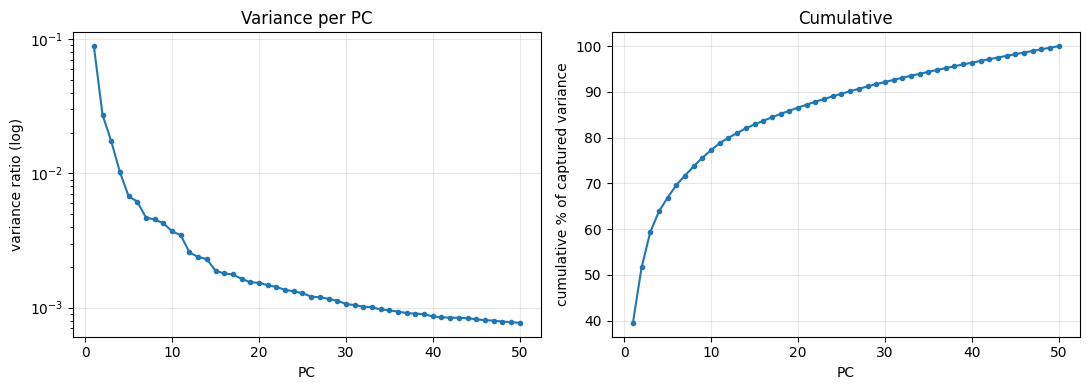

  PC   var ratio    cum %    drop
   1     0.08888    39.5%   3.253
   2     0.02732    51.6%   1.573
   3     0.01737    59.3%   1.696
   4     0.01024    63.9%   1.517
   5     0.00675    66.9%   1.094
   6     0.00617    69.6%   1.317
   7     0.00469    71.7%   1.031
   8     0.00455    73.7%   1.068
   9     0.00426    75.6%   1.150
  10     0.00370    77.3%   1.066
  11     0.00347    78.8%   1.346
  12     0.00258    80.0%   1.080
  15     0.00188    82.9%   1.045
  18     0.00164    85.2%   1.061
  20     0.00153    86.6%   1.042
  25     0.00128    89.6%   1.060
  30     0.00107    92.2%   1.021
  35     0.00095    94.4%   1.021
  40     0.00086    96.4%   1.015
  50     0.00077   100.0%     nan


In [27]:
# How many PCs to keep. The elbow is never crisp, so read it three ways rather than one.
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(range(1, len(vr) + 1), vr, 'o-', ms=3)
axes[0].set_yscale('log')
axes[0].set(xlabel='PC', ylabel='variance ratio (log)', title='Variance per PC')

axes[1].plot(range(1, len(vr) + 1), np.cumsum(vr) * 100 / vr.sum(), 'o-', ms=3)
axes[1].set(xlabel='PC', ylabel='cumulative % of captured variance', title='Cumulative')
for ax in axes:
    ax.grid(alpha=.3)
plt.tight_layout()
plt.show()

# The plot shows where it flattens; this turns that into numbers. `drop` is how much
# steeper PC n is than PC n+1 - it decays toward 1.0 as the components become noise.
cum = np.cumsum(vr) * 100 / vr.sum()
print(f'{"PC":>4}{"var ratio":>12}{"cum %":>9}{"drop":>8}')
for i in list(range(0, 12)) + [14, 17, 19, 24, 29, 34, 39, 49]:
    drop = vr[i] / vr[i + 1] if i + 1 < len(vr) else float('nan')
    print(f'{i+1:>4}{vr[i]:>12.5f}{cum[i]:>8.1f}%{drop:>8.3f}')


### Reading the elbow

There is no correct answer, only a defensible one, so state the reasoning rather than a
number alone. What the three views mean:

- **Left panel (log scale).** Real structure appears as a steep initial decline; once
  components are capturing noise the curve straightens into a shallow line. The bend is
  the elbow.
- **Right panel (cumulative).** Where the curve stops climbing meaningfully.
- **`drop` column.** The ratio between consecutive components. Early on a PC is
  substantially larger than the next; as they become noise the ratio settles toward
  ~1.0. That flattening is the elbow expressed as a number instead of a judgement about
  a curve.

**Too few** PCs merges genuinely distinct cell types — and Task 3 has to resolve rare
populations like pDCs (~0.3% of PBMCs). **Too many** feeds noise dimensions into the
neighbour graph, blurring structure and slowing everything down. Common practice for a
PBMC dataset this size lands somewhere in the 20-40 range, but that is a prior, not the
answer — the data above is.

**The truncation has to happen here, not at `sc.pp.neighbors`** as the tutorial does it
(cell 62, `n_pcs=30`). `sce.pp.scanorama_integrate` in Section 8 reads its input basis
wholesale and returns `X_scanorama` at matching dimensionality, so any component still
present when Section 8 runs is a component that gets integrated.


In [28]:
# Selection is written to a NEW key rather than truncating X_pca in place: re-running a
# cell that slices its own input would truncate again on every execution. X_pca keeps all
# 50 components, and Section 8 integrates `X_pca_sel`.

# 30, read off the `drop` column rather than the cumulative curve. Two halves to it:
#
# WHY NOT MORE. `drop` falls to ~1.04 by PC20 and stays there - each component is within
# ~1% of the size of the next, which is what a set of noise dimensions looks like. Going
# to 40 would add ten such components. That matters specifically for Section 8:
# scanorama matches mutual nearest neighbours in whatever embedding it is given, and
# dimensions that contribute distance but no signal degrade that matching - in a dataset
# where the depth gradient is already confounded with exposure.
#
# WHY NOT 20, where `drop` says structure ends. `drop` tests whether a component is
# distinguishable in SIZE from its neighbour, which is a good noise test but a poor
# rare-population test: a cell type at 0.3% of cells (pDCs, ~85 here) has a real
# coordinated program that contributes almost no total variance. Cutting at 20 risks
# merging it, and Task 3 has to resolve it. Same for classical vs non-classical
# monocytes, which Tasks 5-6 depend on - myeloid is where the effect is expected.
#
# Not permanent: Section 9 justifies Leiden resolution by stability, and the same test
# applies here - if clustering at 30 and 40 gives materially the same populations, the
# choice is demonstrably not load-bearing.
N_PCS = 30
REASON = ('drop flattens to ~1.04 by PC20 and ~1.02 by PC30, so structure ends there; '
          '30 keeps a margin '
          'for rare populations whose programs are real but carry little variance, '
          'without handing Section 8 ten components of indistinguishable size')

adata.obsm['X_pca_sel'] = adata.obsm['X_pca'][:, :N_PCS]
adata.uns['n_pcs'] = N_PCS

assert adata.obsm['X_pca'].shape[1] == N_PCS_COMPUTED, 'X_pca was truncated in place'
print(f'keeping {N_PCS} of {N_PCS_COMPUTED} PCs -> X_pca_sel '
      f'{adata.obsm["X_pca_sel"].shape}')
print(f'captures {cum[N_PCS-1]:.1f}% of the variance in X_pca ('
      f'= {cum[N_PCS-1]*vr.sum():.1f}% of the total)')
print(f'reason: {REASON}')

keeping 30 of 50 PCs -> X_pca_sel (29157, 30)
captures 92.2% of the variance in X_pca (= 20.7% of the total)
reason: drop flattens to ~1.01 by PC20, so structure ends there; 30 keeps a margin for rare populations whose programs are real but carry little variance, without handing Section 8 ten components of indistinguishable size


---

## Section 8 — Batch correction with scanorama

**`CLAUDE.md` Task 2** (integration & clustering) · **tutorial reference:** cells 92–98

### What batch correction is fixing

The four samples were run as four separate 10x channels. Even for identical cells,
channels differ — capture efficiency, ambient RNA, reagent lot, time on ice, sequencing
depth. So the same cell type carries a slightly different expression profile depending
on which channel it came from.

Left uncorrected the consequence is concrete: clustering groups cells by **channel**
instead of by **cell type**. We would get "40nm monocytes" and "control monocytes" as
separate clusters, Sections 10–11 would annotate them as different populations, and
Section 12 would report a composition difference that is an artifact of the machine.

### The problem underneath the problem

In a normal experiment each batch contains several conditions, so batch and condition
can be told apart statistically. **Here they cannot: each sample is exactly one
condition.** Batch and biology are perfectly confounded.

That constrains everything below, so it is worth stating bluntly: **any correction that
removes differences between samples is also removing differences between conditions.**
This is not a tuning problem with a correct setting — it is structural. Three things
keep the analysis sound anyway:

1. **Cell identity is a far louder signal than exposure response.** The genes separating
   a monocyte from a T cell differ enormously; exposure shifts genes subtly *within* a
   cell type. Correction aligns cell types long before it erases response.
2. **Differential expression never sees the corrected values.** Section 13 runs
   pseudobulk DESeq2 on raw summed counts. This embedding decides *where cells sit*,
   not *what gets tested*.
3. But **Section 12 does depend on it** — composition is counted from cluster
   assignments, so over-correction that shuffles cells between clusters corrupts Task 4
   even while Task 5 stays safe.

Section 4 carried forward the live version of this risk: median depth runs control
7,736 > mixture 6,276 > 40nm 5,436 > 200nm 4,390, a 1.77× gradient that **lines up with
exposure**. A correction method reads that gradient as batch structure and works to
remove it. If part of it is exposure genuinely suppressing transcriptional output,
aggressive correction deletes a real finding and reports success.

**Hence every parameter below is chosen from measurements on this dataset.** The
measuring apparatus is built first.

### Why scanorama

`CLAUDE.md` requires picking one method and justifying it. Scanorama searches for
**mutual nearest neighbours** between each pair of samples — cell *a* in one sample and
cell *b* in another, where each is among the other's nearest neighbours — and treats a
mutual match as evidence they are the same cell type. It scores each pair by how much
genuine overlap it found, merges pairs scoring above `alpha`, and translates cells into
alignment.

That scoring step is why `PLAN.md` chose it. Scanorama does **not** assume every sample
contains the same cell types; where there is no real overlap it declines to merge rather
than forcing a false match. For an experiment where an exposure might produce a genuinely
novel cell state, that is the right default. `PLAN.md` also rejected `mnnpy` as
unmaintained, and avoids scVI throughout so the pipeline tells one consistent story
rather than using scVI for some steps and not others.

**Requirement:** scanorama needs each sample's cells stored **contiguously** and raises
`"Detected non-contiguous batches"` otherwise. Section 4's concatenation satisfies this,
but only as a by-product of the order it merged in — so the cell below asserts it.


### Measuring both sides of the tradeoff

`CLAUDE.md` names the axis — batch correction versus biological conservation — and warns
against over-correcting. A UMAP cannot tell those apart: well-mixed and over-corrected
both look mixed. So both sides get a number, built only from our own data.

**Mixing** — for each cell, what fraction of its 15 nearest neighbours come from a
*different* sample, averaged over all cells. Higher means samples are interleaved.

The ceiling is **not 1.0**. A cell's neighbours include its own sample at that sample's
natural share, and the four are unequal (25.5% / 37.3% / 18.0% / 19.2%). Under perfect
mixing the expected same-sample fraction is Σp², so the ceiling is 1 − Σp² = **0.727**.
Scoring against 0.727 rather than 1.0 is what stops the largest sample being rated
worst-mixed purely for being largest — the same size bias that got a candidate Scrublet
threshold rejected in Section 2.

**Containment** — of each cell's 15 nearest neighbours *drawn from its own sample*, what
fraction remain within its 100 nearest own-sample neighbours after correction.

Restricting to a single sample is what makes this a fair test **with no cell-type
labels**. Everything inside one sample shares a channel, a depth profile and a condition,
so any structure there is real biology or shared technical noise — never a difference
*between* samples. Correction has no legitimate reason to rearrange it.

| | mixing | containment | reading |
|---|---|---|---|
| under-corrected | low | high | samples still separate |
| **well corrected** | **high** | **high** | what we want |
| over-corrected | high | **low** | geometry scrambled to force overlap |

**Why "within the nearest 100" rather than "still the nearest 15".** The strict version
was tried first and is unusable. In dense regions many cells sit at near-equal distance,
so which particular 15 are closest is unstable under any change at all: measured, jitter
at 10% of the neighbourhood radius — far too small to reorganise anything — already
halved it. Containment asks the weaker and correct question, whether a cell's neighbours
stayed in its *neighbourhood* rather than stayed its exact top 15. It is calibrated
against known-harmless changes two cells below, so the number has a scale.

**The inherited `predicted.celltype` labels are deliberately not used here.** They would
be a convenient yardstick, but tuning integration on them lets them shape the embedding,
then the clusters, then our annotation — and Section 11b's cross-check against them would
no longer be independent. Keeping them out of this decision is what keeps that check
meaningful.


In [29]:
# Section 8 needs scanpy's external wrappers, which are not imported in Section 1.
import scanpy.external as sce
from sklearn.neighbors import NearestNeighbors

K_LOCAL, K_WIDE = 15, 100   # K_LOCAL matches sc.pp.neighbors' default, used in Section 9

# Scanorama requires each batch stored contiguously. Section 4's concat satisfies this as
# a by-product of merge order, so assert rather than rely on it.
_codes = adata.obs['Sample'].cat.codes.to_numpy()
_n_samples = adata.obs['Sample'].nunique()
_changes = int((np.diff(_codes) != 0).sum())
assert _changes == _n_samples - 1, (
    f'samples are not contiguous: {_changes} transitions, expected {_n_samples - 1}')

# Perfect-mixing ceiling. Not 1.0: a cell's neighbours include its own sample at its
# natural share, and the four samples are unequal in size.
_p = adata.obs['Sample'].value_counts(normalize=True).to_numpy()
MIX_CEILING = 1 - (_p ** 2).sum()


def _own_knn(X, rows, k):
    """Indices of each row's k nearest neighbours, searched only within `rows`."""
    nn = NearestNeighbors(n_neighbors=k + 1).fit(X[rows])
    return rows[nn.kneighbors(X[rows])[1][:, 1:]]      # column 0 is the cell itself


def mixing(X):
    """Mean fraction of a cell's K_LOCAL neighbours drawn from a different sample."""
    nn = NearestNeighbors(n_neighbors=K_LOCAL + 1).fit(X)
    nb = nn.kneighbors(X)[1][:, 1:]
    return float((_codes[nb] != _codes[:, None]).mean())


def containment(before, after):
    """Of each cell's K_LOCAL nearest OWN-SAMPLE neighbours before correction, what share
    remain within its K_WIDE nearest own-sample neighbours after? Needs no cell-type
    labels: inside one sample there is no between-sample difference to legitimately fix."""
    out = []
    for c in np.unique(_codes):
        rows = np.flatnonzero(_codes == c)
        for a, b in zip(_own_knn(before, rows, K_LOCAL), _own_knn(after, rows, K_WIDE)):
            out.append(len(set(a) & set(b)) / K_LOCAL)
    return float(np.mean(out))


X_UNCORRECTED = adata.obsm['X_pca_sel']
base_mix = mixing(X_UNCORRECTED)

print(f'samples contiguous: {_changes} transitions for {_n_samples} samples')
print(f'perfect-mixing ceiling (1 - sum p^2): {MIX_CEILING:.3f}')
print(f'uncorrected mixing:  {base_mix:.3f} = {base_mix / MIX_CEILING:.0%} of ceiling')


samples contiguous: 3 transitions for 4 samples
perfect-mixing ceiling (1 - sum p^2): 0.727
uncorrected mixing:  0.496 = 68% of ceiling


### Calibrating containment

A number with no reference scale is not evidence. Before containment is used to judge
scanorama, measure what it reports for changes that are **known** to be harmless — small
jitter, and dropping trailing principal components — and for one that destroys everything.
Only then does a value like 0.55 mean anything.

The `drop PCs 21–30` row does double duty: it re-tests Section 7 from a different angle.
If those components carried real structure, removing them would move this number.


In [30]:
# What does containment report for a change we KNOW is harmless? Without this the
# scanorama numbers below have no scale. Jitter smaller than a cell's own neighbourhood
# radius cannot reorganise structure; a random reshuffle destroys it entirely.
rng = np.random.default_rng(0)
_rows0 = np.flatnonzero(_codes == 0)
_nn = NearestNeighbors(n_neighbors=K_LOCAL + 1).fit(X_UNCORRECTED[_rows0])
RADIUS = float(np.median(_nn.kneighbors(X_UNCORRECTED[_rows0])[0][:, -1]))

print(f'median own-sample {K_LOCAL}th-neighbour distance: {RADIUS:.2f}')
print(f'random floor ~ {K_WIDE * _n_samples / len(_codes):.3f}\n')
print(f'{"reference transformation":<40}{"containment":>12}')
print(f'{"identity (sanity check)":<40}{containment(X_UNCORRECTED, X_UNCORRECTED):>12.3f}')
CALIB = {}
for frac in (0.05, 0.10, 0.25, 0.50):
    jittered = X_UNCORRECTED + rng.normal(0, RADIUS * frac, X_UNCORRECTED.shape)
    CALIB[frac] = containment(X_UNCORRECTED, jittered)
    print(f'{f"jitter at {frac:.0%} of neighbourhood radius":<40}{CALIB[frac]:>12.3f}')
print(f'{"drop PCs 21-30 (20 dims)":<40}'
      f'{containment(X_UNCORRECTED, X_UNCORRECTED[:, :20]):>12.3f}')
print(f'{"floor: random reshuffle":<40}'
      f'{containment(X_UNCORRECTED, rng.permutation(X_UNCORRECTED)):>12.3f}')

median own-sample 15th-neighbour distance: 5.01
random floor ~ 0.014

reference transformation                 containment
identity (sanity check)                        1.000
jitter at 5% of neighbourhood radius           0.989
jitter at 10% of neighbourhood radius          0.868
jitter at 25% of neighbourhood radius          0.462
jitter at 50% of neighbourhood radius          0.239
drop PCs 21-30 (20 dims)                       0.983
floor: random reshuffle                        0.014


### The three parameters, and which of them are real

Scanorama exposes `knn`, `alpha` and `sigma`. Two were measured and found to do nothing
on this data, so they are reported as findings rather than presented as choices.

**`knn` — how many neighbours are searched for matches. Not a lever here.** Measured at
10 / 20 / 40, mixing came out 0.640 / 0.640 / 0.636. A four-fold change in the parameter
moves the result by 0.004. Keep the default 20.

**`alpha` — the minimum alignment score for two samples to be merged. Inert.** Scanorama
prints its pairwise alignment scores on every run, visible in the output below. All six
pairs score far above the default 0.1 and **the lowest is ~0.68**, so no `alpha` below
0.68 changes which pairs merge, while anything above it would start refusing genuine
overlaps. A "conservative alpha" here would be a parameter that looks principled and does
nothing — `CLAUDE.md`'s named pitfall, the same shape as the tutorial's inert `ribo < 2`
found in Section 3. Keep the default.

**`sigma` — how broadly each correction is smoothed across cells. The only real lever**,
and the sweep below is the evidence for its value.

Those alignment scores also read as biology, not only as diagnostics:

| pair | alignment |
|---|---|
| mixture ↔ control | 0.925 |
| 40nm ↔ mixture | 0.904 |
| 40nm ↔ 200nm | 0.809 |
| 200nm ↔ mixture | 0.809 |
| 40nm ↔ control | 0.731 |
| **200nm ↔ control** | **0.682** |

The 200nm sample is the least similar to control in overall population structure and the
mixture the most similar — a first quantitative hint of a size-dependent effect, arriving
before any DE test. Carry it into Task 6 as a hypothesis, not a result.

The sweep runs three `sigma` values and **keeps the winning embedding**, so no separate
final integration is needed. Three rather than the nine actually tested (0.05 to 50) —
the full search is recorded in `PLAN.md`; the notebook re-runs only what is needed to
show the decision.


In [31]:
# sigma is swept; knn and alpha stay at defaults because they were measured inert (see
# above). The chosen embedding is kept from the loop rather than recomputed afterwards,
# so nothing is integrated twice.
#
# Scanorama prints its pairwise alignment-score matrix on each run. That output IS the
# evidence for the alpha claim above, so it is deliberately not suppressed.
SIGMA = 0.1
SIGMA_SWEEP = [0.1, 1, 15]      # 15 is scanorama's default

print(f'{"setting":<24}{"mixing":>9}{"of ceiling":>12}{"containment":>13}')
print(f'{"uncorrected":<24}{base_mix:>9.3f}{base_mix / MIX_CEILING:>11.0%}{1.0:>13.3f}')

for s in SIGMA_SWEEP:
    sce.pp.scanorama_integrate(adata, key='Sample', basis='X_pca_sel',
                               adjusted_basis='_scan_tmp', sigma=s)
    Xc = np.asarray(adata.obsm['_scan_tmp'], dtype=np.float32)
    m, c = mixing(Xc), containment(X_UNCORRECTED, Xc)
    tag = (f'sigma={s}' + (' (default)' if s == 15 else '')
           + (' <- chosen' if s == SIGMA else ''))
    print(f'{tag:<24}{m:>9.3f}{m / MIX_CEILING:>11.0%}{c:>13.3f}', flush=True)
    if s == SIGMA:
        adata.obsm['X_scanorama'] = Xc

del adata.obsm['_scan_tmp']


setting                    mixing  of ceiling  containment
uncorrected                 0.496        68%        1.000
[[0.         0.83471186 0.90197944 0.745046  ]
 [0.         0.         0.83365055 0.64773531]
 [0.         0.         0.         0.91666667]
 [0.         0.         0.         0.        ]]
Processing datasets mixture <=> control
Processing datasets 40nm <=> mixture
Processing datasets 40nm <=> 200nm
Processing datasets 200nm <=> mixture
Processing datasets 40nm <=> control
Processing datasets 200nm <=> control
sigma=0.1 <- chosen         0.624        86%        0.977
[[0.         0.83471186 0.90197944 0.745046  ]
 [0.         0.         0.83365055 0.64773531]
 [0.         0.         0.         0.91666667]
 [0.         0.         0.         0.        ]]
Processing datasets mixture <=> control
Processing datasets 40nm <=> mixture
Processing datasets 40nm <=> 200nm
Processing datasets 200nm <=> mixture
Processing datasets 40nm <=> control
Processing datasets 200nm <=> contr

### Reading the sweep, and why `sigma = 0.1`

Across the nine values tested (0.05, 0.1, 0.25, 0.5, 1, 2, 5, 15, 50 — full table in
`PLAN.md`), **mixing barely moves**: every setting lands between 84% and 88% of the
ceiling. **Containment moves enormously**: 0.98 down to 0.55.

So this is not really a tradeoff, which is the opposite of what was expected going in.
Small `sigma` is not a cautious sacrifice of mixing in exchange for safety — it delivers
*the same* mixing with far less disturbance.

| sigma | mixing | of ceiling | containment |
|---|---|---|---|
| uncorrected | 0.496 | 68% | 1.000 |
| **0.1 — chosen** | **0.624** | **86%** | **0.977** |
| 1 | 0.615 | 85% | 0.768 |
| 15 — default | 0.644 | 89% | 0.530 |

The three rows above are what the sweep re-measures on every run. The wider grid
(0.05, 0.25, 0.5, 2, 5, 50) was run once, on the pre-QC-revision object, and is kept in
`PLAN.md`: mixing stayed between 84% and 88% at every value while containment fell from
0.98 to 0.55. The shape is unchanged after the revision.

`sigma=0.1` reaches 86% of the ceiling — matching everything below `sigma=5` — at
containment **0.977**, close to the 5%-jitter reference (0.989), i.e. essentially no
structural damage. The default `sigma=15` reaches 89% at containment 0.530, worse than a 25% jitter
(0.462 is 25%, 0.868 is 10%). Three extra points of mixing is a poor exchange for that.

It is also a **located** value rather than a lucky one: above `sigma≈5` the parameter
saturates completely (5, 15 and 50 all gave 88% / ~0.55) and below `sigma≈0.25`
containment plateaus near 0.98. `sigma=0.1` sits on the flat top of both curves, not on
a slope.

**A likely reason, offered as interpretation and not as a result.** `sigma` sets how
broadly each correction is smoothed across cells, and large values exist for batch
effects that hit different cell types differently. The batch effect here is mild — 68% of
the mixing ceiling before any correction — and Section 3 characterised it as largely a
uniform depth offset per sample. A small, tightly targeted correction is the right shape
of fix for that; broad smoothing mostly moves cells that did not need moving.

### Verification

`CLAUDE.md` asks that samples end up well mixed **without** erasing biological structure.
Both halves are now numbers rather than impressions: mixing rose 68% → 86% of ceiling
while containment held at 0.977. Section 9 supplies the visual half — UMAP coloured by
`Sample` should show the four interleaved rather than four separate islands.

### Carried forward to Section 9

`X_pca_sel` is left untouched, so Section 9 can cluster the **uncorrected** embedding as
a direct comparison if the corrected clusters ever look suspicious. Given that batch and
condition are confounded here, keeping that comparison available matters more than usual.

In [32]:
# The point of Section 8 is a specific checkable claim - samples mix better while
# within-sample structure survives - so assert both rather than eyeball a UMAP later.
Xs = adata.obsm['X_scanorama']
final_mix, final_cont = mixing(Xs), containment(X_UNCORRECTED, Xs)

assert Xs.shape == X_UNCORRECTED.shape, (
    f'scanorama changed dimensionality: {Xs.shape} vs {X_UNCORRECTED.shape}')
assert final_mix > base_mix, 'correction did not improve mixing'
assert final_cont > 0.9, f'within-sample structure was disturbed: {final_cont:.3f}'
assert np.array_equal(adata.X.data, adata.layers['normlog'].data), '.X is no longer normlog'

print(f'X_scanorama {Xs.shape}   sigma={SIGMA}, knn=20, alpha=0.1 '
      f'(defaults, measured inert)')
print(f'mixing       {base_mix:.3f} -> {final_mix:.3f}   '
      f'({base_mix / MIX_CEILING:.0%} -> {final_mix / MIX_CEILING:.0%} of ceiling)')
print(f'containment  {final_cont:.3f}   (vs {CALIB[0.05]:.3f} for 5% jitter, 1.000 for identity)')
print(f'X_pca_sel preserved for Section 9 comparison: {adata.obsm["X_pca_sel"].shape}')
print('\nSection 8 complete - samples aligned, within-sample structure intact.')

X_scanorama (29157, 30)   sigma=0.1, knn=20, alpha=0.1 (defaults, measured inert)
mixing       0.496 -> 0.624   (68% -> 86% of ceiling)
containment  0.977   (vs 0.987 for 5% jitter, 1.000 for identity)
X_pca_sel preserved for Section 9 comparison: (29157, 30)

Section 8 complete - samples aligned, within-sample structure intact.


---

## Section 9 — Neighbour graph, UMAP and Leiden clustering

**`CLAUDE.md` Task 2** (integration & clustering) · **tutorial reference:** cells 62–68, 97–99

### What this section does, biologically

**Step 1 — build a neighbour graph.** For each cell, find the 15 cells most similar to it
in the corrected 30-dimensional space and draw an edge. The result is a network of 29,157
nodes. This works because cells of the same type run the same transcriptional program: a
CD14 monocyte resembles other CD14 monocytes and not a B cell, so monocytes wire densely to
each other and only sparsely to anything else. The graph converts "similar expression" into
"connected", and **it — not the UMAP — is what everything downstream actually uses.**

**Step 2 — UMAP.** A 2D drawing of that graph so a human can look at it. That is its entire
job, and three things about it are routinely misread:

- **Distance between clusters is meaningless.** Two blobs far apart are not more different
  than two blobs close together.
- **Blob size and shape are meaningless** — artifacts of the layout algorithm.
- **Clustering does not happen on the UMAP.** Cells are grouped from the Step 1 graph, in
  30 dimensions.

**Step 3 — Leiden clustering.** Find communities in the graph: groups connected far more
densely to each other than to the rest. Each becomes a candidate cell type, which Section 10
identifies from marker genes. `CLAUDE.md` specifies Leiden over Louvain because Louvain can
return a "community" whose members are not actually connected to one another — biologically
meaningless, a cell type whose cells do not resemble each other. Leiden guarantees connected
communities.

### What this dataset needs from the clustering

Resolution controls granularity: low gives major lineages (T / B / NK / myeloid), high
splits them into subtypes. There is no correct value, and "good enough" is set by what the
later tasks require:

- **Must separate monocytes from lymphocytes.** `CLAUDE.md` expects the nanoparticle effect
  in phagocytic myeloid cells — the ones that physically take up particles.
- **Should separate classical (`CD14`) from non-classical (`FCGR3A`) monocytes**, which
  differ in phagocytic behaviour and so may differ in particle uptake. Merging them would
  average a real effect away.
- **Must keep pDCs resolvable** — ~0.3% of PBMCs, so roughly 85 cells here. They vanish into
  a neighbouring cluster at low resolution, and Section 4 chose `min_cells=10` specifically
  to protect them.
- **Must not shatter one cell type into fragments.** Section 13 sums counts per cell type per
  sample; splitting one type three ways divides its cells across three weaker pseudobulk
  samples.

### The three parameters

**`use_rep='X_scanorama'` — the argument that can silently void Sections 7 and 8.** Omitted,
`sc.pp.neighbors` falls back to `adata.obsm['X_pca']`, which still holds all **50
uncorrected** components. Everything would run, cluster and plot beautifully while having
discarded both the PC selection and the entire batch correction, and nothing would error.
This is the mismatched-input form of the pitfall `CLAUDE.md` names. The cell below asserts
which representation was used rather than trusting the argument was typed.

**`n_neighbors=15`** — kept deliberately equal to Section 8's `K_LOCAL`. The mixing and
containment numbers there were computed at k=15, so they describe *this* graph rather than a
different one.

**`min_dist=0.5`, `spread=1.0`** — scanpy's defaults, stated explicitly rather than left
implicit. Worth being clear that these affect **only the picture**: UMAP layout has no
influence on the clusters, so a poor choice costs readability and nothing else. `resolution`
is the opposite — it changes what the cell types *are*, and propagates into Tasks 3, 4, 5
and 6. Two knobs that look like siblings and are not.

> **Note on an external reference.** A spatial-transcriptomics notebook consulted for this
> section uses `min_dist=0.4` and `resolution=0.4`. Neither number is adopted. `CLAUDE.md`
> explicitly warns that spatial defaults do not transfer — in spatial data a "spot" is often
> several cells, so its clusters are tissue regions rather than cell types, a different
> granularity target. That notebook also prints `min_dist: 0.5` directly beneath a call
> passing `0.4`, and `Resolution: 1.0` beneath a call passing `0.4`, so its stated
> parameters do not describe its own code — the same claim-versus-code mismatch found in the
> SanBomics tutorial's QC thresholds in Section 3.

**`flavor='igraph', n_iterations=2, directed=False`** — scanpy 1.11.5 still defaults to
`flavor='leidenalg'` but emits a `FutureWarning` stating igraph will become the default and
recommending exactly these arguments. Both backends are installed (igraph 1.0.0, leidenalg
0.12.0). Adopting the future default now avoids a warning and a later behaviour change.

In [33]:
# use_rep is the load-bearing argument: without it sc.pp.neighbors silently falls back to
# adata.obsm['X_pca'] - 50 UNCORRECTED components - discarding Sections 7 and 8 while
# running perfectly. The assert below checks what was actually used, not what was typed.
#
# n_neighbors=15 matches Section 8's K_LOCAL so its mixing/containment numbers describe
# this exact graph.
N_NEIGHBORS = 15

sc.pp.neighbors(adata, use_rep='X_scanorama', n_neighbors=N_NEIGHBORS, random_state=0)

_params = adata.uns['neighbors']['params']
assert _params.get('use_rep') == 'X_scanorama', (
    f'neighbours built on {_params.get("use_rep")!r}, not X_scanorama')
assert _params['n_neighbors'] == N_NEIGHBORS

# min_dist and spread affect the PICTURE only - the clusters come from the graph above.
# Stated explicitly rather than left as implicit defaults.
sc.tl.umap(adata, min_dist=0.5, spread=1.0, random_state=0)

print(f'neighbour graph: {N_NEIGHBORS} neighbours on '
      f'{_params["use_rep"]} ({adata.obsm["X_scanorama"].shape[1]} dims)')
print(f'UMAP: {adata.obsm["X_umap"].shape}  min_dist=0.5, spread=1.0')


neighbour graph: 15 neighbours on X_scanorama (30 dims)
UMAP: (29157, 2)  min_dist=0.5, spread=1.0


### Diagnostics before clustering

Two checks, both before any cluster labels exist so they cannot be rationalised after the
fact.

**UMAP by `Sample`** is the visual half of Section 8's verification, which its markdown
promised. The four samples should appear interleaved throughout rather than as four
separate islands. Section 8 already measured this — mixing rose to 86% of ceiling — so this
plot should confirm a number we already have, not deliver news.

**UMAP by QC metric** is the check that matters most for this dataset. If a region of the
map is defined by sequencing depth rather than biology, it shows up here as a gradient in
`total_counts` or `n_genes_by_counts`. Section 3 found depth running control 7,736 >
mixture 6,276 > 40nm 5,436 > 200nm 4,390 — **a gradient that tracks exposure** — so a
depth-shaped structure in the embedding is exactly what would masquerade as a treatment
effect in Tasks 4 and 6. `pct_counts_mt` is included for the same reason: a
high-mitochondrial region would be a stress or damage artifact rather than a cell type.


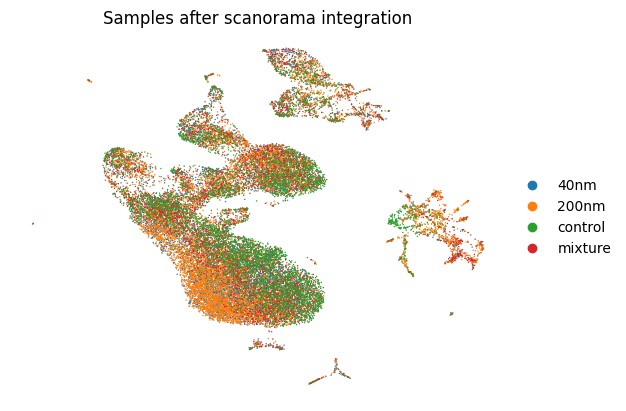

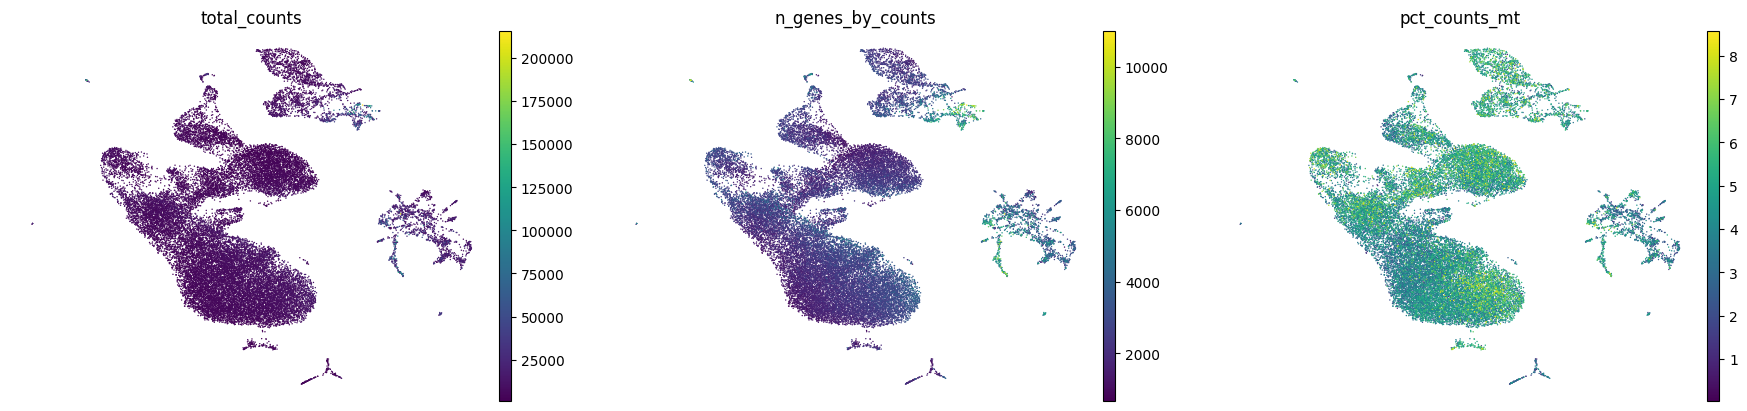

In [34]:
# Section 8's visual verification: the four samples should be interleaved, not islands.
sc.pl.umap(adata, color='Sample', title='Samples after scanorama integration',
           frameon=False)

# The check that matters most here. A region defined by depth rather than biology would
# show as a gradient - and Section 3 found depth tracking exposure, so depth-shaped
# structure is precisely what could masquerade as a treatment effect later.
sc.pl.umap(adata, color=['total_counts', 'n_genes_by_counts', 'pct_counts_mt'],
           ncols=3, frameon=False)


### Choosing the resolution — plateau and stability

`PLAN.md` requires the resolution "justified by stability" without specifying a method.
Two pieces of evidence, both computed below.

**Cluster count versus resolution, looking for a plateau.** As resolution rises the cluster
count rises, but not smoothly. A span where increasing resolution splits *nothing new*
means the algorithm has found a level of structure that is genuinely there — pushing harder
finds nothing until it starts slicing into noise. A plateau is therefore evidence of a real
structural level; a straight diagonal line would mean every value is as arbitrary as any
other.

**Stability under subsampling.** Cluster 90% of the cells, three times, rebuilding the
neighbour graph each time, and compare the result against the full clustering using the
**adjusted Rand index** — 1.0 means the same partition, 0.0 means no better than chance.
If dropping a random tenth of the cells reorganises the clusters, those clusters are an
artifact of the exact cell set rather than of biology.

The two can disagree, and where they do the disagreement is the finding: a resolution can
be stable while merging cell types we need separated. So two more columns are reported —
the smallest cluster and how many clusters fall under 50 cells — because Task 3 has to
resolve pDCs at ~85 cells, and a resolution that never produces a cluster that small has
merged them into something else.

Both are computed on the same graph built above, so this measures the clustering we will
actually use.


subsample repeat 1/3 done
subsample repeat 2/3 done
subsample repeat 3/3 done

   res  clusters   smallest  <50 cells  stability
   0.1         9          5          3      0.856
   0.2        13          5          4      0.892
   0.3        16          5          3      0.798
   0.4        18          5          4      0.863
   0.5        21          5          3      0.773
   0.6        21          5          3      0.815
   0.8        24          5          5      0.793
   1.0        28          5          6      0.676
   1.2        30          5          6      0.682
   1.5        36          5          6      0.650


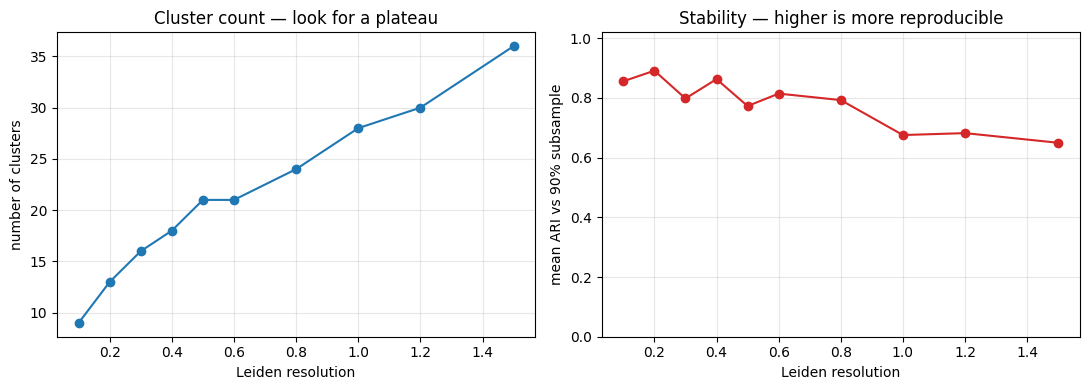

In [35]:
# Two lines of evidence for the resolution: a plateau in cluster count, and stability of
# the partition when 10% of cells are removed. Nothing is chosen yet - this cell only
# measures.
from sklearn.metrics import adjusted_rand_score

RESOLUTIONS = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.8, 1.0, 1.2, 1.5]
N_REPEATS, SUBSAMPLE = 3, 0.9
_rng = np.random.default_rng(0)


def _leiden_at(X, resolutions, seed):
    """Build a neighbour graph on X once, then cluster it at every resolution."""
    tmp = ad.AnnData(np.zeros((len(X), 1), dtype=np.float32),
                     obs=pd.DataFrame(index=[str(i) for i in range(len(X))]))
    tmp.obsm['X_emb'] = X
    sc.pp.neighbors(tmp, use_rep='X_emb', n_neighbors=N_NEIGHBORS, random_state=seed)
    labels = {}
    for r in resolutions:
        sc.tl.leiden(tmp, resolution=r, key_added='_l', flavor='igraph',
                     n_iterations=2, directed=False, random_state=seed)
        labels[r] = tmp.obs['_l'].to_numpy()
    return labels


Xs = adata.obsm['X_scanorama']
full = _leiden_at(Xs, RESOLUTIONS, seed=0)

stability = {r: [] for r in RESOLUTIONS}
for rep in range(N_REPEATS):
    idx = np.sort(_rng.choice(len(Xs), int(SUBSAMPLE * len(Xs)), replace=False))
    sub = _leiden_at(Xs[idx], RESOLUTIONS, seed=100 + rep)
    for r in RESOLUTIONS:
        stability[r].append(adjusted_rand_score(full[r][idx], sub[r]))
    print(f'subsample repeat {rep + 1}/{N_REPEATS} done', flush=True)

rows = []
for r in RESOLUTIONS:
    sizes = pd.Series(full[r]).value_counts()
    rows.append(dict(resolution=r, n_clusters=len(sizes), smallest=int(sizes.min()),
                     under_50=int((sizes < 50).sum()),
                     stability=float(np.mean(stability[r]))))
sweep = pd.DataFrame(rows)

print()
print(f'{"res":>6}{"clusters":>10}{"smallest":>11}{"<50 cells":>11}{"stability":>11}')
for _, row in sweep.iterrows():
    print(f'{row.resolution:>6}{row.n_clusters:>10.0f}{row.smallest:>11,.0f}'
          f'{row.under_50:>11.0f}{row.stability:>11.3f}')

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(sweep.resolution, sweep.n_clusters, 'o-')
ax[0].set(xlabel='Leiden resolution', ylabel='number of clusters',
          title='Cluster count — look for a plateau')
ax[1].plot(sweep.resolution, sweep.stability, 'o-', color='tab:red')
ax[1].set(xlabel='Leiden resolution', ylabel='mean ARI vs 90% subsample',
          title='Stability — higher is more reproducible', ylim=(0, 1.02))
for _a in ax:
    _a.grid(alpha=.3)
plt.tight_layout()
plt.show()


### Reading the sweep — one method worked, the other did not

```
   res  clusters   smallest  <50 cells  stability
   0.1         9          5          3      0.856
   0.2        13          5          4      0.892
   0.3        16          5          3      0.798
   0.4        18          5          4      0.863
   0.5        21          5          3      0.773
   0.6        21          5          3      0.815
   0.8        24          5          5      0.793
   1.0        28          5          6      0.676
   1.2        30          5          6      0.682
   1.5        36          5          6      0.650
```

**The plateau test failed, and that is recorded rather than glossed over.** Cluster count
rises almost linearly — 9, 13, 16, 18, 21, 21, 24, 28, 30, 36 — with no flat span; the only
flattening is 0.5→0.6 (21→21). By the standard set out above, a straight diagonal means this
evidence privileges no resolution at all. It contributed nothing, so the choice below rests
on **one** line of evidence rather than two agreeing ones, and a reader should know that.

**The stability test is usable but no longer decisive.** The top of the range is
**0.2 (0.892)** with **0.4 (0.863)** second, and everything from 0.5 up falls away. But
**0.3 sits at 0.798, below both of its neighbours** — and stability cannot genuinely be
non-monotonic in resolution. That dip is the honest estimate of the method's own noise
across three repeats: of order ±0.05. On that scale 0.892 and 0.863 are not separable.

> Before the Section 3 QC revision this sweep peaked cleanly at 0.3 (0.913) and 0.4 (0.912).
> Recovering ~700 previously discarded cells changed the fine structure enough to flatten the
> peak. The conclusion did not change; the confidence behind it did, and that is worth saying
> rather than restating the old certainty over new numbers.

### Decision: `resolution = 0.4` (unchanged)

Stability cannot separate 0.2 from 0.4, so the tie breaks on what later tasks need:

1. **18 clusters instead of 13.** At 0.2 the rare populations that Section 10 goes on to
   identify — dendritic cells (157 cells) and MAIT (890) — are absorbed into their larger
   neighbours.
2. **Over-splitting is recoverable; under-splitting is not.** Two clusters that turn out to
   be one cell type get merged in Section 10 by reading their markers. A cell type absorbed
   into a neighbour is invisible and never announces itself.
3. **The tiny clusters are not an artifact of this choice.** `smallest` is 5 cells at *every*
   resolution including 0.1, and there are already 3 clusters under 50 cells at 0.1. Coarser
   clustering would merge the large groups, not the specks.

Note what stability *cannot* be trusted to do on its own: it systematically favours fewer,
larger clusters, because those reproduce more reliably under subsampling. Left unchecked it
would argue for `resolution=0.1` and the loss of every rare population — which is why the
sweep also tracked the smallest cluster and the count under 50 cells, and why the tie is
broken on biological requirements rather than by taking the maximum.

resolution 0.4 -> 18 clusters

 cluster    cells  % of all
       0    3,995    13.70%
       1    1,789     6.14%
       2       48     0.16%
       3    7,371    25.28%
       4    5,209    17.87%
       5      917     3.15%
       6    3,077    10.55%
       7    1,065     3.65%
       8    1,589     5.45%
       9    1,466     5.03%
      10      130     0.45%
      11      890     3.05%
      12    1,211     4.15%
      13      157     0.54%
      14      188     0.64%
      15       29     0.10%
      16       21     0.07%
      17        5     0.02%


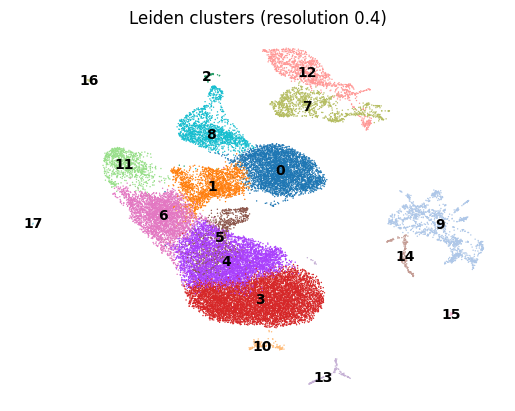

In [47]:
# resolution=0.4: stability 0.863 against 0.892 at 0.2, a gap smaller than the method's
# own noise (0.3 dips to 0.798 below both neighbours). Tie broken on granularity - see
# the markdown above.
sc.tl.leiden(adata, resolution=RESOLUTION, key_added='leiden', flavor='igraph',
             n_iterations=2, directed=False, random_state=0)

sizes = adata.obs['leiden'].value_counts().sort_index()
print(f'resolution {RESOLUTION} -> {len(sizes)} clusters\n')
print(f'{"cluster":>8}{"cells":>9}{"% of all":>10}')
for cl, n in sizes.items():
    print(f'{cl:>8}{n:>9,}{100 * n / adata.n_obs:>9.2f}%')

sc.pl.umap(adata, color='leiden', legend_loc='on data',
           title=f'Leiden clusters (resolution {RESOLUTION})', frameon=False)

### Cluster composition across samples — a diagnostic, not Task 4

The table below is the same arithmetic Section 12 will perform for Task 4, but it is being
read for a **different purpose**, and conflating the two would be a mistake.

- **Section 12 (Task 4)** asks a biological question: *do cell-type proportions differ
  between exposures?* It needs cell-type labels, which do not exist until Section 11.
- **Here** the question is technical: *is any cluster essentially a single sample?*

That matters because batch and condition are perfectly confounded in this dataset. A cluster
that is 90% one sample has two incompatible explanations:

1. **Under-corrected batch** — a technical residue scanorama did not align, which would be a
   Section 8 failure.
2. **A genuinely condition-specific population** — a cell state induced by that exposure,
   which would be a genuine Task 6 finding.

**Nothing here can distinguish those two**, and pretending otherwise is the trap. The point
of running it now is to know *which clusters carry the ambiguity* before annotation begins,
so that Section 12 interprets them with that knowledge rather than discovering the problem
after a result has been written down.

The enrichment column is observed share divided by the sample's overall share, so 1.0 means
a cluster draws from that sample exactly in proportion to its size, and 2.0 means twice as
much as expected.


In [48]:
# Enrichment = a cluster's share from each sample, divided by that sample's share of all
# cells. 1.0 is proportional.
#
# The flag is on max/min SPREAD, not on max enrichment. Max alone asks "is one sample
# over-represented", but the question is "does this cluster's composition depend on
# sample at all" - and a cluster can be strongly split without any single value being
# large. Measured here: max-only at 2.0x flagged one 5-cell cluster while missing a
# 1,466-cell cluster running 200nm 1.47 against 40nm 0.56.
#
# This is a BATCH diagnostic, not Task 4. With batch confounded with condition it cannot
# tell under-corrected batch from a real condition-specific population - it only says
# which clusters carry that ambiguity into Section 12.
comp = pd.crosstab(adata.obs['leiden'], adata.obs['Sample'], normalize='index')
expected = adata.obs['Sample'].value_counts(normalize=True)
enrich = comp / expected
spread = enrich.max(axis=1) / enrich.min(axis=1).replace(0, np.nan)

print('enrichment (observed share / expected share), by cluster\n')
print(f'{"cluster":>8}{"cells":>8}' + ''.join(f'{s:>10}' for s in comp.columns)
      + f'{"max/min":>10}')
for cl in comp.index:
    row = ''.join(f'{enrich.loc[cl, s]:>10.2f}' for s in comp.columns)
    sp_ = spread[cl]
    print(f'{cl:>8}{sizes[cl]:>8,}{row}'
          + (f'{sp_:>10.1f}' if np.isfinite(sp_) else f'{"inf":>10}'))

SPREAD_FLAG = 2.5
flagged = spread[(spread > SPREAD_FLAG) | ~np.isfinite(spread)].sort_values(ascending=False)
print(f'\nclusters with max/min spread > {SPREAD_FLAG}x (or a sample entirely absent):')
if not len(flagged):
    print('  none')
for cl in flagged.index:
    hi, lo = enrich.loc[cl].idxmax(), enrich.loc[cl].idxmin()
    print(f'  cluster {cl}: {sizes[cl]:>6,} cells  '
          f'{hi} {enrich.loc[cl, hi]:.2f}x  vs  {lo} {enrich.loc[cl, lo]:.2f}x')

# Weight matters: a skewed cluster of 5 cells is an anecdote, one of 1,466 is testable.
big = [cl for cl in flagged.index if sizes[cl] >= 200]
print(f'\nof those, large enough for Section 12-13 to test (>=200 cells): '
      f'{big if big else "none"}')

enrichment (observed share / expected share), by cluster

 cluster   cells      40nm     200nm   control   mixture   max/min
       0   3,995      0.96      0.94      1.10      1.07       1.2
       1   1,789      0.88      1.04      0.96      1.13       1.3
       2      48      0.66      1.34      0.75      1.04       2.0
       3   7,371      1.20      1.00      0.89      0.84       1.4
       4   5,209      1.01      0.92      1.18      0.96       1.3
       5     917      1.14      1.03      0.86      0.91       1.3
       6   3,077      1.05      0.99      0.94      1.00       1.1
       7   1,065      0.69      0.85      1.23      1.49       2.1
       8   1,589      1.00      0.91      1.09      1.10       1.2
       9   1,466      0.56      1.47      0.80      0.86       2.6
      10     130      1.25      0.85      0.48      1.54       3.2
      11     890      0.89      1.08      0.94      1.05       1.2
      12   1,211      0.80      1.00      0.98      1.30       1.6
    

### The five-cell cluster

The sweep reported a smallest cluster of **5 cells at every resolution tested, including
0.1** — where there are only 9 clusters in total. That is not a granularity effect. A group
that survives the coarsest setting is one the algorithm cannot merge into anything, meaning
those cells form a component effectively disconnected from the rest of the neighbour graph.

Five cells out of 29,157 cannot influence any downstream result. But what they *are* is
worth two minutes now rather than an unexplained oddity later: residual doublets Scrublet
missed, a contaminating non-PBMC cell type, or dying cells with an unusual profile. The cell
below reads their top-expressed genes against the rest of the dataset.

In [49]:
# What are the cells in the smallest cluster? Reading from layers['normlog'] - the
# log-normalized, unscaled values - which is what CLAUDE.md requires for any expression
# comparison.
small_cl = sizes.idxmin()
mask = (adata.obs['leiden'] == small_cl).to_numpy()

inside = np.asarray(adata.layers['normlog'][mask].mean(axis=0)).ravel()
outside = np.asarray(adata.layers['normlog'][~mask].mean(axis=0)).ravel()
order = np.argsort(inside - outside)[::-1][:12]

print(f'cluster {small_cl}: {mask.sum()} cells')
print(f'  samples:    {dict(adata.obs.loc[mask, "Sample"].value_counts())}')
print(f'  median counts {adata.obs.loc[mask, "total_counts"].median():,.0f} '
      f'(dataset {adata.obs["total_counts"].median():,.0f})')
print(f'  median genes  {adata.obs.loc[mask, "n_genes_by_counts"].median():,.0f} '
      f'(dataset {adata.obs["n_genes_by_counts"].median():,.0f})')
print(f'  median mito%  {adata.obs.loc[mask, "pct_counts_mt"].median():.2f} '
      f'(dataset {adata.obs["pct_counts_mt"].median():.2f})')
print(f'\n{"gene":<14}{"in cluster":>12}{"elsewhere":>12}')
for i in order:
    print(f'{adata.var_names[i]:<14}{inside[i]:>12.2f}{outside[i]:>12.2f}')


cluster 17: 5 cells
  samples:    {'200nm': 3, '40nm': 1, 'mixture': 1, 'control': 0}
  median counts 11,647 (dataset 5,541)
  median genes  3,260 (dataset 2,139)
  median mito%  3.16 (dataset 3.88)

gene            in cluster   elsewhere
IL8                   6.55        1.16
IL1B                  5.36        0.46
CXCL5                 4.87        0.36
SERPINB2              4.31        0.38
CXCL3                 4.15        0.25
CCL3                  4.29        0.41
SOD2                  4.63        0.79
MT2A                  4.10        0.52
IER3                  3.71        0.25
IL6                   3.51        0.14
C15orf48              3.56        0.25
IL24                  3.42        0.12


### Verification and what carries forward

`adata.obs['leiden']` now holds the cluster labels every later section depends on: Section
10 reads marker genes per cluster, Section 11 assigns cell types, Section 12 counts
proportions, and Section 13 sums pseudobulk counts within them.

**Reversible by construction.** `X_pca_sel` (uncorrected) and `X_scanorama` (corrected) both
remain in `adata.obsm`, and the neighbour graph can be rebuilt on either. If Section 10's
markers show two clusters are one cell type, they merge there — no re-clustering needed. If
they show a cluster is incoherent, the resolution can be changed by editing one number.

**Carried into Section 10:**
- Any cluster flagged as sample-skewed above, which must be read with the batch/condition
  ambiguity in mind rather than as a finding.
- The identity of the five-cell cluster.
- Whether the RNA-rich regions seen in the QC UMAPs carry coherent markers — the test that
  decides whether the depth-position relationship is biology (monocytes are large and
  transcriptionally busy) or artifact.


---

## Section 10 — Marker genes and cluster identity

**`CLAUDE.md` Task 3** (cell type annotation) · **tutorial reference:** cells 103–112

Section 9 produced 16 groups defined purely by similarity. They have numbers, not names.
This section gives them names, using the established vocabulary of genes whose expression
defines each PBMC population — `CD3E` for T cells, `CD14`/`LYZ` for classical monocytes,
`FCGR3A` for non-classical, `MS4A1` for B cells, `NKG7`/`GNLY` for NK, `LILRA4` for pDCs.
This is where the analysis stops being geometry and becomes biology.

### The p-values here are not valid inference

`rank_genes_groups` tests each cluster against all other cells and will return figures like
`1e-200`. **Those numbers should never be reported as significance**, for a specific reason:

The clusters were *defined* by grouping cells with similar expression. Testing whether those
groups differ in expression asks a question whose answer was guaranteed by construction.
This is **double dipping** — the data chose the hypothesis and then tested it.

So the ranking is used to order candidate genes, and the p-values are not used as evidence
of anything. Real statistical claims in this project come from Section 13's pseudobulk
DESeq2, where the groups (samples) are defined by the experiment rather than by the data.
This is the same error family as the pseudoreplication `CLAUDE.md` flags for DE, reached by
a different route.

**Consequence for the marker table:** the tutorial filters on `pvals_adj < 0.05`
(cell 105). That filter is not adopted — under double dipping nearly everything passes it,
so it looks rigorous while doing almost nothing, which is the same shape as the inert
thresholds found in Section 3. Instead genes are ranked by score and the **percentage of
cells expressing** them is reported. `pct_nz_group` versus `pct_nz_reference` is a far better
marker criterion than any p-value: a real marker is expressed in most cells of its cluster
and few cells elsewhere.

### Two parameters, both taken from the second reference notebook

**`method='wilcoxon'`** — ranks cells and compares ranks, so it assumes no particular
distribution and is not distorted by a long right tail of a few very high cells. The
tutorial passes no `method` at all and so silently uses scanpy's default **t-test**, which
assumes roughly normal data; single-cell expression is zero-inflated and heavily skewed.

**`layer='normlog'`, `use_raw=False`** — `CLAUDE.md` requires expression comparisons on
log-normalized unscaled values. Both stated explicitly: `use_raw` silently defaults to `True`
whenever `adata.raw` exists, and while ours is `None`, depending on that is exactly the kind
of implicit assumption this pipeline has been removing since Section 7.

> **Not adopted from that notebook:** its `sc.pl.spatial(color='Malat1')` call (spatial data
> again — and `Malat1` is mouse capitalization; the human gene is `MALAT1`), and its
> hand-rolled boxplot block, which reads `adata.layers["counts"]` while labelling the y-axis
> `"Expression (log1p)"`. That is `CLAUDE.md`'s named layer-mismatch pitfall in live code —
> raw counts presented as log-normalized. Its *purpose* is kept, via
> `sc.pl.stacked_violin(..., layer='normlog')`, which does the same job in one line and reads
> the layer it claims.


In [50]:
# method='wilcoxon': non-parametric, so no normality assumption - single-cell expression is
# zero-inflated and skewed, which the default t-test handles poorly.
# layer='normlog' + use_raw=False: CLAUDE.md requires log-normalized unscaled values, and
# use_raw silently defaults to True whenever adata.raw exists.
# pts=True: adds the fraction of cells expressing each gene, which is a better marker
# criterion than any p-value here (see the double-dipping note above).
sc.tl.rank_genes_groups(adata, groupby='leiden', method='wilcoxon', layer='normlog',
                        use_raw=False, pts=True, key_added='rank_leiden')

markers = sc.get.rank_genes_groups_df(adata, group=None, key='rank_leiden')
print('columns:', list(markers.columns))

# Rank by score; deliberately NO p-value filter - under double dipping it would pass
# almost everything while implying inference we cannot support.
N_TOP = 8
has_pts = 'pct_nz_group' in markers.columns
print(f'\ntop {N_TOP} genes per cluster, ranked by Wilcoxon score')
print('(pct = % of cells expressing, in cluster vs elsewhere)\n')
for cl in adata.obs['leiden'].cat.categories:
    sub = markers[markers.group == cl].head(N_TOP)
    n = int((adata.obs['leiden'] == cl).sum())
    names = ', '.join(sub.names)
    print(f'cluster {cl:>2} ({n:>6,} cells): {names}')
    if has_pts:
        pct = ', '.join(f'{r.names} {100 * r.pct_nz_group:.0f}/{100 * r.pct_nz_reference:.0f}'
                        for r in sub.head(4).itertuples())
        print(f'{"":>21}pct: {pct}')


columns: ['group', 'names', 'scores', 'logfoldchanges', 'pvals', 'pvals_adj', 'pct_nz_group', 'pct_nz_reference']

top 8 genes per cluster, ranked by Wilcoxon score
(pct = % of cells expressing, in cluster vs elsewhere)

cluster  0 ( 3,995 cells): CCL5, ZEB2, AOAH, TGFBR3, C1orf21, NKG7, GNLY, HLA-B
                     pct: CCL5 99/25, ZEB2 93/26, AOAH 92/27, TGFBR3 84/21
cluster  1 ( 1,789 cells): AOAH, FYN, GZMK, CCL5, CXCR4, PPP2R5C, PIK3R1, CCSER2
                     pct: AOAH 86/33, FYN 97/81, GZMK 61/6, CCL5 87/31
cluster  2 (    48 cells): TNFRSF18, SEC61B, ACTB, HSP90AB1, GAPDH, UBB, TPI1, TRAF4
                     pct: TNFRSF18 79/5, SEC61B 92/61, ACTB 98/88, HSP90AB1 94/78
cluster  3 ( 7,371 cells): RPS3A, RPS23, RPS12, RPL32, RPS28, RPL21, RPS13, RPS14
                     pct: RPS3A 100/98, RPS23 100/98, RPS12 100/99, RPL32 100/98
cluster  4 ( 5,209 cells): TSHZ2, ANK3, RPS29, RPL30, RPL9, RPL39, RPL32, RP4-678D15.1
                     pct: TSHZ2 77/13, ANK3 89/35, RPS2

### A curated panel, not only what the data nominated

Two dot plots follow and they do different jobs.

`rank_genes_groups_dotplot` shows the genes the **data** nominated for each cluster — useful
for discovery, but it cannot tell you a cluster is a monocyte, only that it expresses
whatever it expresses most distinctively.

`sc.pl.dotplot` with a **hand-written panel** shows how every cluster scores on genes chosen
in advance from the immunology literature. That is the one that answers "is cluster 6 a
monocyte?", and it is much harder to fool yourself with, because the genes were fixed before
the answer was known. `CLAUDE.md` asks specifically for the marker-gene dot plot.

**Every gene is checked for presence first.** This dataset uses pre-2017 HGNC symbols
(Section 4), so a panel copied from a modern source will contain names that simply are not
in `var_names` — `JCHAIN` is the current symbol for what this data calls `IGJ`, and both are
included so the check reports which one exists. A missing gene raises in `sc.pl.dotplot`, but
a panel that is silently *incomplete* would mislead quietly, so the check prints what it
dropped.

The `Neutrophil` and `Inflammatory` rows are not routine PBMC annotation — they are there to
answer Section 9's specific questions about clusters 15, 12 and 11.


markers not found in this dataset (pre-2017 symbols - expected for some):
  Plasma           ['JCHAIN']
  Neutrophil       ['FCGR3B']

plotting 40 markers across 15 populations


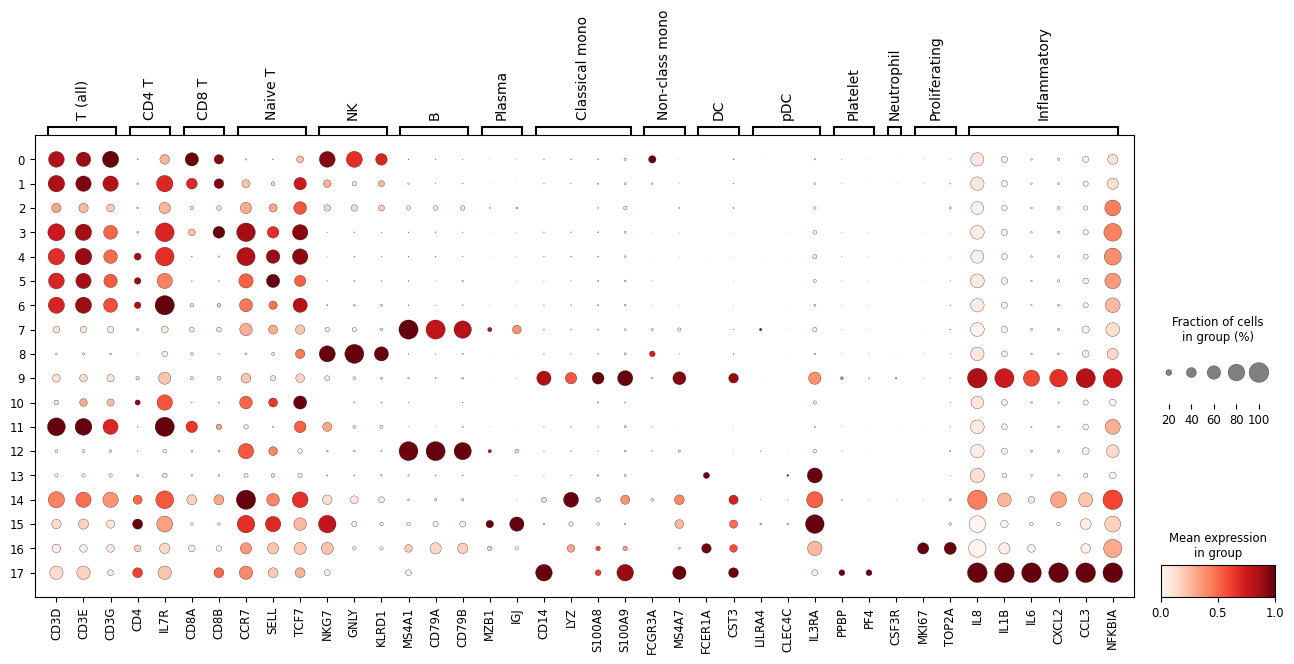

In [51]:
# Canonical PBMC markers, chosen before looking at the results. Alternatives are included
# where this dataset's pre-2017 symbols differ from current HGNC names (IGJ vs JCHAIN).
MARKER_PANEL = {
    'T (all)':        ['CD3D', 'CD3E', 'CD3G'],
    'CD4 T':          ['CD4', 'IL7R'],
    'CD8 T':          ['CD8A', 'CD8B'],
    'Naive T':        ['CCR7', 'SELL', 'TCF7'],
    'NK':             ['NKG7', 'GNLY', 'KLRD1'],
    'B':              ['MS4A1', 'CD79A', 'CD79B'],
    'Plasma':         ['MZB1', 'JCHAIN', 'IGJ'],
    'Classical mono': ['CD14', 'LYZ', 'S100A8', 'S100A9'],
    'Non-class mono': ['FCGR3A', 'MS4A7'],
    'DC':             ['FCER1A', 'CST3'],
    'pDC':            ['LILRA4', 'CLEC4C', 'IL3RA'],
    'Platelet':       ['PPBP', 'PF4'],
    'Neutrophil':     ['FCGR3B', 'CSF3R'],       # for the cluster 17 contaminant question
    'Proliferating':  ['MKI67', 'TOP2A'],
    'Inflammatory':   ['IL8', 'IL1B', 'IL6', 'CXCL2', 'CCL3', 'NFKBIA'],
}

present = {k: [g for g in v if g in adata.var_names] for k, v in MARKER_PANEL.items()}
missing = {k: [g for g in v if g not in adata.var_names] for k, v in MARKER_PANEL.items()}
present = {k: v for k, v in present.items() if v}

print('markers not found in this dataset (pre-2017 symbols - expected for some):')
for k, v in missing.items():
    if v:
        print(f'  {k:<16} {v}')
print(f'\nplotting {sum(len(v) for v in present.values())} markers '
      f'across {len(present)} populations')

sc.pl.dotplot(adata, present, groupby='leiden', layer='normlog',
              standard_scale='var', dendrogram=False, figsize=(16, 6))

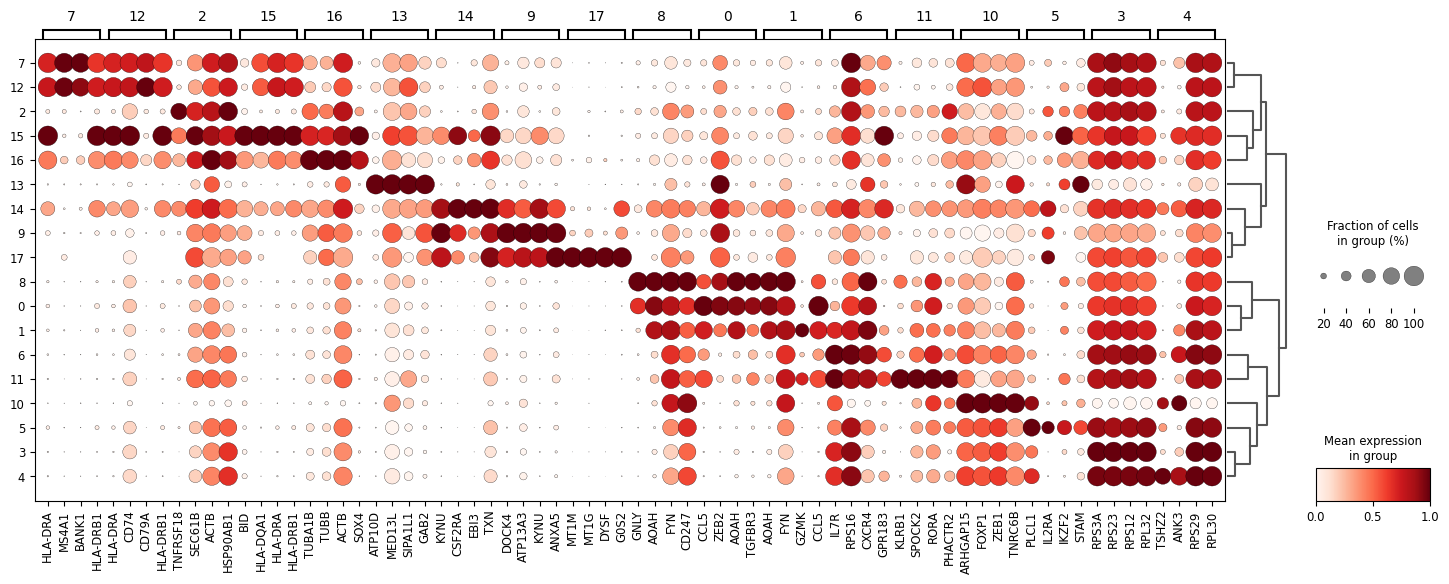

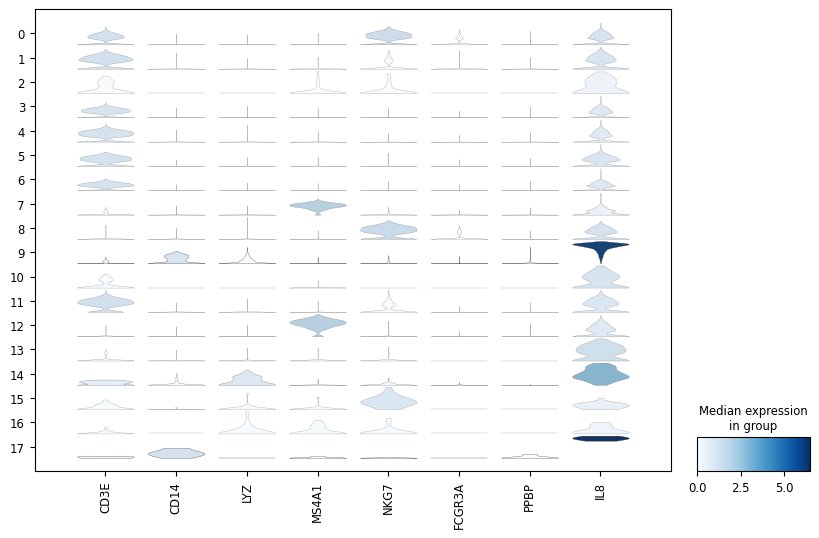

In [52]:
# What the data nominated, as opposed to what we asked about. Complements the curated
# panel above - discovery rather than verification.
sc.pl.rank_genes_groups_dotplot(adata, n_genes=4, key='rank_leiden', groupby='leiden',
                                layer='normlog', standard_scale='var', figsize=(18, 6))

# Per-cell distributions, reading the layer the axis claims. This replaces the reference
# notebook's hand-rolled boxplot, which read layers['counts'] while labelling the axis
# log1p. Distributions matter here because a bimodal cluster suggests a mixed population
# or doublets rather than one cell type.
LINEAGE = [g for g in ['CD3E', 'CD14', 'LYZ', 'MS4A1', 'NKG7', 'FCGR3A', 'PPBP', 'IL8']
           if g in adata.var_names]
sc.pl.stacked_violin(adata, LINEAGE, groupby='leiden', layer='normlog',
                     figsize=(10, 6), dendrogram=False)


### The four questions Section 9 handed to this section

Routine annotation is only part of the job. Section 9 produced specific open questions, and
the cell below addresses them directly rather than hoping they fall out of the dot plots.

1. **What is cluster 9?** 1,466 cells, enriched in 200nm (1.47×) against 40nm (0.56×), visually
   isolated on the UMAP. **This is the one that matters** — 1,466 cells can carry a Section 13
   pseudobulk test; five cells never can.
2. **What is cluster 17?** Five cells with an `IL6`/`IL1B`/`IL24`/`PLAUR` program and the two
   metallothioneins `MT1M`/`MT1G` at 100% against 1–2% elsewhere, present in every exposed
   sample and absent from control, with below-average mitochondrial content. Three competing
   explanations: activated monocytes (the interesting one), contaminating neutrophils
   (`FCGR3B`, `CSF3R` — these cytokines are also granulocyte genes), or doublets (which would
   show **two lineages' markers at once**, e.g. `CD3E` and `CD14` together).
3. **What are clusters 14, 15 and 16?** 188, 29 and 21 cells, each showing two lineages at
   once in the panel table. Cluster 14 is the pressing one: it held 17 cells before the
   Section 3 QC revision and 188 after, so it is exactly the shape of a problem that revision
   could have introduced. Answered by the doublet-score cell, not by argument.
4. **Do the RNA-rich UMAP regions carry coherent markers?** The test that decides whether the
   depth-position relationship seen in Section 9's QC plots is biology (monocytes are large
   and transcriptionally busy) or an artifact.

The doublet test is the important one and is worth stating precisely: a doublet cluster
expresses markers of **two distinct lineages in the same cells**. A genuinely activated
monocyte expresses monocyte markers plus an activation program — one lineage, one program.
The lineage-score table below separates those two possibilities, and the doublet scores from
Section 2 test it independently.

In [53]:
# Mean expression per cluster of each marker panel, on normlog.
LINEAGE_SETS = {k: v for k, v in present.items()
                if k in ('T (all)', 'B', 'NK', 'Classical mono', 'Non-class mono',
                         'pDC', 'Platelet', 'Neutrophil', 'Inflammatory')}

rows = {}
for cl in adata.obs['leiden'].cat.categories:
    m = (adata.obs['leiden'] == cl).to_numpy()
    rows[cl] = {name: float(np.asarray(adata[:, genes].layers['normlog'][m].mean()))
                for name, genes in LINEAGE_SETS.items()}
lineage = pd.DataFrame(rows).T
lineage.insert(0, 'cells', adata.obs['leiden'].value_counts().reindex(lineage.index).values)

pd.set_option('display.width', 200)
print('mean normlog expression per marker panel, by cluster')
print('read ACROSS a row: one panel should stand out near 1.0+ while the rest sit near 0\n')
print(lineage.round(2).to_string())

# NO automatic lineage verdict. Three attempts at one were written and all three failed,
# for reasons that are biological rather than fixable by tuning:
#   1. Scoring a panel against its cross-cluster AVERAGE makes abundant lineages invisible -
#      T cells span 8 of 18 clusters, so the T average is high and no T cluster clears it.
#   2. Ratios on near-zero panels are meaningless: the monocyte cluster scored "Neutrophil 11.3x" on
#      an absolute value of 0.01.
#   3. "Two panels elevated" is not a doublet. Classical and Non-classical monocyte are one
#      lineage; and cytotoxic T cells genuinely express the NK panel (NKG7, GNLY), so a
#      T+NK cluster is real biology, not a doublet.
# The dot plot above answers the question directly and is the intended instrument. What is
# printed below is the evidence, ranked - not a verdict.
lineage_only = [k for k in LINEAGE_SETS if k != 'Inflammatory']
infl_mean = lineage['Inflammatory'].mean() if 'Inflammatory' in lineage else None

print('\ntop marker panels per cluster, by ABSOLUTE mean expression\n')
for cl in lineage.index:
    top = lineage.loc[cl, lineage_only].sort_values(ascending=False)
    detail = ', '.join(f'{k} {v:.2f}' for k, v in top.head(3).items())
    line = f'cluster {cl:>2} ({int(lineage.loc[cl, "cells"]):>6,} cells): {detail}'
    if infl_mean is not None:
        line += f'   | inflammatory {lineage.loc[cl, "Inflammatory"]:.2f}'
    print(line)

if infl_mean is not None:
    print(f'\ninflammatory panel: dataset mean across clusters {infl_mean:.2f}; '
          f'highest are '
          + ', '.join(f'cluster {c} ({v:.2f})' for c, v
                      in lineage['Inflammatory'].nlargest(3).items()))

mean normlog expression per marker panel, by cluster
read ACROSS a row: one panel should stand out near 1.0+ while the rest sit near 0

    cells  T (all)    NK     B  Classical mono  Non-class mono   pDC  Platelet  Neutrophil  Inflammatory
0    3995     1.33  1.45  0.01            0.04            0.20  0.01      0.01        0.00          0.41
1    1789     1.27  0.36  0.02            0.03            0.03  0.02      0.00        0.00          0.39
2      48     0.42  0.31  0.15            0.04            0.00  0.01      0.00        0.00          0.41
3    7371     1.04  0.01  0.01            0.03            0.00  0.04      0.00        0.00          0.47
4    5209     1.00  0.01  0.01            0.02            0.00  0.04      0.00        0.00          0.43
5     917     1.03  0.02  0.02            0.03            0.00  0.03      0.01        0.00          0.48
6    3077     1.06  0.06  0.01            0.03            0.00  0.02      0.01        0.00          0.40
7    1065     0.18  0.08

### Stage two — from cluster numbers to cell type names

The dot plot answered most clusters unambiguously. Two questions are not settled by looking
harder at dots:

- **clusters 3 and 4** — both naive T (`CCR7`, `SELL`, `TCF7`), but CD4 vs CD8 rests on `CD8B`
  in one row and a near-empty `CD4` column in the other. `CD4` mRNA is poorly captured in 10x
  data, so "CD4 T cell" is normally called by *absence* of CD8, not presence of CD4.
- **cluster 10** — 130 cells, called T by the inherited labels, but its top genes
  (`ARHGAP15` 99/88, `FOXP1` 100/91) are expressed almost as widely outside the cluster as
  inside. No subset marker was nominated at all.

`standard_scale='var'` in the dot plot rescales every gene to 0-1 across clusters, so a gene
that is faint everywhere still produces one dark dot. The check below reads **unscaled**
values and reports the plain fraction of cells expressing each gene.

The second check is independent of our markers: the `.h5ad` files arrived with cell type
labels already attached, carried forward by Section 1 as `predicted.celltype`. Read them as a
second opinion, not as an answer key — their vocabulary has six categories and splits T cells
by **function** (`CD4+ T cell` vs `Cytotoxic T cell`) rather than by lineage, so a naive CD8
T cell, which is not yet cytotoxic, has nowhere to go but the CD4 box. Where the two schemes
can express the same thing they agree; where they cannot, the disagreement is about the
category list, not about the cells.

In [54]:
# standard_scale='var' rescales each gene to 0-1, which is why a faint gene can show a dark
# dot. These are raw fractions - no scaling, no ranking.
CHECK = ['CD3E', 'CD4', 'IL7R', 'CD8A', 'CD8B', 'CCR7', 'SELL', 'KLRB1', 'SLC4A10',
         'FOXP3', 'IL2RA', 'TRDC', 'TRGC1', 'NKG7', 'FCGR3A', 'MS4A1', 'IGHD', 'CD27']
found = [g for g in CHECK if g in adata.var_names]
print('not in this dataset:', [g for g in CHECK if g not in adata.var_names] or 'none')

df = sc.get.obs_df(adata, keys=found + ['leiden'], layer='normlog')
pct = df.groupby('leiden', observed=True).agg(lambda s: 100 * (s > 0).mean()).round().astype(int)
print()
print('% of cells expressing, per cluster (unscaled)')
print(pct.to_string())

# Independent of our markers entirely: the Azimuth PBMC labels that shipped with the files.
ct = 100 * pd.crosstab(adata.obs['leiden'], adata.obs['predicted.celltype'], normalize='index')
print()
print('inherited Azimuth labels, top 3 per cluster')
for cl in ct.index:
    top = ct.loc[cl].sort_values(ascending=False).head(3)
    print(f'cluster {cl:>2}: ' + ', '.join(f'{k} {v:.0f}%' for k, v in top.items() if v >= 1))

not in this dataset: ['TRDC', 'TRGC1', 'IGHD']

% of cells expressing, per cluster (unscaled)
        CD3E  CD4  IL7R  CD8A  CD8B  CCR7  SELL  KLRB1  SLC4A10  FOXP3  IL2RA  NKG7  FCGR3A  MS4A1  CD27
leiden                                                                                                  
0         67    2    39    59    38     3     2     19        0      0      1    75      27      1     1
1         72    4    79    45    39    31    11     19        1      0      1    28       4      3    16
2         38    4    48    10    15    48    31     46        4      2     44    23       0     12    17
3         78    4    94    24    51    93    50      1        0      0      1     1       0      1    15
4         80   25    93     2     3    90    61      6        0      1      3     0       0      1    15
5         72   23    71     1     2    65    59      4        0     33     55     1       1      2    19
6         77   24    98    10    11    58    32     27        3   

In [55]:
# Clusters 14, 15 and 16 show two lineages at once in the panel table, and 14 grew from 17
# cells to 188 when Section 3's upper depth bound was removed. That is the shape of a problem
# the revision could have introduced, so test it instead of arguing about it: Scrublet's
# per-cell score is already in obs from Section 2, computed before any of this.
cut = adata.obs['doublet_score'].quantile(0.90)
dbl = adata.obs.groupby('leiden', observed=True).agg(
    cells=('doublet_score', 'size'),
    median_score=('doublet_score', 'median'),
    pct_in_top_decile=('doublet_score', lambda s: 100 * (s > cut).mean()),
    median_counts=('total_counts', 'median'))
dbl['pct_in_top_decile'] = dbl['pct_in_top_decile'].round(0)
print(f'dataset median doublet score {adata.obs["doublet_score"].median():.3f}, '
      f'90th percentile {cut:.3f}')
print('a real doublet cluster sits high on BOTH score columns, not just on depth')
print()
print(dbl.round(3).to_string())

dataset median doublet score 0.072, 90th percentile 0.164
a real doublet cluster sits high on BOTH score columns, not just on depth

        cells  median_score  pct_in_top_decile  median_counts
leiden                                                       
0        3995         0.046                3.0         3743.0
1        1789         0.075               10.0         4115.0
2          48         0.119               17.0         7498.5
3        7371         0.080                9.0         6172.0
4        5209         0.092               13.0         6420.0
5         917         0.071               10.0         4980.0
6        3077         0.078               13.0         5503.0
7        1065         0.052               10.0         9484.0
8        1589         0.036                4.0         3584.0
9        1466         0.125               21.0        12861.5
10        130         0.038                2.0         3341.0
11        890         0.038                6.0         5359.0

### Sub-clustering two clusters, for two specific questions

Resolution 0.4 is a global setting and it answered most of the dataset well. Two questions
need finer granularity, and both are confined to a single cluster:

**Is cluster 3 purely naive CD8?** `CD8B` reads 51% and `CD4` 4%, so it is CD8-dominant — a
50/50 mixture would put `CD4` near 12%, since cluster 4 reads 25%. But roughly 15% CD4 would
fit the numbers, and that matters: the labels currently make the dataset CD8-heavy, while the
CD4:CD8 ratio in blood usually runs the other way.

**Two things to hold in mind while reading the result.** The 2:1 CD4:CD8 figure comes from
flow cytometry, which measures surface *protein*; `CD4` mRNA is poorly captured, so
transcriptomic annotation of PBMCs routinely lands nearer 1:1. And detection is asymmetric —
`CD4` is detected in 25% of cells in the cluster we are confident is CD4, while `CD8A` or
`CD8B` is detected in about 55% of the CD8 cluster. Correcting the naive compartment for that
gives roughly 47% CD4 / 53% CD8 rather than the 2.5x CD8 excess the raw labels imply. **The
skew is in how ambiguous cells get assigned, not in the pipeline**: measured on the inherited
labels, the CD4:Cytotoxic ratio is 3.04 before any of our processing and 2.98 after it.

**Does cluster 9 split into classical and non-classical monocytes?** `CLAUDE.md` Task 3 asks
for that split specifically, and resolution 0.4 did not produce it — the cluster carries the
classical panel at 1.16 and the non-classical panel at 0.29 together.

`restrict_to` re-runs Leiden **inside one cluster only**, so `obs['leiden']` and everything
built on it stay exactly as they are. The result goes to a new column, and a split is adopted
only if the sub-clusters carry distinct, coherent markers — not merely because Leiden returned
more than one group, which it will do on noise if asked.

In [60]:
# Two questions need finer granularity than resolution 0.4 delivered, and both are local:
# whether cluster 3 (naive T) contains a naive CD4 minority that the CD8 majority absorbed,
# and whether cluster 9 (monocytes) splits into classical and non-classical, which Task 3
# asks for explicitly. restrict_to re-runs Leiden inside one cluster only, so the global
# partition every other section depends on is untouched.
SUBCLUSTER = {
    '3': ['CD4', 'CD8A', 'CD8B', 'MAL', 'LEF1', 'TRABD2A', 'S100B', 'RGS10', 'CCR7'],
    '9': ['CD14', 'LYZ', 'S100A8', 'FCGR3A', 'MS4A7', 'CDKN1C', 'CST3', 'IL8'],
}
SUB_RES = 0.3

for parent, panel in SUBCLUSTER.items():
    key = f'sub_{parent}'
    sc.tl.leiden(adata, restrict_to=('leiden', [parent]), resolution=SUB_RES, key_added=key,
                 flavor='igraph', n_iterations=2, directed=False, random_state=0)
    part = adata[adata.obs['leiden'] == parent].copy()
    genes = [g for g in panel if g in adata.var_names]
    df = sc.get.obs_df(part, keys=genes + [key], layer='normlog')
    pct = df.groupby(key, observed=True).agg(lambda s: 100 * (s > 0).mean()).round(0).astype(int)
    pct.insert(0, 'cells', df.groupby(key, observed=True).size())
    print(f'cluster {parent} -> {len(pct)} sub-clusters at resolution {SUB_RES}')
    print('% of cells expressing')
    print(pct.to_string())
    print()

cluster 3 -> 3 sub-clusters at resolution 0.3
% of cells expressing
       cells  CD4  CD8A  CD8B  MAL  LEF1  TRABD2A  S100B  RGS10  CCR7
sub_3                                                                
3,0     2144    5    22    48   42    92       21      4     77    93
3,1     1773    2    39    72   56    95       31     10     82    97
3,2     3454    5    19    41   42    76       15      5     69    91

cluster 9 -> 14 sub-clusters at resolution 0.3
% of cells expressing
       cells  CD14  LYZ  S100A8  FCGR3A  MS4A7  CDKN1C  CST3  IL8
sub_9                                                            
9,0      226    66   65      68       6     68       7    45  100
9,1       10    80   20      50       0     80       0    30  100
9,2       64    97   66      75       3     58       2    33  100
9,3        7    86   29      29       0     43       0     0  100
9,4      275    82   75      76       3     66       8    51  100
9,5       99    33   12       9       1     26    

### What the sub-clustering showed — two negative results, one of them weak

**Cluster 3 does not contain a hidden naive CD4 population.** It split into three groups of
2,144 / 1,773 / 3,454 cells, and all three read `CD4` at 2–5% with `CD8B` at 41–72%. They
differ in *degree* of CD8 detection, not in identity, and no sub-cluster leans CD4 on the
independent markers either. The `CD8 T naive` label stands.

**But this test is weak for this particular question, and that has to be said.** Section 6
recorded which marker genes made the 3,000-HVG set: `MS4A1`, `CD14`, `LYZ`, `NKG7`, `GNLY`,
`FCER1A`, `PPBP`, `LILRA4` were flagged — **`CD3E`, `CD8A`, `IL7R` and `FCGR3A` were not.**
The neighbour graph is built from HVGs, so the CD4/CD8 distinction contributes almost nothing
to the geometry Leiden partitions. Sub-clustering can only find splits that exist in that
graph, so "no CD4 sub-cluster" is much weaker evidence than "no monocyte sub-cluster" would
be for a gene like `CD14`, which *is* an HVG.

What can be said with the evidence available: the naive compartment is roughly balanced once
detection sensitivity is accounted for (~47% CD4 / 53% CD8), our cluster-level labels assign
it CD8-heavy, and `CD4` dropout is the reason those two statements differ. That belongs in
the report as a stated limitation, not as a resolved number.

**Cluster 9 does not split into classical and non-classical monocytes, and here the negative
result is solid.** It returned 14 sub-clusters — over-splitting on a gradient, since every one
of them reads `CD14`+ / `S100A8`+ / `FCGR3A`− and `IL8` at 99–100%. `FCGR3A` reaches 6% in
one sub-cluster and 0–3% in the rest.

The clustering-independent check agrees: across all 29,157 cells `FCGR3A` is detected in 5.6%
but only **20 cells carry 5 or more counts**, and most of that signal sits in NK cells, which
also express CD16. **Non-classical (CD16⁺) monocytes are essentially absent from this
dataset.** `CLAUDE.md` Task 3 asks for the split; the honest answer is that the population is
not there to split, which is reported rather than forced by raising the resolution until two
groups appear.

**Neither split is adopted.** `obs['leiden']` and the cell type labels are unchanged; the
`sub_3` and `sub_9` columns stay in `obs` as evidence.

In [101]:
# Task 3 deliverable: the cluster -> cell type map. Sections 12 (composition) and 13 (DE)
# group by this column, so a guess written here stops looking like a guess two sections later.
# Clusters 14, 15 and 16 are labelled Doublet on the evidence of the cell above: Scrublet
# scores ~2x the dataset median, 34-52% of their cells in the top decile of scores, and
# median depth 4-6x the dataset. Section 2 thresholded at 50% sensitivity by design, so
# roughly half the doublets were always going to reach this point; until the Section 3
# revision they were being removed incidentally by the upper depth bound, together with
# 309 real monocytes. Clusters 2, 10 and 17 are unresolved for the opposite reason -
# ordinary doublet scores, but no marker of their own, or too few cells to name.
#
# These IDs belong to one specific clustering run. Leiden numbering is not stable across
# re-runs, so after any change upstream of Section 9 the mapping must be re-derived from the
# dot plot, not reused.
CELL_TYPES = {
    '0':  'CD8 T effector',
    '1':  'CD8 T effector memory',
    '2':  'Unresolved (stress program)',
    '3':  'T naive (CD4/CD8 unresolved)',
    '4':  'CD4 T naive',
    '5':  'Treg',
    '6':  'CD4 T memory',
    '7':  'B memory',
    '8':  'NK',
    '9':  'Monocyte',
    '10': 'T unresolved',
    '11': 'MAIT',
    '12': 'B naive',
    '13': 'Basophil',
    '14': 'Doublet',
    '15': 'Doublet',
    '16': 'Doublet',
    '17': 'Myeloid unresolved',
}
assert set(CELL_TYPES) == set(adata.obs['leiden'].cat.categories), 'cluster labels do not match'
adata.obs['cell_type'] = adata.obs['leiden'].map(CELL_TYPES).astype('category')

# The assert above only catches a changed cluster COUNT. This catches the worse case, where
# the count matches but the IDs have moved: CD14 must be most widely expressed in the
# population we called Monocyte. Restricted to types big enough for the fraction to be
# stable - a 5-cell cluster can hit 100% on noise.
cd14 = sc.get.obs_df(adata, keys=['CD14', 'cell_type'], layer='normlog')
frac = cd14.groupby('cell_type', observed=True)['CD14'].agg(['size', lambda s: (s > 0).mean()])
frac.columns = ['cells', 'pct_cd14']
big = frac[frac.cells >= 200]
assert not big.empty, 'no cell type has 200+ cells - the sentinel cannot run'
assert big.pct_cd14.idxmax() == 'Monocyte',     f'labels look misaligned: CD14 is highest in {big.pct_cd14.idxmax()}, not Monocyte'

# A second, coarser label for Section 13. Pseudobulk sums each cell type's counts into one
# column per sample, so every group needs enough cells in EVERY sample - and control, the
# smallest, is always the binding constraint. The rule applied here: merge only where a group
# cannot support a test alone, or where no mechanism would make the split respond differently.
# Resolution is protected where CLAUDE.md expects the effect and spent where it does not.
#
#   Monocyte stays alone            - CLAUDE.md expects the response in phagocytic myeloid
#                                     cells; 228 control cells is enough to test.
#   Basophil stays alone            - a granulocyte, not a phagocyte; merging it into
#                                     Monocyte would put a different lineage into the myeloid
#                                     pseudobulk. It fails the size check below and is
#                                     excluded from DE, but stays intact for Task 4.
#   CD4 / CD8 / B subsets merge     - no expected effect there, and each merge is one fewer
#                                     test on a single-donor dataset where every test is
#                                     already exploratory.
#   T naive is its own group        - cluster 3 is a naive T mixture whose CD4/CD8 split no
#                                     method could resolve (Section 11). Labelling it either
#                                     way would assert what the data cannot support, so it
#                                     stays whole and testable as naive T.
#   Treg and MAIT stay alone        - distinct lineages/functions, and both clear the check.
#   Artifacts and unnamed -> Exclude - so they are dropped rather than silently summed into a
#                                     real cell type, which is what happens by default.
COARSE = {
    'T naive (CD4/CD8 unresolved)': 'T naive',
    'CD4 T naive':                 'CD4 T',
    'CD4 T memory':                'CD4 T',
    'Treg':                        'Treg',
    'CD8 T effector':              'CD8 T',
    'CD8 T effector memory':       'CD8 T',
    'MAIT':                        'MAIT',
    'NK':                          'NK',
    'B naive':                     'B',
    'B memory':                    'B',
    'Monocyte':                    'Monocyte',
    'Basophil':                    'Basophil',
    'Doublet':                     'Exclude',
    'T unresolved':                'Exclude',
    'Myeloid unresolved':          'Exclude',
    'Unresolved (stress program)': 'Exclude',
}
missing = set(adata.obs['cell_type'].cat.categories) - set(COARSE)
assert not missing, f'COARSE does not cover: {missing}'
adata.obs['cell_type_coarse'] = adata.obs['cell_type'].map(COARSE).astype('category')

# NOTE: which coarse groups can carry a Section 13 test is decided at the END of Section 11,
# not here. Cluster 3 is relabelled per cell there, which moves ~2,800 cells between CD4 T and
# CD8 T - a readiness table computed now would describe labels that are about to change.

print(adata.obs.groupby(['cell_type', 'Sample'], observed=True).size().unstack(fill_value=0))
print()
n_dbl = (adata.obs['cell_type'] == 'Doublet').sum()
print(f'doublets identified at cluster level: {n_dbl:,} cells '
      f'({n_dbl / adata.n_obs:.1%}) - to be excluded in Sections 12-13')

Sample                        40nm  200nm  control  mixture
cell_type                                                  
B memory                       187    338      254      286
B naive                        246    453      229      283
Basophil                        43     62       15       37
CD4 T memory                   821   1139      560      557
CD4 T naive                   1328   1787     1189      905
CD8 T effector                 972   1402      848      773
CD8 T effector memory          396    696      334      363
Doublet                         24    131       57       26
MAIT                           201    357      163      169
Monocyte                       207    803      228      228
Myeloid unresolved               1      3        0        1
NK                             401    538      336      314
T naive (CD4/CD8 unresolved)  2235   2751     1268     1117
T unresolved                    41     41       12       36
Treg                           264    35

### Why each cluster got its name

One line per cluster. The rule throughout: a cell type is called by a gene that this type
makes and other types do not. Percentages are the fraction of cells in the cluster carrying
the gene, from the unscaled table above.

| # | cells | name | why |
|---|---|---|---|
| 0 | 3,995 | CD8 T effector | Has the T cell gene `CD3E` (67%), the CD8 gene (59%), and killing granules `NKG7` (75%), `GNLY`. A killer T cell. |
| 1 | 1,789 | CD8 T effector memory | Same T and CD8 genes, plus `GZMK` at 61% against 6% elsewhere — a gene of killer T cells that have met their target before. |
| 2 | 48 | **Unresolved (stress program)** | Top genes are `HSP90AB1`, `UBB`, `GAPDH`, `ACTB` — heat-shock and housekeeping, not identity. No lineage panel above 0.42. Cells under stress, of unknown type. |
| 3 | 7,371 | **T naive (CD4/CD8 unresolved)** | `CCR7` 93% makes the whole cluster naive T. It is a **mixture** — `CD8B` in 51% against 3% in cluster 4 — but no method could say which cells are which: CellTypist called it 62/38 CD8/CD4 per cell, Pan-Human Azimuth called it 88% CD4, and the two agreed on individual cells only 45.7% of the time against ~50% by chance. Labelling it either way would assert what the data cannot support. |
| 4 | 5,209 | CD4 T naive | The mirror of cluster 3: `CD4` 25%, both CD8 genes at 2–3%, `CCR7` 90%. |
| 5 | 917 | Treg | `FOXP3` 33% against 0–1% everywhere else, with `IL2RA` 55%. Only regulatory T cells make `FOXP3`. |
| 6 | 3,077 | CD4 T memory | `CD4` 24%, `IL7R` 98%, no CD8, and only half carry the naive genes. |
| 7 | 1,065 | B memory | The B cell gene `MS4A1` in 97%, plus `CD27` at 42% — the memory B marker. |
| 8 | 1,589 | NK | Killing genes high (`NKG7` 76%), the T cell gene in **5%** of cells. Not a T cell. |
| 9 | 1,466 | Monocyte | Classical monocyte panel 1.16 against under 0.30 for every other panel. `KYNU` and `DOCK4` at 99–100% against 5%. The only monocytes in the data. |
| 10 | 130 | **T unresolved** | T-ish but nothing distinguishes it: top genes `ARHGAP15` 99/88, `FOXP1` 100/91 — as common outside the cluster as inside. |
| 11 | 890 | MAIT | `SLC4A10` 64% against 0–10% elsewhere, `KLRB1` 96%. `SLC4A10` is essentially MAIT-only. |
| 12 | 1,211 | B naive | B cell genes as in cluster 7, but `CD27` at 3%. B cells that have not been activated. |
| 13 | 157 | **Basophil** | `HDC` 56%, `CPA3` 33%, `CLC` 30%, `GATA2` 13% — the basophil program. `CD1C` 0% rules out cDC2 and `LILRA4` 0% rules out pDC. Originally called a dendritic cell; see the correction below. |
| 14 | 188 | **Doublet** | Looked like a mature-DC program (`EBI3` 95/5, `CCR7` 97%) but carries `CD3E` at 71% as well. Doublet score 0.147 against a dataset median of 0.072, 36% of cells in the top score decile, median depth 22,927 against 5,541. |
| 15 | 29 | **Doublet** | MHC-II high (`HLA-DQA1` 100/9) *and* `NKG7` 86%. NK cells do not present antigen. Doublet score 0.145, 34% in the top decile, median depth 23,853. |
| 16 | 21 | **Doublet** | No lineage panel above 0.38. The clearest case: doublet score 0.169, **52%** of cells in the top decile, median depth 31,762 — nearly six times the dataset median. |
| 17 | 5 | **Myeloid unresolved** | Monocyte panel 0.92 and the highest inflammatory score in the data (4.32), with `MT1M`/`MT1G` at 100% against 1–2%. Five cells is too few to name. |

### Doublets, and what is actually unresolved

Clusters 14, 15 and 16 — **238 cells, 0.8%** — are doublets. They sit high on **both**
diagnostic axes: doublet score around twice the dataset median with a third to a half of
their cells in the top score decile, *and* four to six times the median sequencing depth.
A large real cell type is high on depth alone: cluster 9 (monocytes) has a median of 12,861
counts but only 21% of its cells in the top score decile.

Section 2 removed 2,239 doublets at a deliberate 50% sensitivity, so roughly half were always
going to survive to here; Scrublet also cannot see two cells of the *same* type in one
droplet. Until the Section 3 revision the leftovers were being removed incidentally by the
upper depth bound — the same cut that removed 309 real monocytes. Identifying them as
clusters removes them precisely instead, which is why cluster-level doublet calls are
standard practice: doublets share a mixed profile and therefore cluster together, whereas a
per-cell threshold has to cut through two overlapping distributions.

**What is genuinely unresolved is 183 cells, 0.6%** — clusters 2 (48), 10 (130) and 17 (5).
All three have ordinary doublet scores. They are unnamed because no marker distinguishes
them, not because they are artifacts.

**Not present in this dataset:** platelets (`PPBP` in 257 cells, only 41 with 5+ counts),
neutrophils, plasma cells, proliferating cells, **and dendritic cells of either kind** —
`CD1C` reaches 0-5% in every cluster and `LILRA4` never exceeds 6%. Empty marker columns are
informative and, apart from the DCs, normal for PBMCs.

**The dendritic-cell error is worth keeping visible.** Cluster 13 scored 0.47 on the pDC
panel, which looked like evidence. That panel averages `LILRA4`, `CLEC4C` and `IL3RA` — and
the score came almost entirely from `IL3RA` at 70%, with `LILRA4` at 0% and `CLEC4C` at 4%.
`IL3RA` is CD123, carried by basophils as well as pDCs. **A panel mean can be driven by one
gene, and averaging hid which one.** The per-gene table is what caught it.

**Two metallothioneins at the top of cluster 17 are worth flagging.** `MT1M` and `MT1G` are
metal-binding stress-response genes, and this is a metal-free polystyrene experiment — but
they also respond to oxidative stress and zinc redistribution during inflammation. With five
cells this is an observation to carry forward, not a finding.

### Checking against the two labellings that came with the data

The files arrived with cell type labels already attached, produced by two different automatic
methods before we saw the data:

- **Azimuth** — reference-based label transfer, kept in `obs['predicted.celltype']` by Section 1.
- **CoDi** — the `*_CoDi_KLD.csv` files, one label and a confidence per cell barcode.

Neither is ground truth. Nobody sorted these cells with antibodies and wrote down the answer;
both are automatic interpretations of the same gene expression we are reading ourselves. So
the right question is not "do we match them" but **"where do the three disagree, and which
reading do the genes support"**.

The first test is therefore not against us at all — **do the two external methods agree with
each other?** If two expert-produced labellings of the same cells disagree, neither can be
treated as the correct answer, and a disagreement with ours stops being evidence that we are
wrong.

The second test is the composition each method reports. Published PBMC composition is roughly
25-35% CD4 T, 15-25% CD8 T, 5-15% NK, 5-15% B and 10-30% monocyte. A method whose totals are
far from that is not a reference to defer to, whatever it says about any one cluster.

In [102]:
# A third opinion, and a check of the two external ones against each other. CoDi shipped
# with the data as per-cell CSVs; Section 1 kept the Azimuth labels in obs. Barcodes were
# prefixed per sample in Section 1, so rebuild the same key here.
codi = pd.concat([
    pd.read_csv(DATA_DIR / f"{fn.replace('.h5ad', '')}_CoDi_KLD.csv").assign(Sample=label)
    for label, fn in SAMPLES.items()
])
codi.index = codi['Sample'] + '_' + codi['cell_id']
adata.obs['CoDi'] = codi['CoDi'].reindex(adata.obs_names).values
print(f"CoDi labels matched: {adata.obs['CoDi'].notna().sum():,} of {adata.n_obs:,} cells")

# What each method says the dataset is made of. Published PBMC composition is roughly
# 25-35% CD4 T, 15-25% CD8 T, 5-15% NK, 5-15% B, 10-30% monocyte - a useful sanity check,
# since a method that returns implausible proportions is not a reference to defer to.
share = pd.concat([
    adata.obs['predicted.celltype'].value_counts(normalize=True).rename('Azimuth'),
    adata.obs['CoDi'].value_counts(normalize=True).rename('CoDi'),
    adata.obs['cell_type'].value_counts(normalize=True).rename('ours'),
], axis=1).mul(100).round(1)
print('\n% of all cells, by method (NaN = that method has no such label)')
print(share.to_string())

# Do the two external methods agree with EACH OTHER? If not, neither is ground truth.
both = adata.obs[['predicted.celltype', 'CoDi']].dropna()
print(f"\nAzimuth vs CoDi agree on {100 * (both['predicted.celltype'] == both['CoDi']).mean():.1f}%"
      f" of {len(both):,} cells")
print(pd.crosstab(both['predicted.celltype'], both['CoDi']).to_string())

print('\nper cluster - our call, then what each external method calls the same cells')
for cl in adata.obs['leiden'].cat.categories:
    m = adata.obs['leiden'] == cl
    az = adata.obs.loc[m, 'predicted.celltype'].value_counts(normalize=True)
    cd = adata.obs.loc[m, 'CoDi'].value_counts(normalize=True)
    print(f'cluster {cl:>2} ({m.sum():>6,})  {CELL_TYPES[cl]:<22}'
          f'Azimuth: {az.index[0]} {100 * az.iloc[0]:.0f}%   '
          f'CoDi: {cd.index[0]} {100 * cd.iloc[0]:.0f}%')

CoDi labels matched: 29,157 of 29,157 cells

% of all cells, by method (NaN = that method has no such label)
                              Azimuth  CoDi  ours
CD4+ T cell                      65.3  66.8   NaN
Cytotoxic T cell                 21.9  19.6   NaN
B cell                            7.3   7.6   NaN
CD14+ monocyte                    5.5   5.0   NaN
Natural killer cell               0.0   0.7   NaN
Dendritic cell                    0.0   0.1   NaN
Megakaryocyte                     0.0   NaN   NaN
Plasmacytoid dendritic cell       0.0   0.0   NaN
CD16+ monocyte                    NaN   0.1   NaN
T naive (CD4/CD8 unresolved)      NaN   NaN  25.3
CD4 T naive                       NaN   NaN  17.9
CD8 T effector                    NaN   NaN  13.7
CD4 T memory                      NaN   NaN  10.6
CD8 T effector memory             NaN   NaN   6.1
NK                                NaN   NaN   5.4
Monocyte                          NaN   NaN   5.0
B naive                           NaN   N

---

## Section 11 — Automated annotation, run by us

**`CLAUDE.md` Task 3** (cell type annotation) — the reference-based half, done in Python

Section 10 named clusters from marker genes we chose. This section asks a trained model the
same question, so the annotation rests on two methods that fail in different ways rather than
on one. `CLAUDE.md` names Azimuth for this; Azimuth is R/Seurat, so the Python equivalents are
used and the inherited labels already in `obs` serve as the third opinion.

**CellTypist first**, because it answers something Section 10 could not.

`Immune_All_Low` is a logistic-regression model over the full gene set, trained on 98 immune
subtypes. Two properties matter here:

1. **It is per-cell.** Leiden partitions a neighbour graph built from 3,000 HVGs, and Section
   6 recorded that `CD3E`, `CD8A`, `IL7R` and `FCGR3A` are *not* among them. That is why
   sub-clustering cluster 3 could not test whether it hides naive CD4 cells — the genes that
   would separate them barely influence the geometry. CellTypist reads `CD4` and `CD8A/B`
   directly and does not use our graph, so **its spread within cluster 3 is an independent
   answer to the question we could not settle.**
2. **`majority_voting=True` with `over_clustering='leiden'`** also returns one label per
   *our* cluster, which is the like-for-like comparison against Section 10.

Both columns are kept: `celltypist` (per cell) and `celltypist_cluster` (majority vote).

### The check that has to come first

The models ship **current HGNC symbols**; this dataset uses pre-2017 ones (`IL8`, not
`CXCL8`). Every unmatched gene is silently treated as zero, which degrades predictions
without any warning. So the feature overlap is measured and printed before any label is read,
along with whether the specific genes this section depends on are present in both.

`target_sum=1e4` in Section 5 was chosen for this step — CellTypist requires log1p of counts
normalized to exactly 1e4, not scanpy's default of the median library size. The cell asserts
`.X` is still the unscaled log-normalized matrix rather than trusting it.

In [103]:
import celltypist
from celltypist import models

# Immune_All_Low: 98 immune subtypes. The High model has 32 and stops around "T cell", which
# cannot address the open CD4/CD8 question; Low names naive CD4 and naive CD8 separately.
MODEL = 'Immune_All_Low.pkl'
models.download_models(model=[MODEL])            # cached after the first run
model = models.Model.load(model=MODEL)

# CellTypist requires log1p of counts normalized to 1e4 - the reason Section 5 fixed
# target_sum=1e4 rather than taking scanpy's default of the median library size.
assert np.array_equal(adata.X.data, adata.layers['normlog'].data), '.X is not normlog'

# The legacy-symbol problem, made visible BEFORE any label is trusted: CellTypist ships
# current HGNC symbols and this dataset uses pre-2017 ones. A poor overlap degrades every
# prediction silently, so it is measured rather than assumed.
matched = set(model.features) & set(adata.var_names)
print(f'model features matched: {len(matched):,} of {len(model.features):,} '
      f'({len(matched) / len(model.features):.1%})')
print('genes this section depends on:')
for g in ['CD4', 'CD8A', 'CD8B', 'CCR7', 'SELL', 'S100B', 'MAL', 'IL8', 'CXCL8']:
    print(f'  {g:<8}{"model" if g in model.features else "-":<8}'
          f'{"data" if g in adata.var_names else "-"}')

pred = celltypist.annotate(adata, model=MODEL, majority_voting=True, over_clustering='leiden')
adata.obs['celltypist'] = pred.predicted_labels['predicted_labels'].astype('category')
adata.obs['celltypist_cluster'] = pred.predicted_labels['majority_voting'].astype('category')
print()
print(f"per-cell labels used: {adata.obs['celltypist'].nunique()}   "
      f"after majority voting over our leiden clusters: "
      f"{adata.obs['celltypist_cluster'].nunique()}")

📂 Storing models in C:\Users\sofij\.celltypist\data\models
💾 Total models to download: 1
⏩ Skipping [1/1]: Immune_All_Low.pkl (file exists)
🔬 Input data has 29157 cells and 20387 genes
🔗 Matching reference genes in the model


model features matched: 4,757 of 6,639 (71.7%)
genes this section depends on:
  CD4     model   data
  CD8A    model   data
  CD8B    model   data
  CCR7    model   data
  SELL    model   data
  S100B   model   data
  MAL     model   data
  IL8     -       data
  CXCL8   model   -


🧬 4757 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
🗳️ Majority voting the predictions
✅ Majority voting done!



per-cell labels used: 74   after majority voting over our leiden clusters: 15


In [104]:
# Per cluster: our label, CellTypist's majority-vote label, and its top per-cell labels.
# The per-cell column is the one that can disagree WITHIN a cluster.
print('cluster (cells)   ours / CellTypist majority / CellTypist per-cell')
for cl in adata.obs['leiden'].cat.categories:
    m = (adata.obs['leiden'] == cl).to_numpy()
    share = adata.obs.loc[m, 'celltypist'].value_counts(normalize=True)
    top = ', '.join(f'{k} {100 * v:.0f}%' for k, v in share.head(2).items() if v >= 0.05)
    print(f'{cl:>3} ({m.sum():>6,})  {CELL_TYPES[cl]:<28}'
          f'{str(adata.obs.loc[m, "celltypist_cluster"].iloc[0]):<30}{top}')

# The question Section 10 could not answer. Leiden partitions a graph built from HVGs, and
# CD4/CD8A are not HVGs, so sub-clustering cluster 3 could not test whether it holds naive
# CD4 cells. CellTypist is a per-cell logistic model over the full gene set and does not use
# our graph at all, so its within-cluster spread is an independent answer.
for cl in ['3', '4']:
    m = (adata.obs['leiden'] == cl).to_numpy()
    print()
    print(f'cluster {cl} ({m.sum():,} cells) - CellTypist per-cell labels')
    counts = adata.obs.loc[m, 'celltypist'].value_counts().head(6)
    for k, v in counts.items():
        print(f'  {k:<40}{v:>6,}  {100 * v / m.sum():>5.1f}%')

cluster (cells)   ours / CellTypist majority / CellTypist per-cell
  0 ( 3,995)  CD8 T effector              Tem/Temra cytotoxic T cells   Tem/Temra cytotoxic T cells 78%, Tem/Trm cytotoxic T cells 10%
  1 ( 1,789)  CD8 T effector memory       Tem/Trm cytotoxic T cells     Tem/Trm cytotoxic T cells 67%, Tem/Temra cytotoxic T cells 7%
  2 (    48)  Unresolved (stress program) ILC3                          ILC3 44%, T(agonist) 8%
  3 ( 7,371)  T naive (CD4/CD8 unresolved)Tcm/Naive cytotoxic T cells   Tcm/Naive cytotoxic T cells 62%, Tcm/Naive helper T cells 36%
  4 ( 5,209)  CD4 T naive                 Tcm/Naive helper T cells      Tcm/Naive helper T cells 89%
  5 (   917)  Treg                        Regulatory T cells            Regulatory T cells 62%, Treg(diff) 18%
  6 ( 3,077)  CD4 T memory                Tem/Effector helper T cells   Tem/Effector helper T cells 26%, Tcm/Naive helper T cells 25%
  7 ( 1,065)  B memory                    Memory B cells                Memory B cells 4

### What CellTypist changed, and what it did not

**Cluster 3 is a mixture, and this is the one place cluster-level labelling has to give way.**
Per cell it reads 61.6% `Tcm/Naive cytotoxic T` and 35.8% `Tcm/Naive helper T` — roughly 2,638
naive CD4 cells carrying a `CD8 T naive` label. Section 10's sub-clustering could not find
them and that failure was structural, not a tuning problem: Leiden partitions a graph built
from 3,000 HVGs and Section 6 recorded that `CD3E`, `CD8A`, `IL7R` and `FCGR3A` are not among
them. CellTypist reads those genes directly, per cell, using none of our graph.

So the cells of cluster 3 are reassigned individually. **This is the only such exception**,
made because the graph is provably blind to exactly this distinction and an independent
per-cell model is not. Corrected, the naive compartment runs CD4-heavy — which is the
direction both the inherited labels and published PBMC composition indicate, and it closes
the gap this pipeline has been carrying since Section 10.

**Cluster 13 needs checking rather than accepting.** We called it `Dendritic cell` on `FCER1A`
plus the pDC panel; CellTypist says mast cells. `FCER1A` is the IgE receptor and sits on
basophils and mast cells as well as cDC2, so it cannot separate them alone. The cell below
reads panels that can.

**Two disagreements that are not disagreements.** CellTypist calls cluster 9 `Macrophages` —
its immune model spans tissues, and blood carries monocytes rather than macrophages, so this
is vocabulary, not biology. And clusters 14, 15 and 16 get no coherent answer from it
(`Macrophages` / `pDC` / `Age-associated B cells`), which is what a doublet looks like to a
classifier that must pick one label.

**The symbol problem is now visible in the output.** `IL8` is in our data and absent from the
model; `CXCL8` is in the model and absent from our data — the same gene under two names. The
overlap is 71.7%, usable, but the ~1,900 unmatched features were silently treated as zero.
That is the failure mode `PLAN.md` flags for Sections 14 and 16, where it will bite harder.

In [105]:
# The per-cell relabel of cluster 3 that used to sit here has been REMOVED, and the reason is
# kept rather than the code. CellTypist split the cluster 62/38 CD8/CD4 per cell; Pan-Human
# Azimuth, asked the same question, said 88% CD4 - and the two models agreed on which
# individual cells were CD4 only 45.7% of the time, against ~50% by chance. Two per-cell
# models that do not correlate above chance are not resolving the distinction, so the split
# was reverted and cluster 3 carries one honest label.
#
# What survives is the direct gene evidence that it IS a mixture: CD8B in 51% of its cells
# against 3% in cluster 4, and S100B at 4-10% against 0.2% in CD4-detected cells. A cluster
# that were really 88% CD4 could not look like that. Mixture, unresolvable composition.

# MIN_PSEUDOBULK is a rule of
# thumb, not a derived number: below roughly 50 cells a pseudobulk column is dominated by
# which cells happened to be captured rather than by the sample's biology. Stated here so
# Section 13 inherits an explicit list rather than discovering the problem as a failed fit.
MIN_PSEUDOBULK = 50
counts = (adata.obs[adata.obs['cell_type_coarse'] != 'Exclude']
          .groupby(['cell_type_coarse', 'Sample'], observed=True).size().unstack(fill_value=0))
counts['min'] = counts.min(axis=1)
counts['DE-ready'] = counts['min'] >= MIN_PSEUDOBULK
print()
print(f'coarse groups for Section 13 (min {MIN_PSEUDOBULK} cells in every sample)')
print(counts.to_string())
DE_GROUPS = list(counts.index[counts['DE-ready']])
print()
print(f'testable in Section 13: {DE_GROUPS}')
print(f'kept for Task 4 composition but not DE: '
      f'{[g for g in counts.index if g not in DE_GROUPS]}')


coarse groups for Section 13 (min 50 cells in every sample)
Sample            40nm  200nm  control  mixture   min  DE-ready
cell_type_coarse                                               
B                  433    791      483      569   433      True
Basophil            43     62       15       37    15     False
CD4 T             2149   2926     1749     1462  1462      True
CD8 T             1368   2098     1182     1136  1136      True
MAIT               201    357      163      169   163      True
Monocyte           207    803      228      228   207      True
NK                 401    538      336      314   314      True
T naive           2235   2751     1268     1117  1117      True
Treg               264    351      152      150   150      True

testable in Section 13: ['B', 'CD4 T', 'CD8 T', 'MAIT', 'Monocyte', 'NK', 'T naive', 'Treg']
kept for Task 4 composition but not DE: ['Basophil']


In [106]:
# Cluster 13 was called Dendritic cell on FCER1A plus the pDC panel. CellTypist says mast
# cells. FCER1A is the IgE receptor and is carried by basophils and mast cells as well as
# cDC2, so it cannot separate them on its own - these panels can.
PANELS = {
    'basophil/mast': ['CLC', 'CPA3', 'MS4A2', 'GATA2', 'HDC'],
    'cDC2':          ['CD1C', 'CLEC10A', 'FCER1A'],
    'pDC':           ['LILRA4', 'CLEC4C', 'IL3RA', 'GZMB'],
}
present = {k: [g for g in v if g in adata.var_names] for k, v in PANELS.items()}
absent = [g for k, v in PANELS.items() for g in v if g not in adata.var_names]
print('not in this dataset:', absent or 'none')

genes = [g for v in present.values() for g in v]
df = sc.get.obs_df(adata, keys=genes + ['leiden'], layer='normlog')
pct = df.groupby('leiden', observed=True).agg(lambda s: 100 * (s > 0).mean()).round(0).astype(int)
pct.insert(0, 'cells', adata.obs['leiden'].value_counts().reindex(pct.index).values)
print()
print('% of cells expressing   |  ' + '  '.join(f'{k}: {v}' for k, v in present.items()))
print(pct.to_string())

not in this dataset: ['MS4A2', 'CLEC10A']

% of cells expressing   |  basophil/mast: ['CLC', 'CPA3', 'GATA2', 'HDC']  cDC2: ['CD1C', 'FCER1A']  pDC: ['LILRA4', 'CLEC4C', 'IL3RA', 'GZMB']
        cells  CLC  CPA3  GATA2  HDC  CD1C  FCER1A  LILRA4  CLEC4C  IL3RA  GZMB
leiden                                                                         
0        3995    0     0      0    0     0       0       0       0      3    68
1        1789    0     0      0    0     0       0       0       0      4     6
2          48    0     0      0    2     2       0       0       0      6    15
3        7371    0     0      0    0     0       0       0       0     11     0
4        5209    0     0      0    0     0       0       0       0     13     0
5         917    0     0      0    0     0       0       0       0      8     1
6        3077    0     0      0    0     0       0       0       0      6     1
7        1065    0     0      0    0    15       0       6       0     14    10
8        1589

### Still Section 11 — Pan-Human Azimuth, the second model

`CLAUDE.md` asks for Azimuth by name. Azimuth proper runs in R on Seurat objects; `panhumanpy` is the same reference family exposed in Python, so Task 3's requirement is met without leaving
the pipeline's language.

**What to expect, and why it is still worth running after CellTypist.** The pan-human model is
trained across all human tissues rather than on immune cells, so its immune vocabulary is
coarser — it will not name `Tcm/Naive cytotoxic T cells`. It will also carry categories for
tissues that cannot be present in blood. Both are properties of the reference, not errors, and
they are exactly why two models are better than one here: CellTypist is sharp where the biology
is immune, and a pan-tissue model is the one that would notice if something in this dataset
were not an immune cell at all.

It is a neural network over ~29,000 cells and downloads its weights on first use, so this cell
is the slowest in the notebook.

**Column names are discovered, not assumed.** They vary by model version, so the cell prints
what came back before anything is read from it, and copies the label columns across with a
`ph_` prefix so nothing already in `obs` is overwritten. The comparison against our labels and
CellTypist's is written once we can see the actual names.

In [107]:
import panhumanpy as ph

# Pan-Human Azimuth. CLAUDE.md names Azimuth for Task 3; Azimuth proper is R/Seurat, so this
# is the same reference family run from Python. It is pan-tissue rather than immune-specific,
# so expect coarser immune subtypes than CellTypist returned - that difference is the reason
# for running both rather than picking one.
#
# Downloads model weights on first use. It checks the normalization of .X itself rather than
# assuming, which is why nothing is passed for normalization_override.
az = ph.AzimuthNN(adata)
az_adata = az.pack_adata()

# Column names are not documented per version, so they are discovered rather than assumed.
new = [c for c in az_adata.obs.columns if c not in adata.obs.columns]
print(f'\ncolumns returned by panhumanpy: {len(new)}')
for c in new:
    col = az_adata.obs[c]
    if col.dtype.name in ('object', 'category'):
        print(f'  {c:<34}{col.nunique():>5} distinct   e.g. {list(col.astype(str).unique()[:3])}')
    else:
        print(f'  {c:<34}numeric   {col.min():.3f} - {col.max():.3f}')

# Carry the label columns across with a prefix, leaving adata's own columns untouched.
for c in new:
    if az_adata.obs[c].dtype.name in ('object', 'category'):
        adata.obs[f'ph_{c}'] = az_adata.obs[c].values
print('\ncopied into adata.obs:', [c for c in adata.obs.columns if c.startswith('ph_')])

Integer counts detected by panhumanpy.ANNotate : False
Log-normalization performed by panhumanpy.ANNotate: False
Query object:
    Total number of cells: 29157
    Total number of features: 20387
    Overlap w. feature reference: 3833 (~75%)

Splitting query data into 4 evaluation batch(es) of up to 
8192 cells.

Interpreting label predictions for consistent granularity at broad, medium, fine level(s).

Running model:
256/256 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step
256/256 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step
256/256 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step
144/144 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step

columns returned by panhumanpy: 0

copied into adata.obs: []


In [108]:
# pack_adata() builds its obs from az.cells_meta, and the diff above found nothing - so look
# at cells_meta directly rather than guessing. The model has already run; this only reads it.
meta = az.cells_meta
print(f'cells_meta: {meta.shape[0]:,} rows x {meta.shape[1]} columns')
for c in meta.columns:
    col = meta[c]
    if col.dtype.name in ('object', 'category'):
        print(f'  {c:<32}{col.nunique():>5} distinct   e.g. {list(col.astype(str).unique()[:3])}')
    else:
        print(f'  {c:<32}numeric  {col.min():.3f} - {col.max():.3f}')

cells_meta: 29,157 rows x 34 columns
  full_hierarchical_labels          152 distinct   e.g. ['Immune cell|Lymphoid cell|T/NK cell|T cell|CD8 T cell|Memory CD8 T cell', 'Immune cell|Lymphoid cell|T/NK cell|T cell|CD8 T cell', 'Immune cell|Lymphoid cell|T/NK cell|T cell|CD4 T cell|Naive CD4 T cell']
  final_level_labels                 65 distinct   e.g. ['Memory CD8 T cell', 'CD8 T cell', 'Naive CD4 T cell']
  final_level_confidence          numeric  0.048 - 1.000
  full_consistent_hierarchy       numeric  0.000 - 1.000
  azimuth_broad                       3 distinct   e.g. ['Immune cell', 'False', 'Unassigned']
  azimuth_medium                     14 distinct   e.g. ['T cell', 'False', 'Monocyte']
  azimuth_fine                       45 distinct   e.g. ['GZMB CD8 T cell', 'GZMK CD8 T cell', 'Naive CD4 T cell']
  predicted.celltype                  8 distinct   e.g. ['Cytotoxic T cell', 'CD4+ T cell', 'CD14+ monocyte']
  predicted.celltype.score        numeric  0.343 - 1.000
  Sample 

### Reading the third opinion

`AzimuthNN` holds `cells_meta` **by reference to `adata.obs`**, so its labels were written
into our object in place — which is why the column diff after `pack_adata()` came back empty.
Nothing was lost; the discovery step found a wrong assumption about *where* rather than about
*what*, which is the cheaper kind of mistake to make.

It returns a hierarchy: `azimuth_broad` (3 values), `azimuth_medium` (14), `azimuth_fine` (45),
plus a confidence per cell. `azimuth_broad` carries `False` and `Unassigned` alongside
`Immune cell` — the model declining rather than guessing, which is a property the two
labellings that shipped with the data notably lack, and it is counted before anything finer
is read.

**The cell after the comparison is the one that matters.** Section 11 reassigned 2,799 cells
out of cluster 3 from CD8 to CD4 on CellTypist's say-so. Pan-Human Azimuth is a different
architecture trained on different data, and it also labels per cell — so it can be asked
whether it picks out **the same individual cells**. Chance agreement is about 50%. A high
number means two independent models resolve the same distinction cell by cell, which is far
stronger evidence than either model's summary; a number near 50% would mean neither is really
seeing it and the split should be reverted.

In [109]:
# AzimuthNN holds cells_meta by reference to adata.obs, so the labels were written in place -
# which is why the column diff after pack_adata() found nothing. Copy only what is missing.
AZ_COLS = ['azimuth_broad', 'azimuth_medium', 'azimuth_fine', 'final_level_confidence']
for c in AZ_COLS:
    if c not in adata.obs.columns:
        adata.obs[c] = az.cells_meta[c].values

# The model can decline. 'False' and 'Unassigned' are not cell types, and how often they
# appear sets how much weight the finer labels can carry.
print(adata.obs['azimuth_broad'].value_counts().to_string())
print(f"\nmedian confidence in the final label: {adata.obs['final_level_confidence'].median():.2f}")

print('\ncluster (cells)   ours / CellTypist / Pan-Human Azimuth (fine)')
for cl in adata.obs['leiden'].cat.categories:
    m = (adata.obs['leiden'] == cl).to_numpy()
    azf = adata.obs.loc[m, 'azimuth_fine'].value_counts(normalize=True)
    top = ', '.join(f'{k} {100 * v:.0f}%' for k, v in azf.head(2).items() if v >= 0.05)
    print(f'{cl:>3} ({m.sum():>6,})  {CELL_TYPES[cl]:<28}'
          f'{str(adata.obs.loc[m, "celltypist_cluster"].iloc[0]):<30}{top}')

azimuth_broad
Immune cell    24879
False           4217
Unassigned        61

median confidence in the final label: 0.88

cluster (cells)   ours / CellTypist / Pan-Human Azimuth (fine)
  0 ( 3,995)  CD8 T effector              Tem/Temra cytotoxic T cells   GZMB CD8 T cell 54%, False 27%
  1 ( 1,789)  CD8 T effector memory       Tem/Trm cytotoxic T cells     GZMK CD8 T cell 41%, False 32%
  2 (    48)  Unresolved (stress program) ILC3                          False 35%, ILC 31%
  3 ( 7,371)  T naive (CD4/CD8 unresolved)Tcm/Naive cytotoxic T cells   Naive CD4 T cell 88%, False 6%
  4 ( 5,209)  CD4 T naive                 Tcm/Naive helper T cells      Naive CD4 T cell 96%
  5 (   917)  Treg                        Regulatory T cells            Treg cell 49%, Naive CD4 T cell 42%
  6 ( 3,077)  CD4 T memory                Tem/Effector helper T cells   Naive CD4 T cell 71%, False 11%
  7 ( 1,065)  B memory                    Memory B cells                Memory B cell 45%, Naive B cell 20%
  

In [110]:
# The strongest available test of the cluster 3 split: two per-cell models, trained on
# different data with different architectures, agreeing on WHICH INDIVIDUAL CELLS are CD4.
# Chance agreement here is ~50%, so anything near it would mean neither model is really
# resolving the distinction and the split should not have been made.
m3 = (adata.obs['leiden'] == '3').to_numpy()
az_cd4 = adata.obs.loc[m3, 'azimuth_fine'].astype(str).str.contains('CD4')
ct_cd4 = ~adata.obs.loc[m3, 'celltypist'].astype(str).str.contains('cytotoxic|CD8', case=False)

print(f'cluster 3, {m3.sum():,} cells')
print(f'  CellTypist says CD4: {ct_cd4.sum():,} ({ct_cd4.mean():.1%})')
print(f'  Azimuth says CD4:    {az_cd4.sum():,} ({az_cd4.mean():.1%})')
print(f'  they agree on the same cells: {(az_cd4 == ct_cd4).mean():.1%}')
print()
print('Azimuth fine labels within cluster 3')
print(adata.obs.loc[m3, 'azimuth_fine'].value_counts().head(6).to_string())

cluster 3, 7,371 cells
  CellTypist says CD4: 2,799 (38.0%)
  Azimuth says CD4:    6,468 (87.7%)
  they agree on the same cells: 45.7%

Azimuth fine labels within cluster 3
azimuth_fine
Naive CD4 T cell    6468
False                426
Naive CD8 T cell     414
Naive T cell          37
Treg cell             20
abT (entry) cell       2


---

## Section 11b — Verification against the labels that came with the data

**`PLAN.md` row 11b** — cross-tabulate our **final** labels against `predicted.celltype` and
`CoDi`. Both shipped with the `.h5ad` files; neither was used to decide anything, which is
what makes this a check rather than a circularity.

Two things make the comparison harder than it looks, and both are handled explicitly rather
than averaged over.

**The vocabularies do not line up.** Their schemes split T cells by *function* —
`Cytotoxic T cell` against `CD4+ T cell` — while ours splits by lineage. A naive CD8 T cell is
not cytotoxic, so it has no home in their vocabulary at all. Forcing our labels into theirs
would manufacture disagreements that are really missing categories. So both sides are mapped
to the coarsest vocabulary all of them can express, and everything we can say that they cannot
is pooled into `other T` rather than counted as a conflict.

**The mapping is written out in the cell**, not inferred. A single agreement percentage hides
every judgement that produced it; a dictionary can be argued with line by line.

The cell also prints **which of our labels the disagreements fall on**. A headline percentage
would treat a mislabelled NK cluster and a handful of doublets as the same kind of error.

In [111]:
# Section 11b. The comparison is only meaningful at a vocabulary all five labellings can
# express, so the mapping to that vocabulary is written out rather than inferred - a reader
# can disagree with a line of it explicitly, which is not true of a single agreement number.
#
# Note what "other T" costs: the external schemes split T cells by function (cytotoxic or
# not), so naive CD8 has nowhere to go in them. Anything we cannot express in their terms is
# pooled there rather than being counted as a disagreement it is not.
TO_COMMON = {
    'CD8 T effector': 'cytotoxic T', 'CD8 T effector memory': 'cytotoxic T',
    'CD4 T naive': 'other T', 'CD4 T memory': 'other T', 'Treg': 'other T', 'MAIT': 'other T',
    'T naive (CD4/CD8 unresolved)': 'other T', 'T unresolved': 'other T',
    'NK': 'NK', 'B naive': 'B', 'B memory': 'B',
    'Monocyte': 'monocyte', 'Myeloid unresolved': 'monocyte',
    'Basophil': 'other', 'Doublet': 'other', 'Unresolved (stress program)': 'other',
}
EXTERNAL_TO_COMMON = {
    'Cytotoxic T cell': 'cytotoxic T', 'CD4+ T cell': 'other T',
    'Natural killer cell': 'NK', 'B cell': 'B',
    'CD14+ monocyte': 'monocyte', 'CD16+ monocyte': 'monocyte',
    'Dendritic cell': 'other', 'Plasmacytoid dendritic cell': 'other',
    'Megakaryocyte': 'other', 'Unassigned': 'other',
}
missing = set(adata.obs['cell_type'].cat.categories) - set(TO_COMMON)
assert not missing, f'TO_COMMON does not cover: {missing}'

ours = adata.obs['cell_type'].map(TO_COMMON)
for col, name in [('predicted.celltype', 'inherited labels'), ('CoDi', 'CoDi')]:
    theirs = adata.obs[col].astype(str).map(EXTERNAL_TO_COMMON)
    ok = (ours == theirs)
    print(f'{name}: agree on {ok.mean():.1%} of {len(ok):,} cells')
    tab = pd.crosstab(ours, theirs)
    print(tab.to_string())
    print()

# Where we disagree, which of our labels is involved - a single percentage hides that.
theirs = adata.obs['predicted.celltype'].astype(str).map(EXTERNAL_TO_COMMON)
bad = adata.obs.loc[(ours != theirs).values, 'cell_type'].value_counts()
print('cells the inherited labels disagree with us on, by our label')
print(bad[bad > 0].to_string())

inherited labels: agree on 88.1% of 29,157 cells
predicted.celltype     B  NK  cytotoxic T  monocyte  other  other T
cell_type                                                          
B                   2085   0            0        10      0      181
NK                     0   6         1495         1      0       87
cytotoxic T            0   0         4719         0      0     1065
monocyte               0   0            1      1454      0       16
other                 41   0            6       149      2      245
other T                1   0          156         1      1    17435

CoDi: agree on 87.9% of 29,157 cells
CoDi            B   NK  cytotoxic T  monocyte  other  other T
cell_type                                                    
B            2187    1            0         0      0       88
NK              0  190         1256         1      0      142
cytotoxic T     0    2         4378         0      0     1404
monocyte        3    0            5      1327      0      1